In [4]:
import pandas as pd
import glob
import os

# Folder containing CSV files
folder_path = "."

# Exclude this file
exclude_name = "master_migration_data_with_regions.csv"

csv_files = glob.glob(os.path.join(folder_path, "*.csv"))
csv_files = [f for f in csv_files if os.path.basename(f) != exclude_name]

# Columns you do NOT want to merge (keep only country + variables)
drop_cols = {"flagCode", "FlagCode", "flag_code"}  # add more if needed

merged_df = None

for file in csv_files:
    df = pd.read_csv(file)

    # clean key
    df["country"] = df["country"].astype(str).str.strip()

    # drop repeated non-key columns if present
    cols_to_drop = [c for c in df.columns if c in drop_cols]
    if cols_to_drop:
        df = df.drop(columns=cols_to_drop)

    # if duplicate "country" rows exist inside a file, collapse them
    df = df.groupby("country", as_index=False).first()

    if merged_df is None:
        merged_df = df
    else:
        merged_df = merged_df.merge(df, on="country", how="outer")

print("Files merged:", len(csv_files))
print("Final shape:", merged_df.shape)


Files merged: 29
Final shape: (237, 73)


In [5]:


# Displaying all columns in a list format
print(merged_df.columns.tolist())

# If you want to see how many columns there are
print(f"\nTotal columns: {len(merged_df.columns)}")

['country', 'PovertyRate_WBPctOfPopInPoverty_pct_MultiYear', 'PovertyRate_WBDataYear_year_MultiYear', 'PovertyRate_OECDPctOfPopInPoverty_pct_MultiYear', 'PovertyRate_OECDDataYearVia_year_MultiYear', 'LaborForceParticipationTotalPercentage_2024', 'LaborForceParticipationTotalPercentage', 'LaborForceParticipationRateFemalePercentage_2024', 'LaborForceParticipationRateFemalePercentage', 'LaborForceParticipationRateMalePercentage_2024', 'LaborForceParticipationRateMalePercentage', 'LifeExpectancyViaUN_2024', 'LifeExpectancyFemalesUN_2024', 'LifeExpectancyMalesUN_2024', 'GiniCoefficientByCountry', 'GiniCoefficientByCountryMostRecentUpdateYear', 'SocialProgressIndexScore_2025', 'SocialProgressIndex_Tier_txt_YearFree', 'GDPPerCapitaViaIMF_2025_x', 'GDPGrowthViaIMF_2025', 'PoliticalStabilityGovernanceScore_2024', 'PoliticalStabilityGovernanceValue_2023', 'PoliticalStabilityPercentileRank_2023', 'density', 'densityMi', 'population', 'area', 'RemittanceAmounts_2024', 'WomenPeaceAndSecurityIndex_

In [6]:
df= merged_df

In [7]:
# # FINAL columns to keep
# keep_cols = [
#      "country",
    
#     # Economic
#     "GDPPerCapitaViaIMF_2025_x",  # GDP per capita (IMF)
#     "GDPGrowthViaIMF_2025",  # GDP growth rate (IMF)
#     "PovertyRate_WBPctOfPopInPoverty_pct_MultiYear",  # Poverty rate (WB)
   
#     "CostOfLivingIndexViaNumbeo_2025",  # Cost of living index
#     "EconomicFreedomIndexHeritage_2025",  # Economic freedom index (Heritage Foundation)
#     "RemittanceAmounts_2024",  # Remittances

#     # Labor
#     "UnemploymentRateCIA_2024",  # Unemployment rate
#     "LaborForceParticipationTotalPercentage_2024",  # Total labor force participation rate

#     # Education
#     "EducationIndex_2023",  # Education index
#     "EducationSpendingPerStudent_2019",  # Education spending per student
#     "LiteracyRate_TotalPopulation_pct_MultiYear",  # Total literacy rate

#     # Health
#     "LifeExpectancyViaUN_2024",  # Life expectancy (UN)
#     "HealthcareExpenditurePerCapita_2022",  # Health expenditure per capita
   

#     # Governance
#     "PoliticalStabilityGovernanceScore_2024",  # Political stability and governance score
#     "DemocracyDictatorshipIndexOverallScore_2024",  # Democracy dictatorship index score

#     # Safety & environment
#     "GlobalPeaceIndex_2025",  # Global peace index
#     "GlobalTerrorismIndex_2025",  # Global terrorism index
#     "ClimateChangePerformanceIndexScore_2025",  # Climate change performance index score
#     "WorldRiskIndex_2024",  # World risk index

#     # Gender
#     "GlobalGenderGapIndexOverallScore_2025",  # Global gender gap index
#     "WomenPeaceAndSecurityIndex_2023",  # Women peace and security index
#     "SocialProgressIndexScore_2025",
#     "AsylumGrantRate_2023",
 
# ]


In [8]:

# # Keep only those columns that actually exist
# keep_cols = [c for c in keep_cols if c in df.columns]

# # Drop everything else
# df_clean = df[keep_cols].copy()

# print("Final shape:", df_clean.shape)


In [9]:
# df_clean 

In [10]:
# Create a dictionary for the column renaming
column_renames = {
    # Economic
    "GDPPerCapitaViaIMF_2025_x": "GDP per Capita",
    "GDPGrowthViaIMF_2025": "GDP Growth",
    "PovertyRate_WBPctOfPopInPoverty_pct_MultiYear": "Poverty",
    "CostOfLivingIndexViaNumbeo_2025": "Cost of Living",
    "EconomicFreedomIndexHeritage_2025": "Economic Freedom",
    "RemittanceAmounts_2024": "Remittances",

    # Labor
    "UnemploymentRateCIA_2024": "Unemployment Rate",
    "LaborForceParticipationTotalPercentage_2024": "Labor Force Participation Rate",

    # Education
    "EducationIndex_2023": "Education",
    "EducationSpendingPerStudent_2019": "Education Spending per Student",
    "LiteracyRate_TotalPopulation_pct_MultiYear": "Literacy Rate",

    # Health
    "LifeExpectancyViaUN_2024": "Life Expectancy",
    "HealthcareExpenditurePerCapita_2022": "Healthcare Expenditure",

    # Governance
    "PoliticalStabilityGovernanceScore_2024": "Political Stability and Governance",
    "DemocracyDictatorshipIndexOverallScore_2024": "Democracy-Dictatorship",

    # Safety & Environment
    "GlobalPeaceIndex_2025": "Global Peace",
    "GlobalTerrorismIndex_2025": "Global Terrorism",
    "ClimateChangePerformanceIndexScore_2025": "Climate Change Perfromance",
    "WorldRiskIndex_2024": "World Risk",

    # Gender
    "GlobalGenderGapIndexOverallScore_2025": "Global Gender Gap",
    "WomenPeaceAndSecurityIndex_2023": "Women Peace and Security",
    "SocialProgressIndexScore_2025": "Social Progress",
    "AsylumGrantRate_2023": "Asylum Grant"
}

# Assuming you have a DataFrame named df, you can rename the columns like this:
df.rename(columns=column_renames, inplace=True)

# Verify the renaming
print(df.columns)


Index(['country', 'Poverty', 'PovertyRate_WBDataYear_year_MultiYear',
       'PovertyRate_OECDPctOfPopInPoverty_pct_MultiYear',
       'PovertyRate_OECDDataYearVia_year_MultiYear',
       'Labor Force Participation Rate',
       'LaborForceParticipationTotalPercentage',
       'LaborForceParticipationRateFemalePercentage_2024',
       'LaborForceParticipationRateFemalePercentage',
       'LaborForceParticipationRateMalePercentage_2024',
       'LaborForceParticipationRateMalePercentage', 'Life Expectancy',
       'LifeExpectancyFemalesUN_2024', 'LifeExpectancyMalesUN_2024',
       'GiniCoefficientByCountry',
       'GiniCoefficientByCountryMostRecentUpdateYear', 'Social Progress',
       'SocialProgressIndex_Tier_txt_YearFree', 'GDP per Capita', 'GDP Growth',
       'Political Stability and Governance',
       'PoliticalStabilityGovernanceValue_2023',
       'PoliticalStabilityPercentileRank_2023', 'density', 'densityMi',
       'population', 'area', 'Remittances', 'Women Peace and Sec

In [11]:
# rename_map = {

# # --------------------
# # Core key
# # --------------------
# "country": "country",

# # --------------------
# # Poverty & inequality
# # --------------------
# "PovertyRate_WBPctOfPopInPoverty_pct_MultiYear": "poverty_rate_wb",
# "PovertyRate_WBDataYear_year_MultiYear": "poverty_rate_wb_year",
# "PovertyRate_OECDPctOfPopInPoverty_pct_MultiYear": "poverty_rate_oecd",
# "PovertyRate_OECDDataYearVia_year_MultiYear": "poverty_rate_oecd_year",
# "GiniCoefficientByCountry": "gini_index",
# "GiniCoefficientByCountryMostRecentUpdateYear": "gini_year",

# # --------------------
# # Labor & employment
# # --------------------
# "LaborForceParticipationTotalPercentage_2024": "labor_force_participation_total",
# "LaborForceParticipationTotalPercentage": "labor_force_participation_total_alt",
# "LaborForceParticipationRateFemalePercentage_2024": "labor_force_participation_female",
# "LaborForceParticipationRateFemalePercentage": "labor_force_participation_female_alt",
# "LaborForceParticipationRateMalePercentage_2024": "labor_force_participation_male",
# "LaborForceParticipationRateMalePercentage": "labor_force_participation_male_alt",
# "UnemploymentRateCIA_2024": "unemployment_rate",
# "UnemploymentRateCIA": "unemployment_rate_alt",

# # --------------------
# # Health & life expectancy
# # --------------------
# "LifeExpectancyViaUN_2024": "life_expectancy_total",
# "LifeExpectancyFemalesUN_2024": "life_expectancy_female",
# "LifeExpectancyMalesUN_2024": "life_expectancy_male",
# "HealthcareExpenditurePerCapita_2022": "health_expenditure_per_capita",
# "TotalHealthExpenditureRateAsPctOfGDP_2022": "health_expenditure_pct_gdp",
# "HealthCareIndexCEOWorld_2025": "healthcare_quality_index",
# "CountriesWithUniversalHealthcare": "universal_healthcare",

# # --------------------
# # Social progress & welfare
# # --------------------
# "SocialProgressIndexScore_2025": "social_progress_index",
# "SocialProgressIndex_Tier_txt_YearFree": "social_progress_tier",
# "SocialWelfareSpending_SocialAssistanceProgramsPctofGDP_pct_MultiYear": "social_welfare_spending_pct_gdp",
# "SocialWelfareSpending_SocialAssistanceProgramsDataYears_year_MultiYear": "social_welfare_year",
# "SocialExpenditurePerCapita_2021": "social_expenditure_per_capita",

# # --------------------
# # Economy & income
# # --------------------
# "GDPPerCapitaViaIMF_2025_x": "gdp_per_capita_imf",
# "GDPPerCapitaViaIMF_2025_y": "gdp_per_capita_imf_alt",
# "GDPPerCapitaViaUN_2023": "gdp_per_capita_un",
# "GDPGrowthViaIMF_2025": "gdp_growth",
# "EconomicFreedomIndexHeritage_2025": "economic_freedom_index",
# "EconomicFreedomIndex_EconomicStatus_CurrentYear": "economic_freedom_status",
# "CostOfLivingIndexViaNumbeo_2025": "cost_of_living_index",
# "CostOfLivingCountryRentIndexViaNumbeo_2025": "rent_index",
# "CostOfLivingPlusRentIndexViaNumbeo_2025": "cost_of_living_plus_rent",
# "RemittanceAmounts_2024": "remittances",

# # --------------------
# # Demography & geography
# # --------------------
# "population": "population_total",
# "density": "population_density_km2",
# "densityMi": "population_density_mi2",
# "area": "land_area",

# # --------------------
# # Education
# # --------------------
# "EducationIndex_2023": "education_index",
# "EducationSpending_PctOfGDP_pct_MultiYear": "education_spending_pct_gdp",
# "EducationSpending_DataYear_year_MultiYear": "education_spending_year",
# "EducationSpendingPerStudent_2019": "education_spending_per_student",
# "EducationRankingUSNews_2024": "education_rank_usnews",
# "EducationRankingsWorldTop20_2024": "education_top20_indicator",
# "USNewsMostTechnologicalExpertise_2024": "education_tech_strength",

# # --------------------
# # Literacy
# # --------------------
# "LiteracyRate_TotalPopulation_pct_MultiYear": "literacy_rate_total",
# "LiteracyRate_Male_pct_MultiYear": "literacy_rate_male",
# "LiteracyRate_Female_pct_MultiYear": "literacy_rate_female",
# "LiteracyRate_DataYear_year_MultiYear": "literacy_year",

# # --------------------
# # Governance & politics
# # --------------------
# "PoliticalStabilityGovernanceScore_2024": "political_stability_score",
# "PoliticalStabilityGovernanceValue_2023": "political_stability_value",
# "PoliticalStabilityPercentileRank_2023": "political_stability_percentile",
# "PoliticalRiskIndex_2021": "political_risk_index",
# "DemocracyDictatorshipIndexOverallScore_2024": "democracy_index",
# "RegimeTypeByCountry": "regime_type",

# # --------------------
# # Safety & conflict
# # --------------------
# "GlobalPeaceIndex_2025": "peace_index",
# "GlobalTerrorismIndex_2025": "terrorism_index",
# "SafestCountriesIndexViaTravelSafe": "safety_index",
# "RiskLevelByCountryViaTravelSafe": "travel_risk_level",
# "SafestCountriesRankUSNews_2024": "safety_rank_usnews",

# # --------------------
# # Gender & inclusion
# # --------------------
# "GlobalGenderGapIndexOverallScore_2025": "gender_gap_index",
# "WomenPeaceAndSecurityIndex_2023": "women_security_index",
# "WomensDangerIndexWDI_2019": "women_danger_index",

# # --------------------
# # Environment & climate
# # --------------------
# "ClimateChangePerformanceIndexScore_2025": "climate_performance_index",
# "WorldRiskIndex_2024": "world_risk_index",
# "NaturalDisasterRiskExposure_2024": "disaster_exposure",
# "NaturalDisasterRiskVulnerablity_2024": "disaster_vulnerability",

# # --------------------
# # Migration & asylum
# # --------------------
# "AsylumGrantRate_2023": "asylum_grant_rate",
# "AsylumDenialRate_2023": "asylum_denial_rate",
# "AsylumOtherRate_2023": "asylum_other_rate",
# }
# df = merged_df.rename(columns=rename_map)

In [12]:

df_clean = df

In [13]:
# # FINAL columns to keep
# keep_cols = [
#     "country",

#     # Economic
#     "gdp_per_capita_imf",
#     "gdp_growth",
#     "poverty_rate_wb",
#     "gini_index",
#     "cost_of_living_index",
#     "economic_freedom_index",
#     "remittances",

#     # Labor
#     "unemployment_rate",
#     "labor_force_participation_total",

#     # Education
#     "education_index",
#     "education_spending_pct_gdp",
#     "education_spending_per_student",
#     "education_rank_usnews",
#     "literacy_rate_total",

#     # Health
#     "life_expectancy_total",
#     "health_expenditure_per_capita",
#     "healthcare_quality_index",

#     # Governance
#     "political_stability_score",
#     "democracy_index",
#     "political_risk_index",

#     # Safety & environment
#     "peace_index",
#     "terrorism_index",
#     "climate_performance_index",
#     "world_risk_index",

#     # Gender
#     "gender_gap_index",
#     "women_security_index"
# ]

# # Keep only those columns that actually exist
# keep_cols = [c for c in keep_cols if c in df.columns]

# # Drop everything else
# df_clean = df[keep_cols].copy()

# print("Final shape:", df_clean.shape)


In [14]:
df_clean

,country,Poverty,PovertyRate_WBDataYear_year_MultiYear,PovertyRate_OECDPctOfPopInPoverty_pct_MultiYear,PovertyRate_OECDDataYearVia_year_MultiYear,Labor Force Participation Rate,LaborForceParticipationTotalPercentage,LaborForceParticipationRateFemalePercentage_2024,LaborForceParticipationRateFemalePercentage,LaborForceParticipationRateMalePercentage_2024,...,UnemploymentRateCIA,Global Peace,Global Terrorism,SafestCountriesIndexViaTravelSafe,RiskLevelByCountryViaTravelSafe,SafestCountriesRankUSNews_2024,Climate Change Perfromance,PoliticalRiskIndex_2021,CountriesWithUniversalHealthcare,HealthCareIndexCEOWorld_2025
0,Afghanistan,54.5,2016.0,NaN,NaN,NaN,41.6,NaN,16.5,NaN,...,14.39,3.229,7.262,14.0,High,NaN,NaN,NaN,NaN,NaN
1,Albania,22.0,2020.0,NaN,NaN,NaN,59.4,NaN,52.3,NaN,...,11.58,1.812,NaN,75.0,Low,NaN,NaN,NaN,Yes,38.65
2,Algeria,5.5,2011.0,NaN,NaN,NaN,40.8,NaN,16.6,NaN,...,11.81,2.042,2.415,44.0,Medium,64.0,45.96,61.0,Yes,34.37
3,American Samoa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Andorra,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.70,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
232,Wallis and Futuna,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
233,Western Sahara,NaN,NaN,NaN,NaN,NaN,56.7,NaN,30.4,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
234,Yemen,48.6,2014.0,NaN,NaN,NaN,38.6,NaN,6.4,NaN,...,17.22,3.262,5.080,10.0,High,NaN,NaN,NaN,NaN,NaN
235,Zambia,60.0,2022.0,NaN,NaN,NaN,60.5,NaN,53.9,NaN,...,5.91,1.914,NaN,52.0,Medium,NaN,NaN,61.0,NaN,NaN


In [15]:
import pandas as pd
df = pd.read_csv("master_migration_data_with_regions.csv")
df

,subject_country,migrated_country,region,total_migrant,male_migrant,female_migrant,18to24_migrant,25to34_migrant,35_to_54_migrant,55+_migrant
0,Argentina,Argentina,Americas,0,0,0,0,0,0,0
1,Argentina,Armenia,Asia,0,0,0,0,0,0,0
2,Argentina,Australia,Oceania,5000,2200,2600,0,2200,2400,0
3,Argentina,Austria,Europe,0,0,0,0,0,0,0
4,Argentina,Azerbaijan,Asia,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
10398,Viet Nam,United States of America,Americas,2300,950,1000,0,970,1100,0
10399,Viet Nam,Uruguay,Americas,0,0,0,0,0,0,0
10400,Viet Nam,Uzbekistan,Asia,0,0,0,0,0,0,0
10401,Viet Nam,Venezuela (Bolivarian Republic of),Americas,0,0,0,0,0,0,0


In [16]:
# Function to set region as 'Asia' for specific migrated countries
def set_region_asia_for_countries(df):
    # Replace the region for South Korea and Cyprus with Asia in the Region column
    #df['region'] = df.get('region', 'Other')  # If Region column doesn't exist, create it with 'Other'
    
    # Set 'Asia' as the region for South Korea and Cyprus
    df.loc[df['migrated_country'] == 'South korea', 'region'] = 'Asia'
    df.loc[df['migrated_country'] == 'Cyprus.1', 'region'] = 'Asia'
    
    return df

# Assuming 'Migrated Country' is the column name for the countries you are checking
df = set_region_asia_for_countries(df)



In [17]:
df[df['region']=='Other']

,subject_country,migrated_country,region,total_migrant,male_migrant,female_migrant,18to24_migrant,25to34_migrant,35_to_54_migrant,55+_migrant


In [18]:
import pandas as pd

# Load the dataset
#df = pd.read_csv("master_migration_data_with_regions.csv")

# Group by 'migrated_country' and 'region' and aggregate the migrant data
summary_df = (
    df
    .groupby(["subject_country", "migrated_country","region"], as_index=False)  # Correct placement of as_index
    .agg({
        "total_migrant": "sum",
        "male_migrant": "sum",
        "female_migrant": "sum",
        "18to24_migrant": "sum",
        "25to34_migrant": "sum",
        "35_to_54_migrant": "sum",
        "55+_migrant": "sum"
    })
)

# Display the first few rows and the total number of rows
print(summary_df.head())
print("Rows:", len(summary_df))


  subject_country migrated_country    region  total_migrant  male_migrant  \
0       Argentina        Argentina  Americas              0             0   
1       Argentina          Armenia      Asia              0             0   
2       Argentina        Australia   Oceania           5000          2200   
3       Argentina          Austria    Europe              0             0   
4       Argentina       Azerbaijan      Asia              0             0   

   female_migrant  18to24_migrant  25to34_migrant  35_to_54_migrant  \
0               0               0               0                 0   
1               0               0               0                 0   
2            2600               0            2200              2400   
3               0               0               0                 0   
4               0               0               0                 0   

   55+_migrant  
0            0  
1            0  
2            0  
3            0  
4            0  
Rows: 10

In [19]:
summary_df

,subject_country,migrated_country,region,total_migrant,male_migrant,female_migrant,18to24_migrant,25to34_migrant,35_to_54_migrant,55+_migrant
0,Argentina,Argentina,Americas,0,0,0,0,0,0,0
1,Argentina,Armenia,Asia,0,0,0,0,0,0,0
2,Argentina,Australia,Oceania,5000,2200,2600,0,2200,2400,0
3,Argentina,Austria,Europe,0,0,0,0,0,0,0
4,Argentina,Azerbaijan,Asia,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
10398,Viet Nam,United States of America,Americas,2300,950,1000,0,970,1100,0
10399,Viet Nam,Uruguay,Americas,0,0,0,0,0,0,0
10400,Viet Nam,Uzbekistan,Asia,0,0,0,0,0,0,0
10401,Viet Nam,Venezuela (Bolivarian Republic of),Americas,0,0,0,0,0,0,0


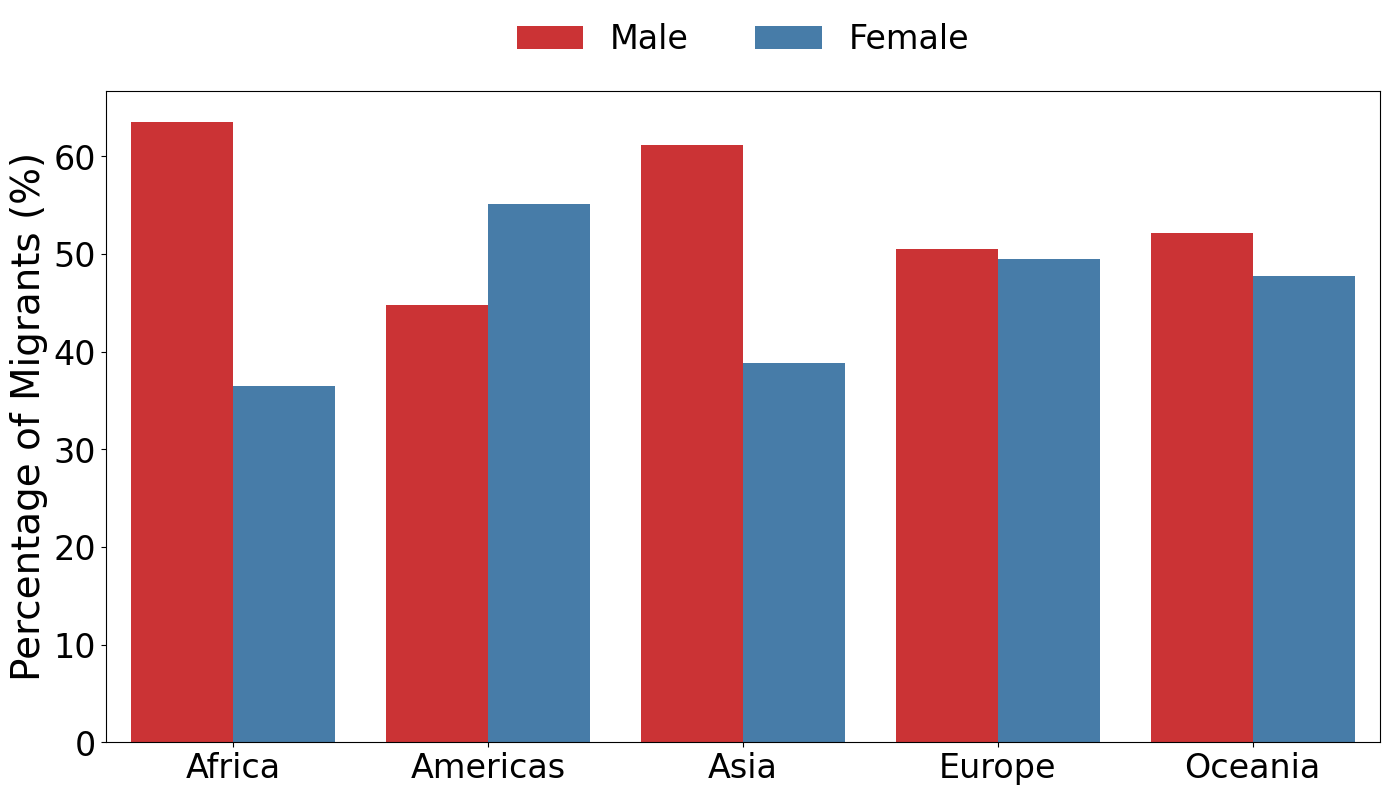

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Aggregate and Calculate Percentages ---
# Sum gender counts by region
gender_summary = summary_df.groupby('region')[['male_migrant', 'female_migrant']].sum().reset_index()

# Melt for plotting
df_gender = gender_summary.melt(id_vars='region', var_name='Gender', value_name='Count')

# Calculate the Relative Percentage within each region
df_gender['Percentage'] = df_gender.groupby('region')['Count'].transform(lambda x: 100 * x / x.sum())
df_gender['Gender'] = df_gender['Gender'].replace({'male_migrant': 'Male', 'female_migrant': 'Female'})

# --- 2. Plotting ---
plt.figure(figsize=(14, 8))
sns.barplot(x='region', y='Percentage', hue='Gender', data=df_gender, palette="Set1")

# Aesthetics matching your requirements
plt.legend(loc='upper center', fontsize=24, ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.15))
plt.xlabel('', fontsize=24)
plt.ylabel('Percentage of Migrants (%)', fontsize=28)
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
plt.tight_layout()
plt.show()

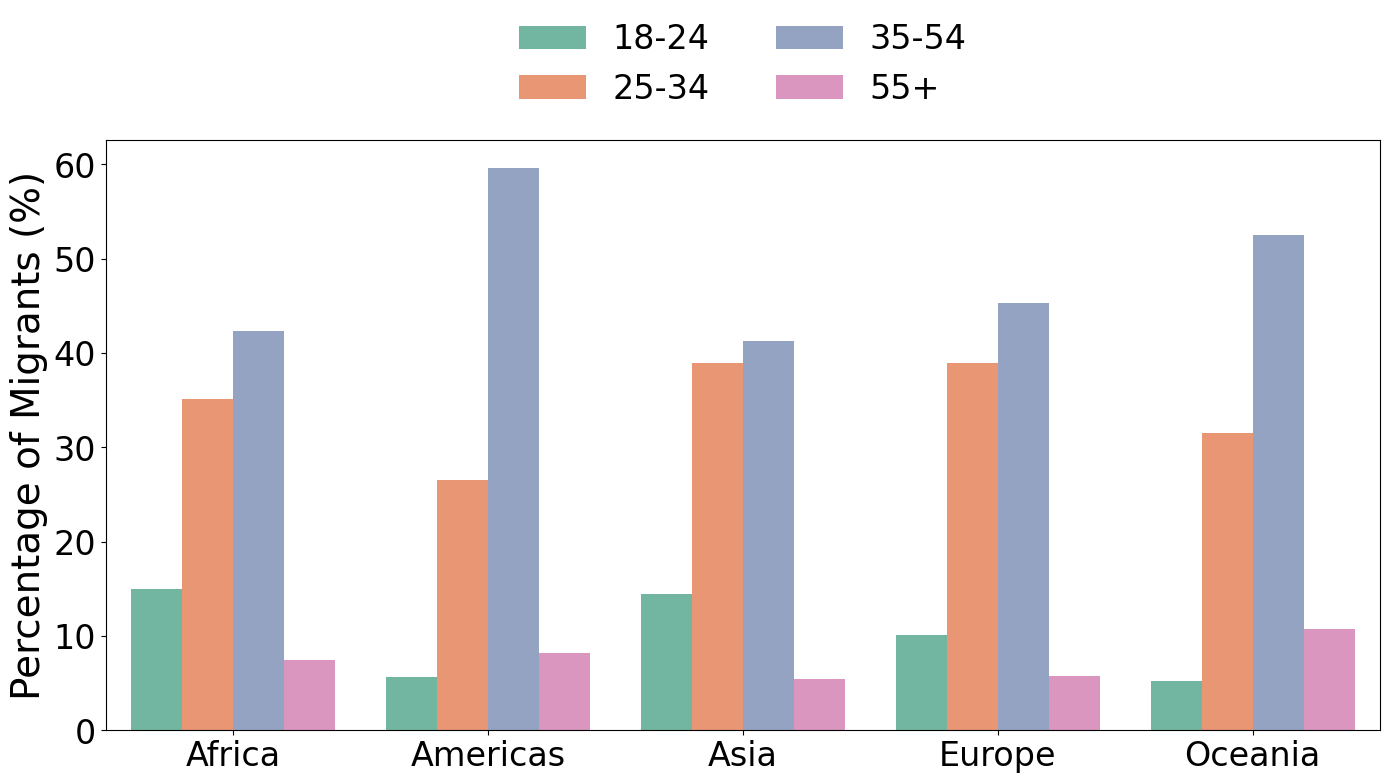

In [21]:
# --- 1. Aggregate and Calculate Percentages ---
age_cols = ['18to24_migrant', '25to34_migrant', '35_to_54_migrant', '55+_migrant']
age_summary = summary_df.groupby('region')[age_cols].sum().reset_index()

# Melt for plotting
df_age = age_summary.melt(id_vars='region', var_name='Age Group', value_name='Count')

# Calculate the Relative Percentage within each region
df_age['Percentage'] = df_age.groupby('region')['Count'].transform(lambda x: 100 * x / x.sum())
df_age['Age Group'] = df_age['Age Group'].replace({
    '18to24_migrant': '18-24', 
    '25to34_migrant': '25-34', 
    '35_to_54_migrant': '35-54', 
    '55+_migrant': '55+'
})

# --- 2. Plotting ---
plt.figure(figsize=(14, 8))
sns.barplot(x='region', y='Percentage', hue='Age Group', data=df_age, palette="Set2")

# Aesthetics matching your requirements
plt.legend(loc='upper center', frameon=False, ncol=2, fontsize=24, bbox_to_anchor=(0.5, 1.25))
plt.xlabel('', fontsize=24)
plt.ylabel('Percentage of Migrants (%)', fontsize=28)
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
plt.tight_layout()
plt.show()

In [22]:
 summary_df

,subject_country,migrated_country,region,total_migrant,male_migrant,female_migrant,18to24_migrant,25to34_migrant,35_to_54_migrant,55+_migrant
0,Argentina,Argentina,Americas,0,0,0,0,0,0,0
1,Argentina,Armenia,Asia,0,0,0,0,0,0,0
2,Argentina,Australia,Oceania,5000,2200,2600,0,2200,2400,0
3,Argentina,Austria,Europe,0,0,0,0,0,0,0
4,Argentina,Azerbaijan,Asia,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
10398,Viet Nam,United States of America,Americas,2300,950,1000,0,970,1100,0
10399,Viet Nam,Uruguay,Americas,0,0,0,0,0,0,0
10400,Viet Nam,Uzbekistan,Asia,0,0,0,0,0,0,0
10401,Viet Nam,Venezuela (Bolivarian Republic of),Americas,0,0,0,0,0,0,0


In [23]:
import pandas as pd

df = summary_df  # or whatever your dataframe name is

# 1) Build a country -> region lookup using the "self" rows (country to itself)
country_region = (
    df.loc[df["subject_country"].eq(df["migrated_country"]),
           ["migrated_country", "region"]]
    .drop_duplicates(subset=["migrated_country"])
    .set_index("migrated_country")["region"]
)

# 2) Map subject_country -> subject_region
df["subject_region"] = df["subject_country"].map(country_region)

df.head()


,subject_country,migrated_country,region,total_migrant,male_migrant,female_migrant,18to24_migrant,25to34_migrant,35_to_54_migrant,55+_migrant,subject_region
0,Argentina,Argentina,Americas,0,0,0,0,0,0,0,Americas
1,Argentina,Armenia,Asia,0,0,0,0,0,0,0,Americas
2,Argentina,Australia,Oceania,5000,2200,2600,0,2200,2400,0,Americas
3,Argentina,Austria,Europe,0,0,0,0,0,0,0,Americas
4,Argentina,Azerbaijan,Asia,0,0,0,0,0,0,0,Americas


In [24]:
df

,subject_country,migrated_country,region,total_migrant,male_migrant,female_migrant,18to24_migrant,25to34_migrant,35_to_54_migrant,55+_migrant,subject_region
0,Argentina,Argentina,Americas,0,0,0,0,0,0,0,Americas
1,Argentina,Armenia,Asia,0,0,0,0,0,0,0,Americas
2,Argentina,Australia,Oceania,5000,2200,2600,0,2200,2400,0,Americas
3,Argentina,Austria,Europe,0,0,0,0,0,0,0,Americas
4,Argentina,Azerbaijan,Asia,0,0,0,0,0,0,0,Americas
...,...,...,...,...,...,...,...,...,...,...,...
10398,Viet Nam,United States of America,Americas,2300,950,1000,0,970,1100,0,Asia
10399,Viet Nam,Uruguay,Americas,0,0,0,0,0,0,0,Asia
10400,Viet Nam,Uzbekistan,Asia,0,0,0,0,0,0,0,Asia
10401,Viet Nam,Venezuela (Bolivarian Republic of),Americas,0,0,0,0,0,0,0,Asia


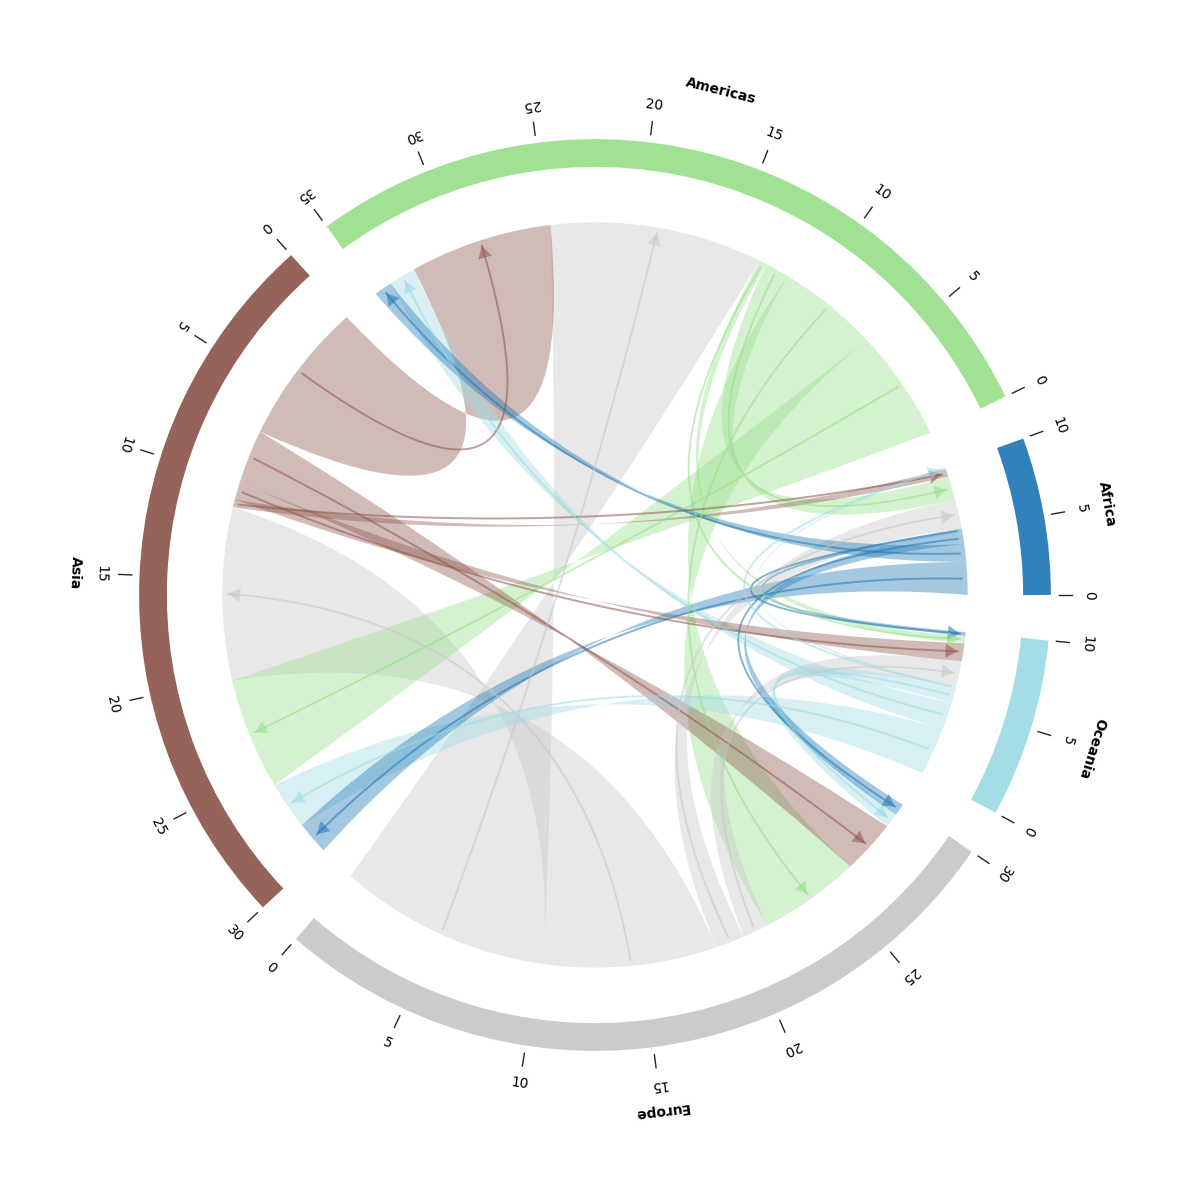

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.path import Path
import matplotlib.patches as patches

# =========================================================
# Geometry Helpers
# =========================================================
def pol2cart(r, theta):
    return np.array([r * np.cos(theta), r * np.sin(theta)])

def arc_points(theta1, theta2, r, n=30):
    thetas = np.linspace(theta1, theta2, n)
    return np.column_stack([r * np.cos(thetas), r * np.sin(thetas)])

def ribbon_path(theta_s0, theta_s1, theta_t0, theta_t1, r_inner=0.86, r_ctrl=0.08):
    s0, s1 = pol2cart(r_inner, theta_s0), pol2cart(r_inner, theta_s1)
    t0, t1 = pol2cart(r_inner, theta_t0), pol2cart(r_inner, theta_t1)

    c0 = pol2cart(r_ctrl, (theta_s0 + theta_t0) / 2)
    c1 = pol2cart(r_ctrl, (theta_s1 + theta_t1) / 2)

    t_arc = arc_points(theta_t0, theta_t1, r_inner, n=25)
    s_arc = arc_points(theta_s1, theta_s0, r_inner, n=25)

    verts, codes = [], []
    verts.append(s0); codes.append(Path.MOVETO)
    verts.extend([c0, t0]); codes.extend([Path.CURVE3, Path.CURVE3])

    for p in t_arc[1:]:
        verts.append(p); codes.append(Path.LINETO)

    verts.extend([c1, s1]); codes.extend([Path.CURVE3, Path.CURVE3])

    for p in s_arc[1:]:
        verts.append(p); codes.append(Path.LINETO)

    verts.append(s0); codes.append(Path.CLOSEPOLY)
    return Path(verts, codes)

def draw_direction_arrow(ax, theta_s, theta_t, r_inner=0.86, r_ctrl=0.06, lane_offset=0.0,
                         arrow_color="#666666", arrow_alpha=0.55, lw=1.4):
    p0 = pol2cart(r_inner * 0.985, theta_s)
    p2 = pol2cart(r_inner * 0.985, theta_t)

    ctrl_r = max(0.01, r_ctrl + lane_offset)
    p1 = pol2cart(ctrl_r, (theta_s + theta_t) / 2)

    t = np.linspace(0, 1, 70)[:, None]
    pts = (1 - t) ** 2 * p0 + 2 * (1 - t) * t * p1 + t ** 2 * p2

    ax.plot(pts[:, 0], pts[:, 1], color=arrow_color, alpha=arrow_alpha, lw=lw, zorder=80)

    v = pts[-1] - pts[-4]
    v = v / (np.linalg.norm(v) + 1e-9)

    head_len, head_w = 0.028, 0.016
    end = pts[-1]
    left  = end - head_len * v + head_w * np.array([-v[1], v[0]])
    right = end - head_len * v - head_w * np.array([-v[1], v[0]])

    ax.add_patch(
        patches.Polygon([end, left, right], closed=True,
                        facecolor=arrow_color, edgecolor="none",
                        alpha=arrow_alpha, zorder=81)
    )

def ceil_to_step(x, step=5):
    return int(np.ceil(x / step) * step)

def add_arc_ticks_percent(ax, start, end, pct_max, r_tick=1.07, tick_len=0.03,
                          label_r=1.14, step=5, fontsize=10, tick_color="black", tick_alpha=0.85):
    """
    Draw ticks labeled 0..pct_max (in percent), with step like 5.
    """
    if pct_max <= 0:
        return

    values = np.arange(0, pct_max + 1e-9, step)
    thetas = start + (values / pct_max) * (end - start)

    for v, th in zip(values, thetas):
        p0 = pol2cart(r_tick, th)
        p1 = pol2cart(r_tick + tick_len, th)
        ax.plot([p0[0], p1[0]], [p0[1], p1[1]],
                lw=1, color=tick_color, alpha=tick_alpha, zorder=90)

        px, py = pol2cart(label_r, th)
        rot = np.degrees(th) - 90
        if np.cos(th) < 0:
            rot += 180

        ax.text(px, py, f"{int(v)}", ha="center", va="center",
                rotation=rot, fontsize=fontsize, color=tick_color, zorder=91)

# =========================================================
# 1) Data Prep (Excluding Intra-Region)
# =========================================================
df_filtered = df[df["subject_region"] != df["region"]].copy()

flows = (
    df_filtered.groupby(["subject_region", "region"], as_index=False)["total_migrant"]
    .sum()
)
flows = flows[flows["total_migrant"] > 0].copy()

regions = sorted(set(flows["subject_region"]).union(set(flows["region"])))
n = len(regions)

# Sector sizes based on (outgoing + incoming)
out_tot = flows.groupby("subject_region")["total_migrant"].sum()
in_tot  = flows.groupby("region")["total_migrant"].sum()
reg_tot = (out_tot.add(in_tot, fill_value=0)).reindex(regions).fillna(0)

total = reg_tot.sum()
if total <= 0:
    raise ValueError("Total volume is zero; check total_migrant values.")

# =========================================================
# 2) Angle Allocation + Span Allocation
# =========================================================
gap = 0.10
r_inner, r_outer = 0.86, 1.02
unit = (2 * np.pi - gap * n) / total

sector = {}
src_cursor = {}
dst_cursor = {}

cur = 0.0
for reg in regions:
    start = cur
    end = start + reg_tot[reg] * unit
    sector[reg] = {"start": start, "end": end}

    src_cursor[reg] = start
    dst_cursor[reg] = start + out_tot.get(reg, 0) * unit  # incoming placed after outgoing

    cur = end + gap

# Allocate spans
src_span = {}
dst_span = {}

flows_by_src = flows.sort_values(["subject_region", "total_migrant"], ascending=[True, False]).copy()
flows_by_src["lane_rank"] = flows_by_src.groupby("subject_region").cumcount()

for _, row in flows_by_src.iterrows():
    s, t, v = row["subject_region"], row["region"], row["total_migrant"]
    s0 = src_cursor[s]
    s1 = s0 + v * unit
    src_span[(s, t)] = (s0, s1)
    src_cursor[s] = s1

flows_by_dst = flows.sort_values(["region", "total_migrant"], ascending=[True, False]).copy()
for _, row in flows_by_dst.iterrows():
    s, t, v = row["subject_region"], row["region"], row["total_migrant"]
    t0 = dst_cursor[t]
    t1 = t0 + v * unit
    dst_span[(s, t)] = (t0, t1)
    dst_cursor[t] = t1

# =========================================================
# 3) Plot
# =========================================================
fig, ax = plt.subplots(figsize=(12, 12), facecolor="white")
ax.set_aspect("equal")
ax.axis("off")
ax.set_xlim(-1.35, 1.35)
ax.set_ylim(-1.35, 1.35)

cmap = plt.cm.tab20
colors = {reg: cmap(i / max(1, n - 1)) for i, reg in enumerate(regions)}

# ---- Outer arcs + labels + % ticks (region-specific max) ----
tick_step = 5
tick_font = 10

# region percent share
reg_pct = (reg_tot / total) * 100

for reg in regions:
    s, e = sector[reg]["start"], sector[reg]["end"]

    ax.add_patch(
        patches.Arc((0, 0), 2 * r_outer, 2 * r_outer,
                    theta1=np.degrees(s), theta2=np.degrees(e),
                    lw=20, color=colors[reg], alpha=0.92,
                    capstyle="butt", zorder=10)
    )

    # label
    mid = (s + e) / 2
    lx, ly = pol2cart(1.20, mid)
    rot = np.degrees(mid) - 90
    if np.cos(mid) < 0:
        rot += 180
    ax.text(lx, ly, reg, ha="center", va="center", rotation=rot,
            fontweight="bold", zorder=95)

    # percent-based max rounded up to nearest 5
    pct_max = ceil_to_step(reg_pct[reg], tick_step)

    add_arc_ticks_percent(
        ax,
        start=s, end=e,
        pct_max=pct_max,
        r_tick=1.07, tick_len=0.03,
        label_r=1.14,
        step=tick_step,
        fontsize=tick_font,
        tick_color="black",
        tick_alpha=0.85
    )

# ---- Ribbons ----
flows_sorted = flows.sort_values("total_migrant", ascending=False)
for _, row in flows_sorted.iterrows():
    s, t = row["subject_region"], row["region"]
    s0, s1 = src_span[(s, t)]
    t0, t1 = dst_span[(s, t)]

    ax.add_patch(
        patches.PathPatch(
            ribbon_path(s0, s1, t0, t1, r_inner=r_inner, r_ctrl=0.08),
            facecolor=colors[s],
            edgecolor="none",
            alpha=0.40,
            zorder=30
        )
    )

# ---- Direction arrows (NOT black; use source color) ----
lane_step = 0.020
for _, row in flows_by_src.iterrows():
    s, t = row["subject_region"], row["region"]
    s0, s1 = src_span[(s, t)]
    t0, t1 = dst_span[(s, t)]

    theta_s = (s0 + s1) / 2
    theta_t = (t0 + t1) / 2
    lane_offset = row["lane_rank"] * lane_step

    draw_direction_arrow(
        ax,
        theta_s=theta_s,
        theta_t=theta_t,
        r_inner=r_inner,
        r_ctrl=0.06,
        lane_offset=lane_offset,
        arrow_color=colors[s],   # <- not black
        arrow_alpha=0.55,
        lw=1.4
    )

#ax.set_title("Regional Migration Chord Diagram\nArc scales are region-specific (% of total)", pad=20)
plt.tight_layout()
plt.savefig("migration_chord_percent_scale.pdf", bbox_inches="tight")
plt.show()


In [26]:
flows_by_src

,subject_region,region,total_migrant,lane_rank
1,Africa,Asia,404510,0
0,Africa,Americas,219750,1
2,Africa,Europe,146380,2
3,Africa,Oceania,47080,3
5,Americas,Asia,1379780,0
6,Americas,Europe,1246450,1
4,Americas,Africa,295800,2
7,Americas,Oceania,89030,3
9,Asia,Americas,1763420,0
10,Asia,Europe,663820,1


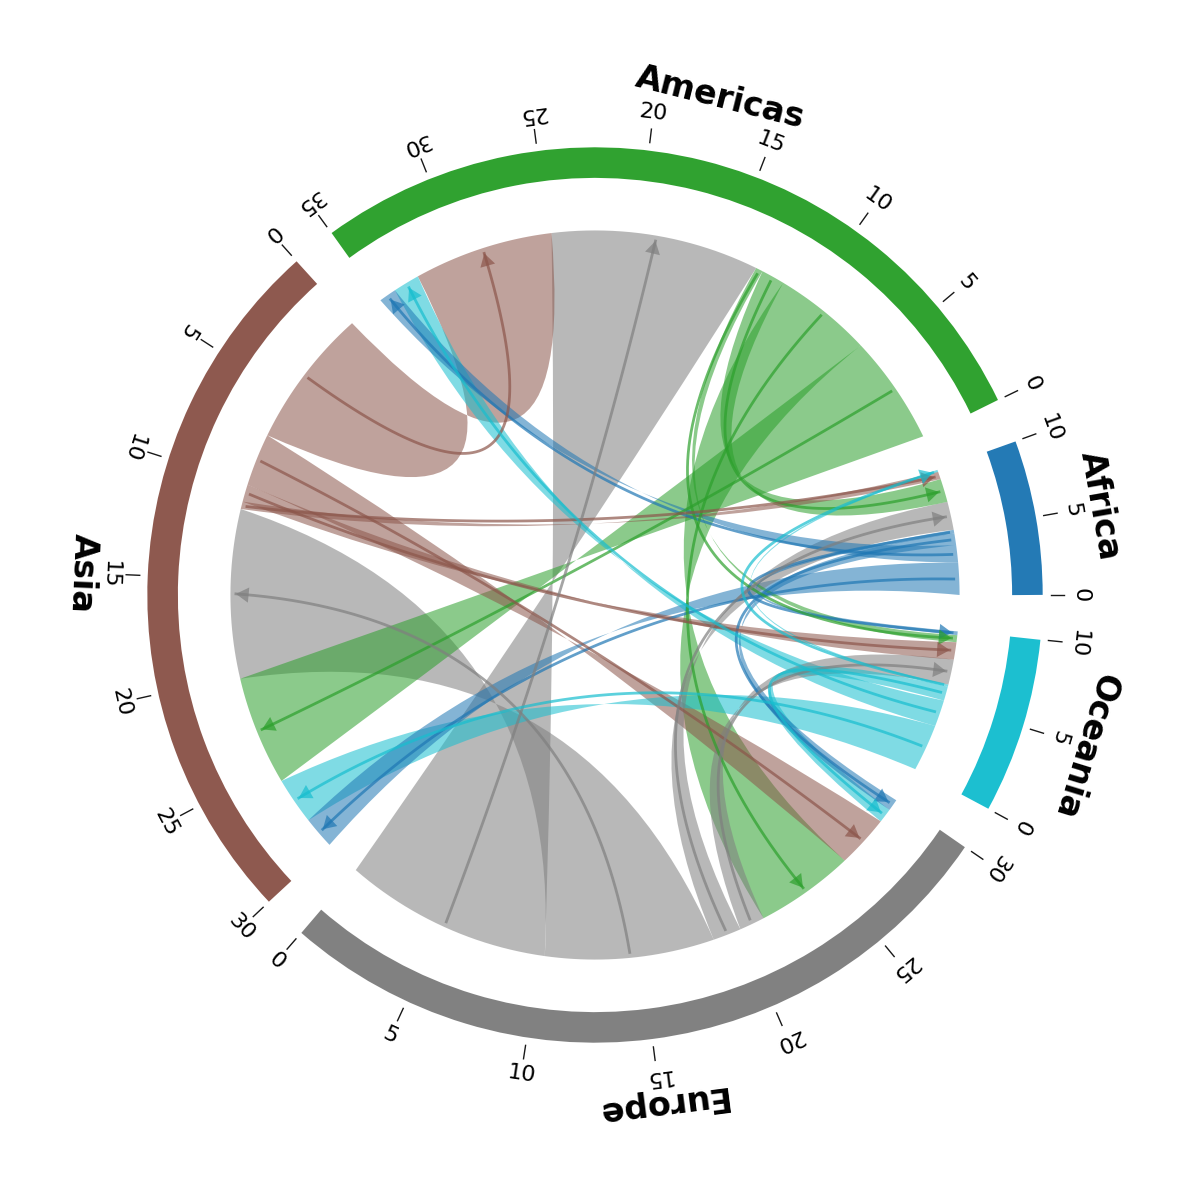

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.path import Path
import matplotlib.patches as patches

# =========================================================
# Geometry Helpers
# =========================================================
def pol2cart(r, theta):
    return np.array([r * np.cos(theta), r * np.sin(theta)])

def arc_points(theta1, theta2, r, n=30):
    thetas = np.linspace(theta1, theta2, n)
    return np.column_stack([r * np.cos(thetas), r * np.sin(thetas)])

def ribbon_path(theta_s0, theta_s1, theta_t0, theta_t1, r_inner=0.86, r_ctrl=0.08):
    s0, s1 = pol2cart(r_inner, theta_s0), pol2cart(r_inner, theta_s1)
    t0, t1 = pol2cart(r_inner, theta_t0), pol2cart(r_inner, theta_t1)

    c0 = pol2cart(r_ctrl, (theta_s0 + theta_t0) / 2)
    c1 = pol2cart(r_ctrl, (theta_s1 + theta_t1) / 2)

    t_arc = arc_points(theta_t0, theta_t1, r_inner, n=25)
    s_arc = arc_points(theta_s1, theta_s0, r_inner, n=25)

    verts, codes = [], []
    verts.append(s0); codes.append(Path.MOVETO)
    verts.extend([c0, t0]); codes.extend([Path.CURVE3, Path.CURVE3])

    for p in t_arc[1:]:
        verts.append(p); codes.append(Path.LINETO)

    verts.extend([c1, s1]); codes.extend([Path.CURVE3, Path.CURVE3])

    for p in s_arc[1:]:
        verts.append(p); codes.append(Path.LINETO)

    verts.append(s0); codes.append(Path.CLOSEPOLY)
    return Path(verts, codes)

def draw_direction_arrow(ax, theta_s, theta_t, r_inner=0.86, r_ctrl=0.06, lane_offset=0.0,
                         arrow_color="#666666", arrow_alpha=0.65, lw=1.8):
    p0 = pol2cart(r_inner * 0.985, theta_s)
    p2 = pol2cart(r_inner * 0.985, theta_t)

    ctrl_r = max(0.01, r_ctrl + lane_offset)
    p1 = pol2cart(ctrl_r, (theta_s + theta_t) / 2)

    t = np.linspace(0, 1, 70)[:, None]
    pts = (1 - t) ** 2 * p0 + 2 * (1 - t) * t * p1 + t ** 2 * p2

    ax.plot(pts[:, 0], pts[:, 1], color=arrow_color, alpha=arrow_alpha, lw=lw, zorder=80)

    v = pts[-1] - pts[-4]
    v = v / (np.linalg.norm(v) + 1e-9)

    head_len, head_w = 0.030, 0.018
    end = pts[-1]
    left  = end - head_len * v + head_w * np.array([-v[1], v[0]])
    right = end - head_len * v - head_w * np.array([-v[1], v[0]])

    ax.add_patch(
        patches.Polygon([end, left, right], closed=True,
                        facecolor=arrow_color, edgecolor="none",
                        alpha=arrow_alpha, zorder=81)
    )

def ceil_to_step(x, step=5):
    return int(np.ceil(x / step) * step)

def add_arc_ticks_percent(ax, start, end, pct_max, r_tick=1.07, tick_len=0.03,
                          label_r=1.14, step=5, fontsize=10,
                          tick_color="black", tick_alpha=0.85):
    if pct_max <= 0:
        return

    values = np.arange(0, pct_max + 1e-9, step)
    thetas = start + (values / pct_max) * (end - start)

    for v, th in zip(values, thetas):
        p0 = pol2cart(r_tick, th)
        p1 = pol2cart(r_tick + tick_len, th)
        ax.plot([p0[0], p1[0]], [p0[1], p1[1]],
                lw=1, color=tick_color, alpha=tick_alpha, zorder=90)

        px, py = pol2cart(label_r, th)
        rot = np.degrees(th) - 90
        if np.cos(th) < 0:
            rot += 180

        ax.text(px, py, f"{int(v)}", ha="center", va="center",
                rotation=rot, fontsize=fontsize, color=tick_color, zorder=91)

# =========================================================
# 1) Data Prep (Excluding Intra-Region)
# =========================================================
df_filtered = df[df["subject_region"] != df["region"]].copy()

flows = (
    df_filtered.groupby(["subject_region", "region"], as_index=False)["total_migrant"]
    .sum()
)
flows = flows[flows["total_migrant"] > 0].copy()

regions = sorted(set(flows["subject_region"]).union(set(flows["region"])))
n = len(regions)

out_tot = flows.groupby("subject_region")["total_migrant"].sum()
in_tot  = flows.groupby("region")["total_migrant"].sum()
reg_tot = (out_tot.add(in_tot, fill_value=0)).reindex(regions).fillna(0)

total = reg_tot.sum()
if total <= 0:
    raise ValueError("Total volume is zero; check total_migrant values.")

# =========================================================
# 2) Angle Allocation + Span Allocation
# =========================================================
gap = 0.10
r_inner, r_outer = 0.86, 1.02
unit = (2 * np.pi - gap * n) / total

sector = {}
src_cursor = {}
dst_cursor = {}

cur = 0.0
for reg in regions:
    start = cur
    end = start + reg_tot[reg] * unit
    sector[reg] = {"start": start, "end": end}

    src_cursor[reg] = start
    dst_cursor[reg] = start + out_tot.get(reg, 0) * unit

    cur = end + gap

src_span = {}
dst_span = {}

flows_by_src = flows.sort_values(["subject_region", "total_migrant"], ascending=[True, False]).copy()
flows_by_src["lane_rank"] = flows_by_src.groupby("subject_region").cumcount()

for _, row in flows_by_src.iterrows():
    s, t, v = row["subject_region"], row["region"], row["total_migrant"]
    s0 = src_cursor[s]
    s1 = s0 + v * unit
    src_span[(s, t)] = (s0, s1)
    src_cursor[s] = s1

flows_by_dst = flows.sort_values(["region", "total_migrant"], ascending=[True, False]).copy()
for _, row in flows_by_dst.iterrows():
    s, t, v = row["subject_region"], row["region"], row["total_migrant"]
    t0 = dst_cursor[t]
    t1 = t0 + v * unit
    dst_span[(s, t)] = (t0, t1)
    dst_cursor[t] = t1

# =========================================================
# 3) Plot (more eye-catchy colors)
# =========================================================
fig, ax = plt.subplots(figsize=(12, 12), facecolor="white")
ax.set_aspect("equal")
ax.axis("off")
ax.set_xlim(-1.38, 1.38)
ax.set_ylim(-1.38, 1.38)

# --- Eye-catchy palette (bright, distinct) ---
# If you have <= 10 regions, tab10 looks very bold.
# If more, hsv is vivid but can be harsh—still eye-catchy.
if n <= 10:
    cmap = plt.cm.tab10
else:
    cmap = plt.cm.hsv

colors = {reg: cmap(i / max(1, n - 1)) for i, reg in enumerate(regions)}

# --- Percent share for per-region tick scale ---
reg_pct = (reg_tot / total) * 100

tick_step = 5
tick_font = 16

# Outer arcs + labels + % ticks
for reg in regions:
    s, e = sector[reg]["start"], sector[reg]["end"]

    ax.add_patch(
        patches.Arc((0, 0), 2 * r_outer, 2 * r_outer,
                    theta1=np.degrees(s), theta2=np.degrees(e),
                    lw=22, color=colors[reg], alpha=0.98,
                    capstyle="butt", zorder=10)
    )

    # Labels
    mid = (s + e) / 2
    lx, ly = pol2cart(1.21, mid)
    rot = np.degrees(mid) - 90
    if np.cos(mid) < 0:
        rot += 180
    ax.text(lx, ly, reg, ha="center", va="center", rotation=rot,
            fontweight="bold", fontsize=24, zorder=95)

    # Percent max rounded up to nearest 5
    pct_max = ceil_to_step(reg_pct[reg], tick_step)

    add_arc_ticks_percent(
        ax,
        start=s, end=e,
        pct_max=pct_max,
        r_tick=1.075, tick_len=0.032,
        label_r=1.145,
        step=tick_step,
        fontsize=tick_font,
        tick_color="black",
        tick_alpha=0.9
    )

# Ribbons (slightly stronger alpha for pop)
flows_sorted = flows.sort_values("total_migrant", ascending=False)
for _, row in flows_sorted.iterrows():
    s, t = row["subject_region"], row["region"]
    s0, s1 = src_span[(s, t)]
    t0, t1 = dst_span[(s, t)]

    ax.add_patch(
        patches.PathPatch(
            ribbon_path(s0, s1, t0, t1, r_inner=r_inner, r_ctrl=0.09),
            facecolor=colors[s],
            edgecolor="none",
            alpha=0.55,   # more vivid
            zorder=30
        )
    )

# Arrows (NOT black: use a brighter but readable version of the source color)
lane_step = 0.020
for _, row in flows_by_src.iterrows():
    s, t = row["subject_region"], row["region"]
    s0, s1 = src_span[(s, t)]
    t0, t1 = dst_span[(s, t)]

    theta_s = (s0 + s1) / 2
    theta_t = (t0 + t1) / 2
    lane_offset = row["lane_rank"] * lane_step

    draw_direction_arrow(
        ax,
        theta_s=theta_s,
        theta_t=theta_t,
        r_inner=r_inner,
        r_ctrl=0.055,
        lane_offset=lane_offset,
        arrow_color=colors[s],   # same vivid palette
        arrow_alpha=0.70,
        lw=2.0
    )

#ax.set_title("Regional Migration Chord Diagram\nArc scales are region-specific (% of total)", pad=20)
plt.tight_layout()
plt.savefig("migration_chord_percent_scale_vivid.pdf", bbox_inches="tight")
plt.show()


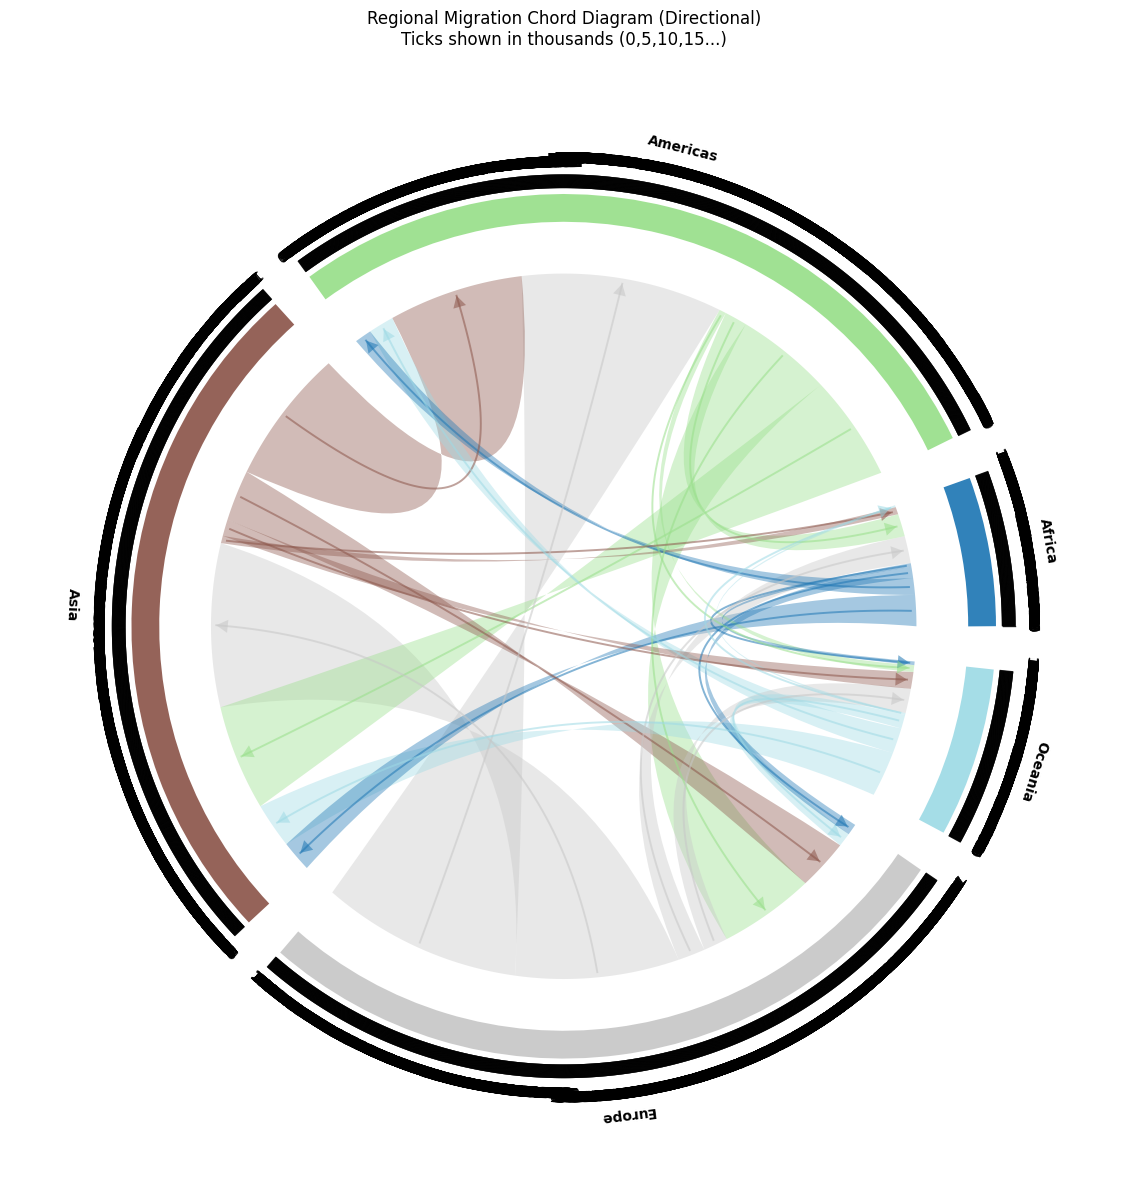

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.path import Path
import matplotlib.patches as patches

# =========================================================
# Geometry Helpers
# =========================================================
def pol2cart(r, theta):
    return np.array([r * np.cos(theta), r * np.sin(theta)])

def arc_points(theta1, theta2, r, n=30):
    thetas = np.linspace(theta1, theta2, n)
    return np.column_stack([r * np.cos(thetas), r * np.sin(thetas)])

def ribbon_path(theta_s0, theta_s1, theta_t0, theta_t1, r_inner=0.86, r_ctrl=0.08):
    """
    Closed ribbon polygon between source sub-arc [theta_s0,theta_s1]
    and target sub-arc [theta_t0,theta_t1] on inner radius r_inner.
    """
    s0, s1 = pol2cart(r_inner, theta_s0), pol2cart(r_inner, theta_s1)
    t0, t1 = pol2cart(r_inner, theta_t0), pol2cart(r_inner, theta_t1)

    # Control points toward center
    c0 = pol2cart(r_ctrl, (theta_s0 + theta_t0) / 2)
    c1 = pol2cart(r_ctrl, (theta_s1 + theta_t1) / 2)

    # Follow inner arcs for thickness look
    t_arc = arc_points(theta_t0, theta_t1, r_inner, n=25)
    s_arc = arc_points(theta_s1, theta_s0, r_inner, n=25)  # back

    verts, codes = [], []

    verts.append(s0); codes.append(Path.MOVETO)
    verts.extend([c0, t0]); codes.extend([Path.CURVE3, Path.CURVE3])

    for p in t_arc[1:]:
        verts.append(p); codes.append(Path.LINETO)

    verts.extend([c1, s1]); codes.extend([Path.CURVE3, Path.CURVE3])

    for p in s_arc[1:]:
        verts.append(p); codes.append(Path.LINETO)

    verts.append(s0); codes.append(Path.CLOSEPOLY)

    return Path(verts, codes)

def draw_direction_arrow(ax, theta_s, theta_t, r_inner=0.86, r_ctrl=0.06, lane_offset=0.0,
                         arrow_color="#666666", arrow_alpha=0.55, lw=1.4):
    """
    Draw a midline directional arrow from source theta to target theta.
    lane_offset separates outgoing arrows from the same source.
    """
    p0 = pol2cart(r_inner * 0.985, theta_s)
    p2 = pol2cart(r_inner * 0.985, theta_t)

    ctrl_r = max(0.01, r_ctrl + lane_offset)
    p1 = pol2cart(ctrl_r, (theta_s + theta_t) / 2)

    # Quadratic Bezier samples
    t = np.linspace(0, 1, 70)[:, None]
    pts = (1 - t) ** 2 * p0 + 2 * (1 - t) * t * p1 + t ** 2 * p2

    ax.plot(pts[:, 0], pts[:, 1], color=arrow_color, alpha=arrow_alpha, lw=lw, zorder=80)

    # Arrowhead
    v = pts[-1] - pts[-4]
    v = v / (np.linalg.norm(v) + 1e-9)
    head_len, head_w = 0.028, 0.016
    end = pts[-1]
    left  = end - head_len * v + head_w * np.array([-v[1], v[0]])
    right = end - head_len * v - head_w * np.array([-v[1], v[0]])

    ax.add_patch(
        patches.Polygon([end, left, right], closed=True,
                        facecolor=arrow_color, edgecolor="none",
                        alpha=arrow_alpha, zorder=81)
    )

def add_arc_ticks(ax, start, end, value_max, r_tick=1.07, tick_len=0.03,
                  label_r=1.14, step=5, fontsize=10, label_every=1,
                  tick_color="black", tick_alpha=0.85):
    """
    Ticks + labels along arc [start,end].
    value_max is the maximum label value at end of arc.
    step defines labels: 0, step, 2*step, ...
    """
    if value_max <= 0:
        return

    # Ensure last tick lands at/near end
    values = np.arange(0, value_max + 1e-9, step)
    if len(values) == 0:
        return

    thetas = start + (values / value_max) * (end - start)

    for k, (v, th) in enumerate(zip(values, thetas)):
        p0 = pol2cart(r_tick, th)
        p1 = pol2cart(r_tick + tick_len, th)
        ax.plot([p0[0], p1[0]], [p0[1], p1[1]],
                lw=1, color=tick_color, alpha=tick_alpha, zorder=90)

        if (k % label_every) == 0:
            px, py = pol2cart(label_r, th)
            rot = np.degrees(th) - 90
            if np.cos(th) < 0:
                rot += 180
            ax.text(px, py, f"{int(v)}", ha="center", va="center",
                    rotation=rot, fontsize=fontsize, color=tick_color, zorder=91)

# =========================================================
# 1) Data Prep (Excluding Intra-Region)
# =========================================================
# df must include: subject_region, region, total_migrant
df_filtered = df[df["subject_region"] != df["region"]].copy()

flows = (
    df_filtered.groupby(["subject_region", "region"], as_index=False)["total_migrant"]
    .sum()
)
flows = flows[flows["total_migrant"] > 0].copy()

regions = sorted(set(flows["subject_region"]).union(set(flows["region"])))
n = len(regions)

# Sector sizes based on (outgoing + incoming)
out_tot = flows.groupby("subject_region")["total_migrant"].sum()
in_tot  = flows.groupby("region")["total_migrant"].sum()
reg_tot = (out_tot.add(in_tot, fill_value=0)).reindex(regions).fillna(0)

# =========================================================
# 2) Angle Allocation + Span Allocation (source then dest)
#    Dest spans begin AFTER source spans within same region arc
# =========================================================
gap = 0.10
r_inner, r_outer = 0.86, 1.02

total = reg_tot.sum()
if total <= 0:
    raise ValueError("Total volume is zero; check total_migrant values.")

unit = (2 * np.pi - gap * n) / total

sector = {}
src_cursor = {}
dst_cursor = {}

cur = 0.0
for reg in regions:
    start = cur
    end = start + reg_tot[reg] * unit
    sector[reg] = {"start": start, "end": end}

    # Source spans start at arc start
    src_cursor[reg] = start

    # Destination spans start after all outgoing from this region
    dst_cursor[reg] = start + out_tot.get(reg, 0) * unit

    cur = end + gap

# Allocate per-flow spans
src_span = {}
dst_span = {}

# Source allocation: by source, big first
flows_by_src = flows.sort_values(["subject_region", "total_migrant"], ascending=[True, False]).copy()
flows_by_src["lane_rank"] = flows_by_src.groupby("subject_region").cumcount()

for _, row in flows_by_src.iterrows():
    s, t, v = row["subject_region"], row["region"], row["total_migrant"]

    s0 = src_cursor[s]
    s1 = s0 + v * unit
    src_span[(s, t)] = (s0, s1)
    src_cursor[s] = s1

# Destination allocation: by destination, big first (side-by-side on incoming)
flows_by_dst = flows.sort_values(["region", "total_migrant"], ascending=[True, False]).copy()

for _, row in flows_by_dst.iterrows():
    s, t, v = row["subject_region"], row["region"], row["total_migrant"]

    t0 = dst_cursor[t]
    t1 = t0 + v * unit
    dst_span[(s, t)] = (t0, t1)
    dst_cursor[t] = t1

# =========================================================
# 3) Plot
# =========================================================
fig, ax = plt.subplots(figsize=(12, 12), facecolor="white")
ax.set_aspect("equal")
ax.axis("off")
ax.set_xlim(-1.35, 1.35)
ax.set_ylim(-1.35, 1.35)

# Colors
cmap = plt.cm.tab20
colors = {reg: cmap(i / max(1, n - 1)) for i, reg in enumerate(regions)}

# ---- Outer arcs + labels + numeric ticks (0,5,10,15...) ----
# We’ll label in "thousands of migrants" so 0,5,10 means 0k,5k,10k.
tick_step = 5  # show 0,5,10,15...
tick_font = 10

for reg in regions:
    s, e = sector[reg]["start"], sector[reg]["end"]

    ax.add_patch(
        patches.Arc(
            (0, 0),
            2 * r_outer, 2 * r_outer,
            theta1=np.degrees(s),
            theta2=np.degrees(e),
            lw=20,
            color=colors[reg],
            alpha=0.92,
            capstyle="butt",
            zorder=10
        )
    )

    # Label
    mid = (s + e) / 2
    lx, ly = pol2cart(1.20, mid)
    rot = np.degrees(mid) - 90
    if np.cos(mid) < 0:
        rot += 180
    ax.text(lx, ly, reg, ha="center", va="center", rotation=rot, fontweight="bold", zorder=95)

    # Ticks: scale in thousands
    arc_value_k = reg_tot[reg] / 1000.0
    add_arc_ticks(
        ax,
        start=s, end=e,
        value_max=arc_value_k,
        r_tick=1.07, tick_len=0.03,
        label_r=1.14,
        step=tick_step,
        fontsize=tick_font,
        label_every=1,
        tick_color="black",
        tick_alpha=0.85
    )

# ---- Ribbons (big first so thick ones are behind) ----
flows_sorted = flows.sort_values("total_migrant", ascending=False)

for _, row in flows_sorted.iterrows():
    s, t, v = row["subject_region"], row["region"], row["total_migrant"]
    s0, s1 = src_span[(s, t)]
    t0, t1 = dst_span[(s, t)]

    ax.add_patch(
        patches.PathPatch(
            ribbon_path(s0, s1, t0, t1, r_inner=r_inner, r_ctrl=0.08),
            facecolor=colors[s],
            edgecolor="none",
            alpha=0.40,
            zorder=30
        )
    )

# ---- Direction arrows (NOT black) ----
# Separate outgoing arrows per source using lane_rank (no overlap/merging)
lane_step = 0.020  # tune 0.015–0.030

for _, row in flows_by_src.iterrows():
    s, t, v = row["subject_region"], row["region"], row["total_migrant"]
    s0, s1 = src_span[(s, t)]
    t0, t1 = dst_span[(s, t)]

    theta_s = (s0 + s1) / 2
    theta_t = (t0 + t1) / 2

    lane_offset = row["lane_rank"] * lane_step

    # Use source region color for arrows (not black)
    draw_direction_arrow(
        ax,
        theta_s=theta_s,
        theta_t=theta_t,
        r_inner=r_inner,
        r_ctrl=0.06,
        lane_offset=lane_offset,
        arrow_color=colors[s],   # <-- not black
        arrow_alpha=0.55,
        lw=1.4
    )

ax.set_title("Regional Migration Chord Diagram (Directional)\nTicks shown in thousands (0,5,10,15...)", pad=20)
plt.tight_layout()
plt.savefig("migration_chord_clean.pdf", bbox_inches="tight")
plt.show()


In [60]:
#pip install holoviews

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.9/5.9 MB 16.5 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 24.5 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.2/30.2 MB 28.2 MB/s  0:00:01m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10/10 [holoviews]10 [holoviews]
Note: you may need to restart the kernel to use updated packages.


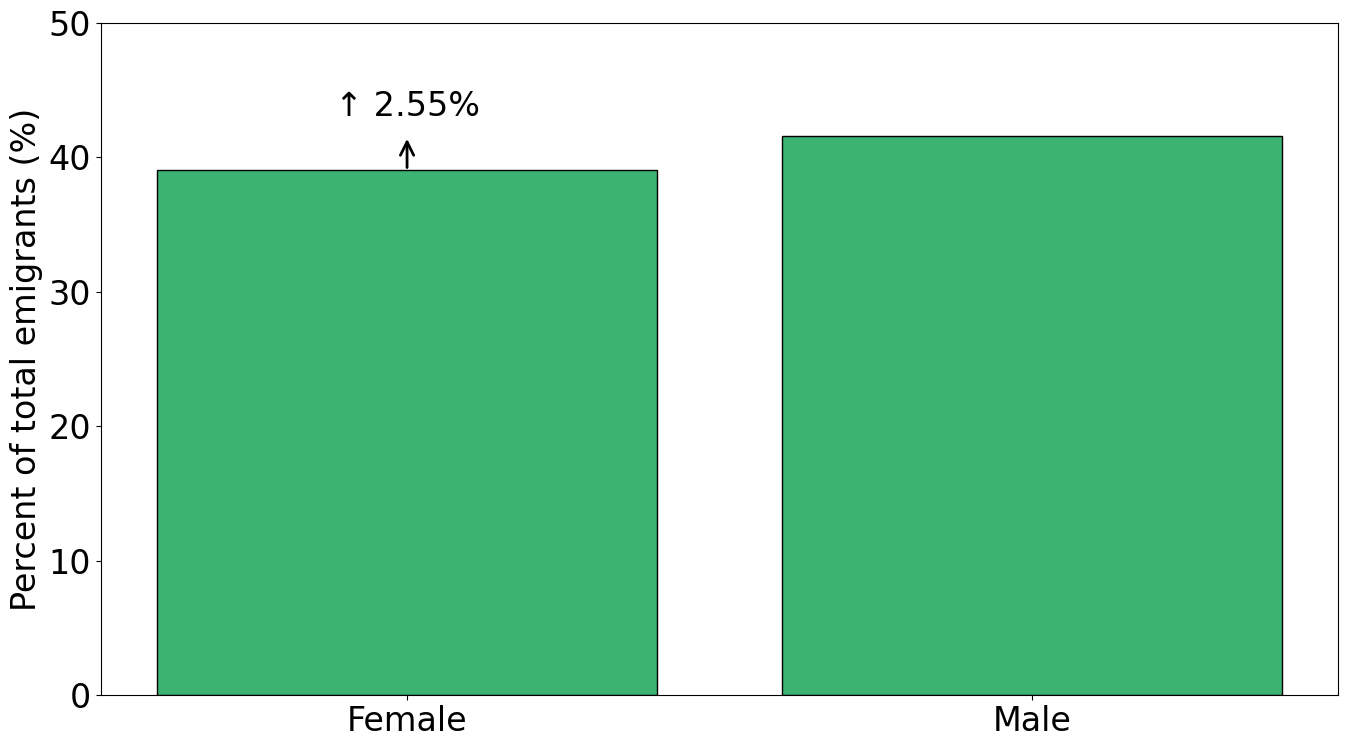

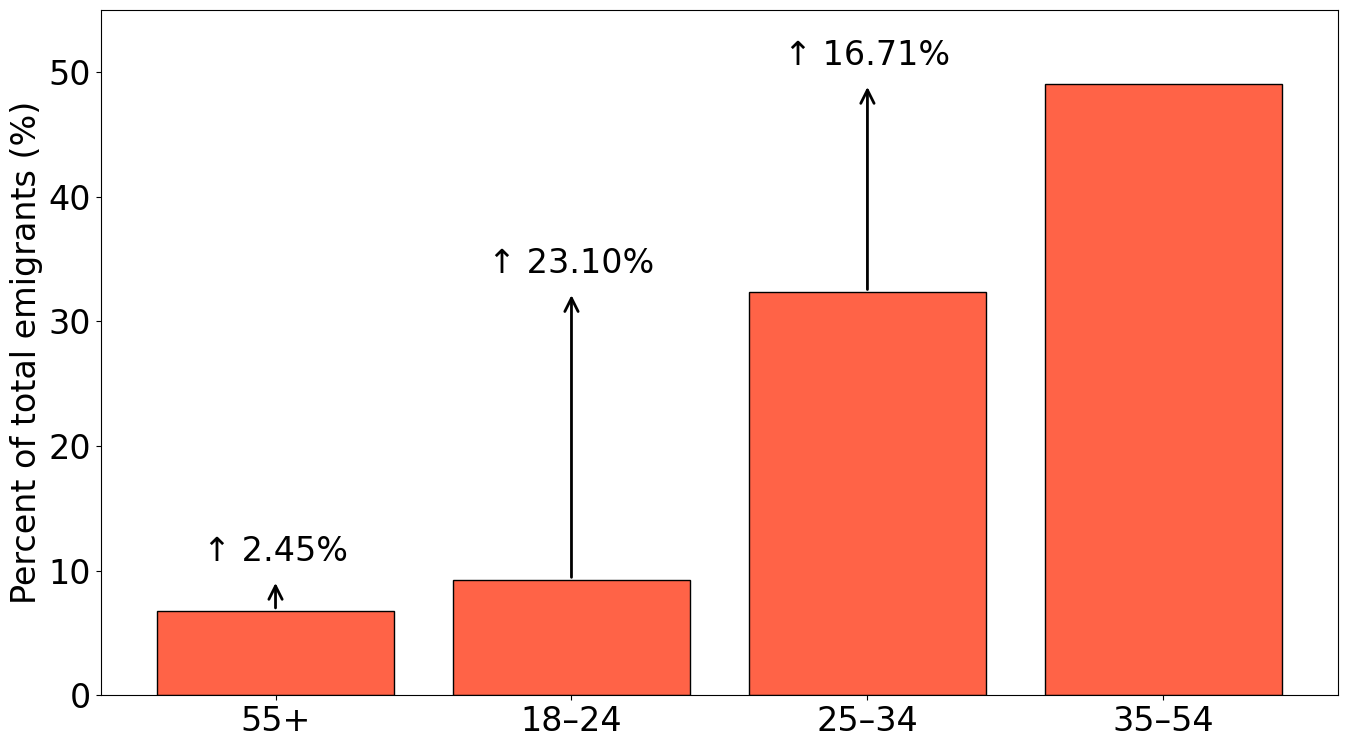

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# Helper: bar plot + "gap-to-next" arrows (your style)
# ---------------------------
def category_bar_with_gap_arrows(labels, values, color, ylabel, ylim_top=50, save_as=None):
    # sort ascending so increase goes upward with arrows
    order = np.argsort(values)
    labels = [labels[i] for i in order]
    values = np.array([values[i] for i in order], dtype=float)

    # gap to next
    diff = np.full_like(values, np.nan, dtype=float)
    diff[:-1] = values[1:] - values[:-1]

    plt.rcParams.update({
        "font.size": 24,
        "axes.titlesize": 24,
        "axes.labelsize": 24,
        "xtick.labelsize": 24,
        "ytick.labelsize": 24,
    })

    fig, ax = plt.subplots(figsize=(14, 8))
    x = np.arange(len(labels))
    bars = ax.bar(x, values, color=color, edgecolor="black")

    ax.set_ylabel(ylabel)
    ax.set_ylim(0, ylim_top)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)

    # arrows + labels
    for i, b in enumerate(bars):
        if i == len(bars) - 1:
            continue  # last has no next

        h = b.get_height()
        cx = b.get_x() + b.get_width() / 2
        d = diff[i]

        arrow_char = "↑" if d >= 0 else "↓"
        y0 = h
        y1 = h + abs(d)

        ax.annotate("", xy=(cx, y1), xytext=(cx, y0),
                    arrowprops=dict(arrowstyle="->", lw=2))

        ax.text(cx, y1 + 1.0, f"{arrow_char} {abs(d):.2f}%",
                ha="center", va="bottom")

    plt.tight_layout()
    if save_as:
        plt.savefig(save_as, bbox_inches="tight")
    plt.show()


# =========================================================
# 1) Gender-only plot (Male vs Female) — NO region
# =========================================================
male_total   = summary_df["male_migrant"].sum()
female_total = summary_df["female_migrant"].sum()
grand_total  = summary_df["total_migrant"].sum()

male_pct   = (male_total / grand_total) * 100 if grand_total else 0
female_pct = (female_total / grand_total) * 100 if grand_total else 0

category_bar_with_gap_arrows(
    labels=["Male", "Female"],
    values=[male_pct, female_pct],
    color="mediumseagreen",  # gender color
    ylabel="Percent of total emigrants (%)",
    ylim_top=50,
    save_as="gender_emigration_pct.pdf"
)


# =========================================================
# 2) Age-only plot (4 bars) — NO region
# =========================================================
age_cols = ["18to24_migrant", "25to34_migrant", "35_to_54_migrant", "55+_migrant"]
age_labels = ["18–24", "25–34", "35–54", "55+"]

age_totals = [summary_df[c].sum() for c in age_cols]
age_pcts = [(v / grand_total) * 100 if grand_total else 0 for v in age_totals]

category_bar_with_gap_arrows(
    labels=age_labels,
    values=age_pcts,
    color="tomato",          # age color (different from gender)
    ylabel="Percent of total emigrants (%)",
    ylim_top=55,
    save_as="age_emigration_pct.pdf"
)


In [43]:
import pandas as pd

region_emigrant_pct = (
    summary_df.groupby("region", as_index=False)["total_migrant"]
    .sum()
    .rename(columns={"total_migrant": "estimated_emigrants"})
)

total = region_emigrant_pct["estimated_emigrants"].sum()

region_emigrant_pct["percent_of_total"] = (region_emigrant_pct["estimated_emigrants"] / total) * 100

region_emigrant_pct = region_emigrant_pct.sort_values("percent_of_total", ascending=False)

# (Optional) nicer rounding
region_emigrant_pct["percent_of_total"] = region_emigrant_pct["percent_of_total"].round(2)

region_emigrant_pct


,region,estimated_emigrants,percent_of_total
1,Americas,8775310,41.44
2,Asia,6359410,30.03
3,Europe,4374970,20.66
4,Oceania,842200,3.98
0,Africa,825750,3.90


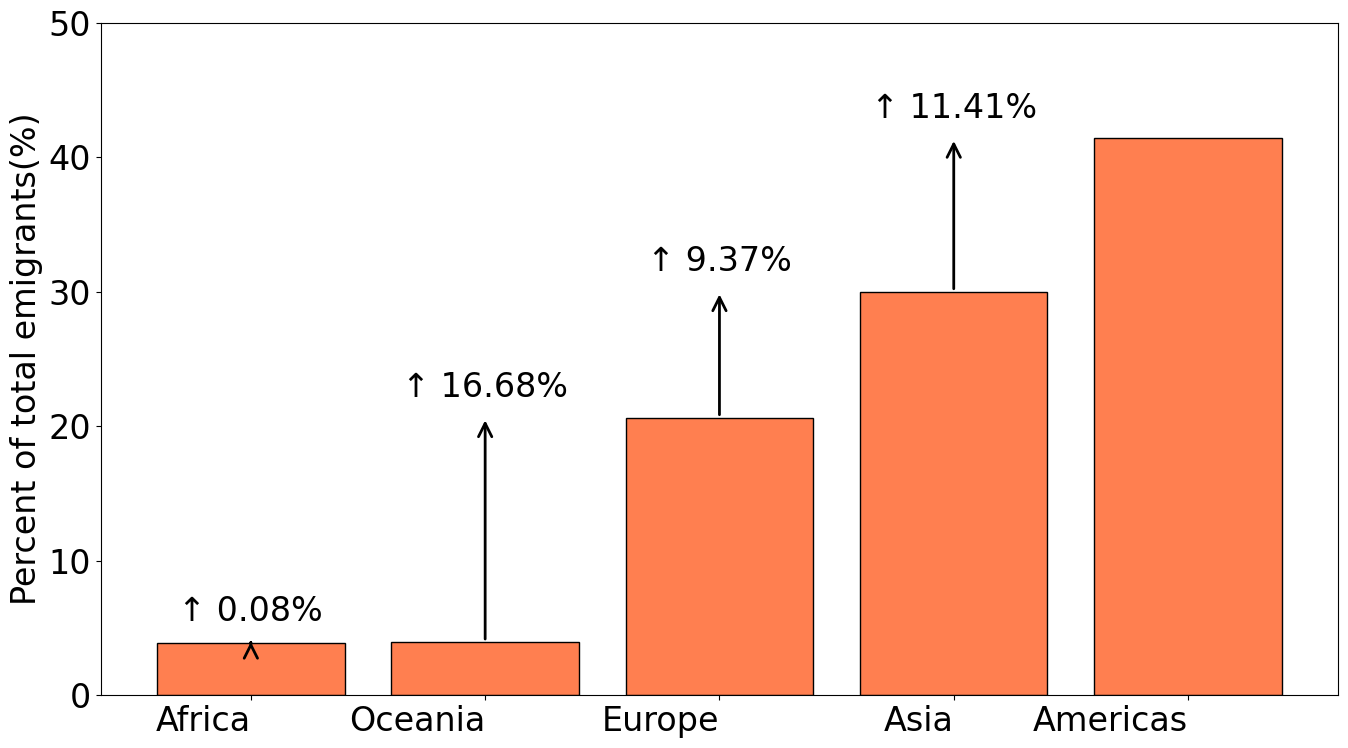

In [55]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# Region-wise % of estimated emigrants
# ---------------------------
region_pct = (
    summary_df.groupby("region", as_index=False)["total_migrant"]
    .sum()
    .rename(columns={"total_migrant": "estimated_emigrants"})
)

total = region_pct["estimated_emigrants"].sum()
region_pct["pct"] = (region_pct["estimated_emigrants"] / total) * 100

# Sort ASC so "increase to next region" is to the right
region_pct = region_pct.sort_values("pct", ascending=True).reset_index(drop=True)

pct_vals = region_pct["pct"].to_numpy()
regions = region_pct["region"].to_list()

# %-point difference to NEXT region (pp)
diff_pp = np.full_like(pct_vals, np.nan, dtype=float)
diff_pp[:-1] = pct_vals[1:] - pct_vals[:-1]  # next - current

# ---------------------------
# Plot settings
# ---------------------------
plt.rcParams.update({
    "font.size": 24,
    "axes.titlesize": 24,
    "axes.labelsize": 24,
    "xtick.labelsize": 24,
    "ytick.labelsize": 24,
})

fig, ax = plt.subplots(figsize=(14, 8))
x = np.arange(len(regions))

bars = ax.bar(x, pct_vals, color="coral", edgecolor="black")

#ax.set_title("Region-wise Percentage of Estimated Emigrants")
#ax.set_xlabel("Region")
ax.set_ylabel("Percent of total emigrants(%)")
ax.set_ylim(0, 50)
ax.set_xticks(x)
ax.set_xticklabels(regions, ha="right")
#ax.ticklabel_format(axis="y", style="plain", useOffset=False)

# ---------------------------
# Arrows whose LENGTH matches the relative distance (the pp gap)
# Label placed at the arrow tip.
# ---------------------------
for i, b in enumerate(bars):
    if i == len(bars) - 1:
        continue  # last bar has no "next" region to compare

    h = b.get_height()
    cx = b.get_x() + b.get_width() / 2
    d = diff_pp[i]

    # If next is smaller (rare with ascending sort, but safe)
    arrow_char = "↑" if d >= 0 else "↓"

    # Arrow start and end: from bar top to bar top + gap (proportional length)
    y0 = h
    y1 = h + abs(d)  # arrow length proportional to gap in pp

    # draw arrow
    ax.annotate(
        "", xy=(cx, y1), xytext=(cx, y0),
        arrowprops=dict(arrowstyle="->", lw=2)
    )

    # label at arrow tip (slightly above)
    ax.text(cx, y1 + 1.0, f"{arrow_char} {abs(d):.2f}%",
            ha="center", va="bottom")

plt.tight_layout()
plt.savefig("region_wise_emigrantion.pdf")
plt.show()


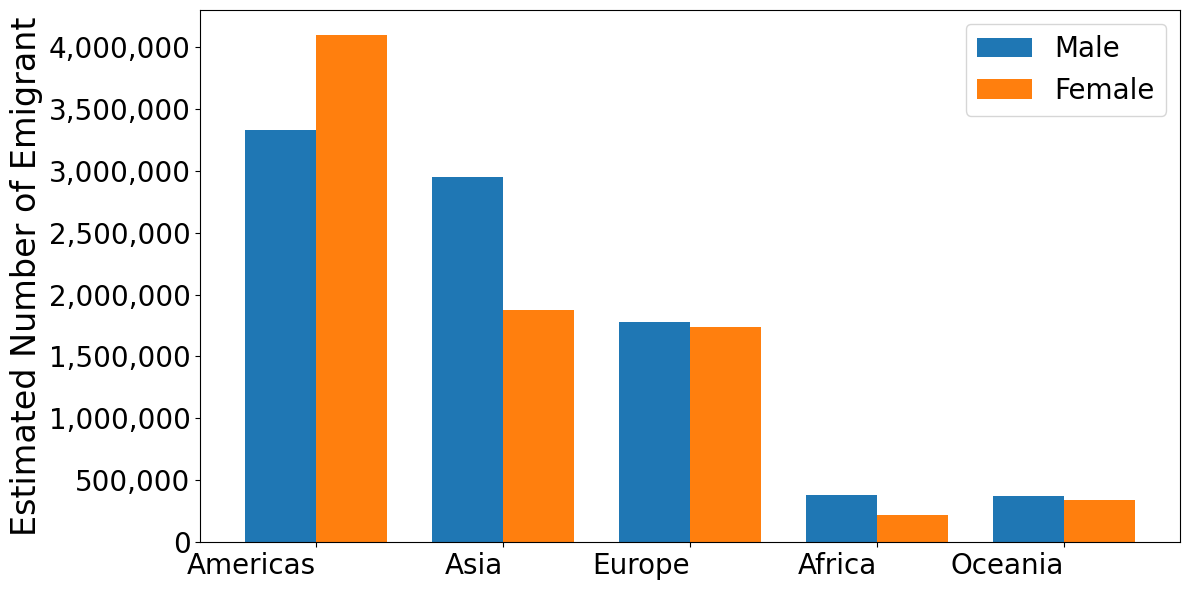

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

# --- Aggregate ---
g = (summary_df.groupby("region")[["male_migrant", "female_migrant"]]
     .sum()
     .sort_values("male_migrant", ascending=False))

regions = g.index.to_list()
x = np.arange(len(regions))
w = 0.38

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - w/2, g["male_migrant"].values, width=w, label="Male")
ax.bar(x + w/2, g["female_migrant"].values, width=w, label="Female")


ax.set_ylabel("Estimated Number of Emigrant", fontsize=24)
ax.set_xticks(x)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.set_xticklabels(regions, ha="right")
ax.legend(fontsize=20)

# --- Force full numbers (no 1e6 / no scientific) ---
ax.ticklabel_format(axis='y', style='plain', useOffset=False)
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()


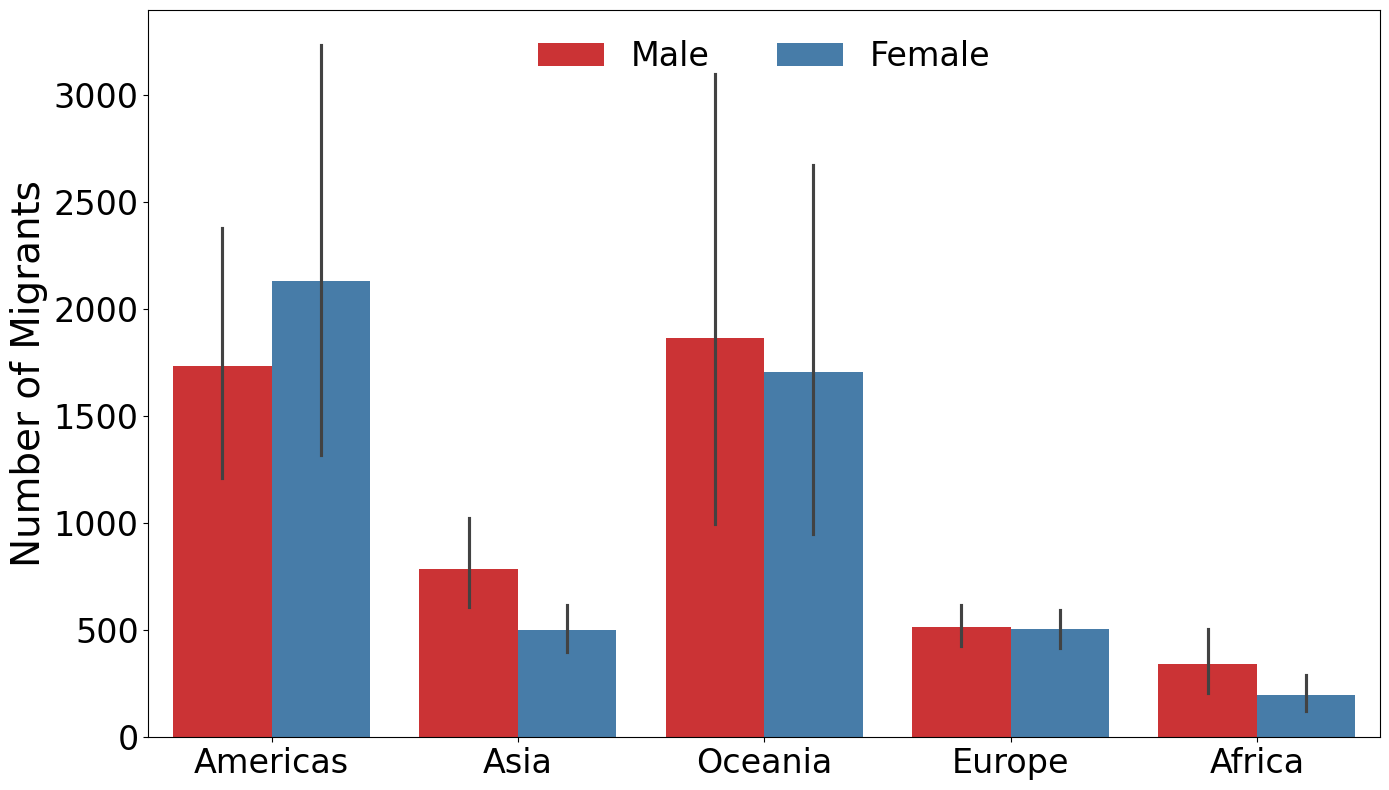

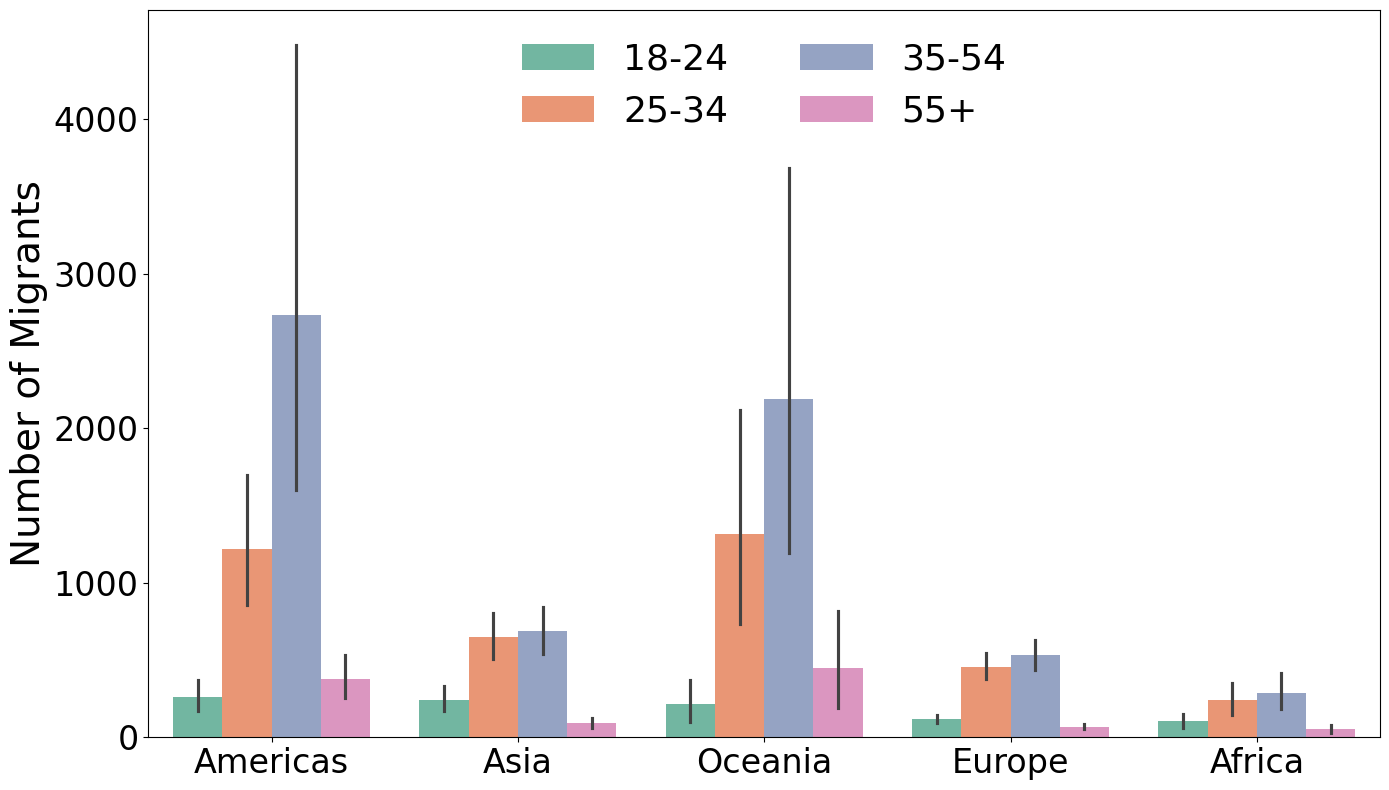

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming you have your DataFrame `df` loaded

# -----------------------------
# 1. Reshape Data for Gender-wise Migration
# -----------------------------
# Melt the data to have 'Gender' and 'Total Migrants' as variables
df_gender = summary_df[['migrated_country', 'region', 'male_migrant', 'female_migrant']]
df_gender = df_gender.melt(id_vars=['migrated_country', 'region'], value_vars=['male_migrant', 'female_migrant'],
                           var_name='Gender', value_name='Total Migrants')


df_gender['Gender'] = df_gender['Gender'].replace({'male_migrant': 'Male', 'female_migrant': 'Female'})

# -----------------------------
# 2. Plot Gender-wise Bar Plot per Region
# -----------------------------
plt.figure(figsize=(14, 8))
sns.barplot(x='region', y='Total Migrants', hue='Gender', data=df_gender, palette="Set1")


plt.legend( loc='upper center', fontsize=24, ncol=2, frameon=False)
#plt.legend(title='Gender', loc='upper left', bbox_to_anchor=(1, 1), ncol=2, frameon=False)  # frameon=False removes the box

#plt.title('Gender-wise Migrant Distribution per Region', fontsize=16)
plt.xlabel('', fontsize=24)
plt.ylabel('Number of Migrants', fontsize=28)
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
plt.tight_layout()
plt.show()

# -----------------------------
# 3. Reshape Data for Age-wise Migration
# -----------------------------
# Select age-wise columns and melt
df_age = summary_df[['migrated_country', 'region', '18to24_migrant', '25to34_migrant', '35_to_54_migrant', '55+_migrant']]
df_age = df_age.melt(id_vars=['migrated_country', 'region'], value_vars=['18to24_migrant', '25to34_migrant', '35_to_54_migrant', '55+_migrant'],
                     var_name='Age Group', value_name='Total Migrants')



df_age['Age Group'] = df_age['Age Group'].replace({
    '18to24_migrant': '18-24', 
    '25to34_migrant': '25-34', 
    '35_to_54_migrant': '35-54', 
    '55+_migrant': '55+'
})


# -----------------------------
# 4. Plot Age-wise Bar Plot per Region
# -----------------------------
plt.figure(figsize=(14, 8))
sns.barplot(x='region', y='Total Migrants', hue='Age Group', data=df_age, palette="Set2")

# Set the legend to be row-wise
plt.legend( loc='upper center', frameon=False, ncol=2, fontsize=26)  # ncol=2 to make it row-wise

#plt.title('Age-wise Migrant Distribution per Region', fontsize=24)
plt.xlabel('', fontsize=24)
plt.ylabel('Number of Migrants', fontsize=28)
plt.xticks( fontsize=24)
plt.yticks(fontsize=24)
plt.tight_layout()
plt.show()


In [24]:
df_gender

,migrated_country,region,Gender,Total Migrants
0,Argentina,Americas,Male,0
1,Armenia,Asia,Male,0
2,Australia,Oceania,Male,2200
3,Austria,Europe,Male,0
4,Azerbaijan,Asia,Male,0
...,...,...,...,...
20801,United States of America,Americas,Female,1000
20802,Uruguay,Americas,Female,0
20803,Uzbekistan,Asia,Female,0
20804,Venezuela (Bolivarian Republic of),Americas,Female,0


In [29]:
from pprint import pprint

pprint(summary_df["subject_country"].tolist())


['Argentina',
 'Argentina',
 'Argentina',
 'Argentina',
 'Argentina',
 'Argentina',
 'Argentina',
 'Argentina',
 'Argentina',
 'Argentina',
 'Argentina',
 'Argentina',
 'Argentina',
 'Argentina',
 'Argentina',
 'Argentina',
 'Argentina',
 'Argentina',
 'Argentina',
 'Argentina',
 'Argentina',
 'Argentina',
 'Argentina',
 'Argentina',
 'Argentina',
 'Argentina',
 'Argentina',
 'Argentina',
 'Argentina',
 'Argentina',
 'Argentina',
 'Argentina',
 'Argentina',
 'Argentina',
 'Argentina',
 'Argentina',
 'Argentina',
 'Argentina',
 'Argentina',
 'Argentina',
 'Argentina',
 'Argentina',
 'Argentina',
 'Argentina',
 'Argentina',
 'Argentina',
 'Argentina',
 'Argentina',
 'Argentina',
 'Argentina',
 'Argentina',
 'Argentina',
 'Argentina',
 'Argentina',
 'Argentina',
 'Argentina',
 'Argentina',
 'Argentina',
 'Argentina',
 'Argentina',
 'Argentina',
 'Argentina',
 'Argentina',
 'Argentina',
 'Argentina',
 'Argentina',
 'Argentina',
 'Argentina',
 'Argentina',
 'Argentina',
 'Argentina',
 'Arge

In [30]:
# pprint(df_clean["country"].tolist())

In [31]:
country_fix_map = {
    # Duplicates / typos
    "Cyprus.1": "North Cyprus",
    "South korea": "South Korea",

    # Political / naming variants
    "Türkiye": "Turkey",
    "Viet Nam": "Vietnam",
    "United States of America": "United States",
    "Venezuela (Bolivarian Republic of)": "Venezuela",

    # China-related
    "China (Mainland)": "China",
    "Hong Kong SAR, China": "Hong Kong",
    "Macao SAR, China": "Macau",
    "Taiwan": "Taiwan",

    # Palestine naming
    "Palestine": "Palestine",

    # Czech
    "Czechia": "Czechia",

    # Korea spelling consistency
    "South Korea": "South Korea",
}


In [32]:
summary_df["migrated_country_clean"] = (
    summary_df["migrated_country"]
    .replace(country_fix_map)
    .str.strip()
)


In [33]:
summary_df

,subject_country,migrated_country,region,total_migrant,male_migrant,female_migrant,18to24_migrant,25to34_migrant,35_to_54_migrant,55+_migrant,subject_region,migrated_country_clean
0,Argentina,Argentina,Americas,0,0,0,0,0,0,0,Americas,Argentina
1,Argentina,Armenia,Asia,0,0,0,0,0,0,0,Americas,Armenia
2,Argentina,Australia,Oceania,5000,2200,2600,0,2200,2400,0,Americas,Australia
3,Argentina,Austria,Europe,0,0,0,0,0,0,0,Americas,Austria
4,Argentina,Azerbaijan,Asia,0,0,0,0,0,0,0,Americas,Azerbaijan
...,...,...,...,...,...,...,...,...,...,...,...,...
10398,Viet Nam,United States of America,Americas,2300,950,1000,0,970,1100,0,Asia,United States
10399,Viet Nam,Uruguay,Americas,0,0,0,0,0,0,0,Asia,Uruguay
10400,Viet Nam,Uzbekistan,Asia,0,0,0,0,0,0,0,Asia,Uzbekistan
10401,Viet Nam,Venezuela (Bolivarian Republic of),Americas,0,0,0,0,0,0,0,Asia,Venezuela


In [34]:
df_clean["country"] = (
    df_clean["country"]
    .str.strip()
)


In [35]:
df_clean

,country,Poverty,PovertyRate_WBDataYear_year_MultiYear,PovertyRate_OECDPctOfPopInPoverty_pct_MultiYear,PovertyRate_OECDDataYearVia_year_MultiYear,Labor Force Participation Rate,LaborForceParticipationTotalPercentage,LaborForceParticipationRateFemalePercentage_2024,LaborForceParticipationRateFemalePercentage,LaborForceParticipationRateMalePercentage_2024,...,UnemploymentRateCIA,Global Peace,Global Terrorism,SafestCountriesIndexViaTravelSafe,RiskLevelByCountryViaTravelSafe,SafestCountriesRankUSNews_2024,Climate Change Perfromance,PoliticalRiskIndex_2021,CountriesWithUniversalHealthcare,HealthCareIndexCEOWorld_2025
0,Afghanistan,54.5,2016.0,NaN,NaN,NaN,41.6,NaN,16.5,NaN,...,14.39,3.229,7.262,14.0,High,NaN,NaN,NaN,NaN,NaN
1,Albania,22.0,2020.0,NaN,NaN,NaN,59.4,NaN,52.3,NaN,...,11.58,1.812,NaN,75.0,Low,NaN,NaN,NaN,Yes,38.65
2,Algeria,5.5,2011.0,NaN,NaN,NaN,40.8,NaN,16.6,NaN,...,11.81,2.042,2.415,44.0,Medium,64.0,45.96,61.0,Yes,34.37
3,American Samoa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Andorra,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.70,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
232,Wallis and Futuna,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
233,Western Sahara,NaN,NaN,NaN,NaN,NaN,56.7,NaN,30.4,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
234,Yemen,48.6,2014.0,NaN,NaN,NaN,38.6,NaN,6.4,NaN,...,17.22,3.262,5.080,10.0,High,NaN,NaN,NaN,NaN,NaN
235,Zambia,60.0,2022.0,NaN,NaN,NaN,60.5,NaN,53.9,NaN,...,5.91,1.914,NaN,52.0,Medium,NaN,NaN,61.0,NaN,NaN


In [36]:
final_df = summary_df.merge(
    df_clean,
    left_on="migrated_country_clean",
    right_on="country",
    how="left"
)
final_df

,subject_country,migrated_country,region,total_migrant,male_migrant,female_migrant,18to24_migrant,25to34_migrant,35_to_54_migrant,55+_migrant,...,UnemploymentRateCIA,Global Peace,Global Terrorism,SafestCountriesIndexViaTravelSafe,RiskLevelByCountryViaTravelSafe,SafestCountriesRankUSNews_2024,Climate Change Perfromance,PoliticalRiskIndex_2021,CountriesWithUniversalHealthcare,HealthCareIndexCEOWorld_2025
0,Argentina,Argentina,Americas,0,0,0,0,0,0,0,...,6.18,1.768,0.801,70.0,Low,53.0,35.96,62.0,Yes,35.64
1,Argentina,Armenia,Asia,0,0,0,0,0,0,0,...,8.59,1.893,0.720,60.0,Low,NaN,NaN,NaN,NaN,NaN
2,Argentina,Australia,Oceania,5000,2200,2600,0,2200,2400,0,...,3.67,1.505,1.973,86.0,Low,9.0,45.52,86.0,Yes,74.11
3,Argentina,Austria,Europe,0,0,0,0,0,0,0,...,5.24,1.294,0.582,92.0,Low,4.0,59.40,88.0,Yes,54.86
4,Argentina,Azerbaijan,Asia,0,0,0,0,0,0,0,...,5.64,2.067,0.233,51.0,Medium,59.0,NaN,75.0,None,37.94
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10398,Viet Nam,United States of America,Americas,2300,950,1000,0,970,1100,0,...,3.63,2.443,3.517,68.0,Low,47.0,40.58,83.0,None,56.71
10399,Viet Nam,Uruguay,Americas,0,0,0,0,0,0,0,...,8.35,1.784,0.059,77.0,Low,56.0,NaN,79.0,None,36.31
10400,Viet Nam,Uzbekistan,Asia,0,0,0,0,0,0,0,...,4.53,1.926,0.233,40.0,Medium,71.0,44.51,NaN,None,36.26
10401,Viet Nam,Venezuela (Bolivarian Republic of),Americas,0,0,0,0,0,0,0,...,5.53,2.692,0.710,33.0,High,NaN,NaN,37.0,None,35.96


In [37]:
final_df.columns

Index(['subject_country', 'migrated_country', 'region', 'total_migrant',
       'male_migrant', 'female_migrant', '18to24_migrant', '25to34_migrant',
       '35_to_54_migrant', '55+_migrant', 'subject_region',
       'migrated_country_clean', 'country', 'Poverty',
       'PovertyRate_WBDataYear_year_MultiYear',
       'PovertyRate_OECDPctOfPopInPoverty_pct_MultiYear',
       'PovertyRate_OECDDataYearVia_year_MultiYear',
       'Labor Force Participation Rate',
       'LaborForceParticipationTotalPercentage',
       'LaborForceParticipationRateFemalePercentage_2024',
       'LaborForceParticipationRateFemalePercentage',
       'LaborForceParticipationRateMalePercentage_2024',
       'LaborForceParticipationRateMalePercentage', 'Life Expectancy',
       'LifeExpectancyFemalesUN_2024', 'LifeExpectancyMalesUN_2024',
       'GiniCoefficientByCountry',
       'GiniCoefficientByCountryMostRecentUpdateYear', 'Social Progress',
       'SocialProgressIndex_Tier_txt_YearFree', 'GDP per Capita', '

In [38]:
final_df['migrated_country_clean'].nunique()

103

In [39]:
exclude_cols = [
    "migrated_country",
    "migrated_country_clean",
    "country"
]


In [40]:
final_df.columns

Index(['subject_country', 'migrated_country', 'region', 'total_migrant',
       'male_migrant', 'female_migrant', '18to24_migrant', '25to34_migrant',
       '35_to_54_migrant', '55+_migrant', 'subject_region',
       'migrated_country_clean', 'country', 'Poverty',
       'PovertyRate_WBDataYear_year_MultiYear',
       'PovertyRate_OECDPctOfPopInPoverty_pct_MultiYear',
       'PovertyRate_OECDDataYearVia_year_MultiYear',
       'Labor Force Participation Rate',
       'LaborForceParticipationTotalPercentage',
       'LaborForceParticipationRateFemalePercentage_2024',
       'LaborForceParticipationRateFemalePercentage',
       'LaborForceParticipationRateMalePercentage_2024',
       'LaborForceParticipationRateMalePercentage', 'Life Expectancy',
       'LifeExpectancyFemalesUN_2024', 'LifeExpectancyMalesUN_2024',
       'GiniCoefficientByCountry',
       'GiniCoefficientByCountryMostRecentUpdateYear', 'Social Progress',
       'SocialProgressIndex_Tier_txt_YearFree', 'GDP per Capita', '

In [41]:
# df =final_df

# import pandas as pd
# import numpy as np
# import seaborn as sns
# import matplotlib.pyplot as plt
# import statsmodels.api as sm
# from sklearn.preprocessing import StandardScaler

# # 1. Define your columns
# cols_to_scale = [
#     'total_migrant',
#  "GDP per Capita",
#     "GDP Growth",
#     "Poverty",
#      "Cost of Living",
#     "Economic Freedom",
#    "Remittances",

#     # Labor
#     "Unemployment Rate",
#     "Labor Force Participation Rate",

#     "Education",
#    "Education Spending per Student",
#  "Literacy Rate",

#  "Life Expectancy",
#  "Healthcare Expenditure",

#   "Political Stability and Governance",
# "Democracy-Dictatorship",

#  "Global Peace",
# "Global Terrorism",
#  'Climate Change Perfromance',
#  # "World Risk",

#  "Global Gender Gap",
#   "Women Peace and Security",
# "Social Progress",
#  "Asylum Grant"
# ]

# # 2. Scaling the data
# # It is important to scale so that the coefficients are comparable
# scaler = StandardScaler()
# df_scaled = pd.DataFrame(scaler.fit_transform(df[cols_to_scale]), columns=cols_to_scale)

# # 3. Correlation Analysis
# # This identifies which factors have the strongest linear relationship with total migration
# correlations = df_scaled.corr()['total_migrant'].drop('total_migrant').sort_values(ascending=False)

# # 4. Regression Analysis: Influence of total_migrant on each factor
# # We run a loop to see how total_migrant (independent) impacts each other variable (dependent)
# regression_results = []

# for col in cols_to_scale:
#     if col == 'total_migrant': continue
    
#     X = sm.add_constant(df_scaled['total_migrant']) # Predictor
#     y = df_scaled[col]                             # Target Factor
    
#     model = sm.OLS(y, X).fit()
    
#     regression_results.append({
#         'Factor': col,
#         'Coefficient (Beta)': model.params['total_migrant'],
#         'P-Value': model.pvalues['total_migrant'],
#         'R-Squared': model.rsquared
#     })

# # Convert to DataFrame for easy viewing
# results_df = pd.DataFrame(regression_results).sort_values(by='P-Value')

# # 5. Visualization
# plt.figure(figsize=(12, 10))
# sns.barplot(x=correlations.values, y=correlations.index, palette='coolwarm')
# plt.title('Correlation Strength: Total Migrant vs Other Factors')
# plt.xlabel('Correlation Coefficient')
# plt.show()

# #print(results_df)

In [42]:
#results_df

In [43]:
# import pandas as pd
# import numpy as np
# import seaborn as sns
# import matplotlib.pyplot as plt
# import statsmodels.api as sm
# from sklearn.preprocessing import StandardScaler

# # Assuming 'final_df' is already defined
# df = final_df

# # Define your columns
# cols_to_scale = [
#     'female_migrant', "GDP per Capita", "GDP Growth", "Poverty", "Cost of Living", 
#     "Economic Freedom", "Remittances", "Unemployment Rate", "Labor Force Participation Rate", 
#     "Education", "Education Spending per Student", "Literacy Rate", "Life Expectancy", 
#     "Healthcare Expenditure", "Political Stability and Governance", "Democracy-Dictatorship", 
#     "Global Peace", "Global Terrorism", 'Climate Change Perfromance', 
#     "Global Gender Gap", "Women Peace and Security", "Social Progress", "Asylum Grant"
# ]

# # Scaling the data
# scaler = StandardScaler()
# df_scaled = pd.DataFrame(scaler.fit_transform(df[cols_to_scale]), columns=cols_to_scale)

# # Correlation Analysis
# correlations = df_scaled.corr()['female_migrant'].drop('female_migrant').sort_values(ascending=False)

# # Regression Analysis: Influence of total_migrant on each factor
# regression_results = []

# for col in cols_to_scale:
#     if col == 'female_migrant': continue
    
#     X = sm.add_constant(df_scaled['female_migrant'])  # Predictor
#     y = df_scaled[col]  # Target Factor
    
#     model = sm.OLS(y, X).fit()
    
#     regression_results.append({
#         'Factor': col,
#         'Coefficient (Beta)': model.params['female_migrant'],
#         'P-Value': model.pvalues['female_migrant'],
#         'R-Squared': model.rsquared
#     })

# # Convert to DataFrame for easy viewing
# results_df = pd.DataFrame(regression_results).sort_values(by='P-Value')

# # Visualization with an innovative horizontal bar plot
# plt.figure(figsize=(12, 10))
# sns.barplot(x=correlations.values, y=correlations.index, palette='coolwarm')

# # Adding annotations to each bar
# for index, value in enumerate(correlations.values):
#     plt.text(value + 0.02, index, f'{value:.2f}', va='center', ha='left', color='black', fontsize=12)

# # Title and labels

# plt.xlabel('Correlation Coefficient', fontsize=14)

# plt.show()

# # Optionally print the regression results DataFrame
# # print(results_df)


In [44]:
#results_df

In [45]:
# import pandas as pd
# import numpy as np
# import seaborn as sns
# import matplotlib.pyplot as plt
# import statsmodels.api as sm
# from sklearn.preprocessing import StandardScaler

# # Assuming 'final_df' is already defined
# df = final_df

# # Define your columns
# cols_to_scale = [
#     'male_migrant', "GDP per Capita", "GDP Growth", "Poverty", "Cost of Living", 
#     "Economic Freedom", "Remittances", "Unemployment Rate", "Labor Force Participation Rate", 
#     "Education", "Education Spending per Student", "Literacy Rate", "Life Expectancy", 
#     "Healthcare Expenditure", "Political Stability and Governance", "Democracy-Dictatorship", 
#     "Global Peace", "Global Terrorism", 'Climate Change Perfromance', 
#     "Global Gender Gap", "Women Peace and Security", "Social Progress", "Asylum Grant"
# ]

# # Scaling the data
# scaler = StandardScaler()
# df_scaled = pd.DataFrame(scaler.fit_transform(df[cols_to_scale]), columns=cols_to_scale)

# # Correlation Analysis
# correlations = df_scaled.corr()['male_migrant'].drop('male_migrant').sort_values(ascending=False)

# # Regression Analysis: Influence of total_migrant on each factor
# regression_results = []

# for col in cols_to_scale:
#     if col == 'male_migrant': continue
    
#     X = sm.add_constant(df_scaled['male_migrant'])  # Predictor
#     y = df_scaled[col]  # Target Factor
    
#     model = sm.OLS(y, X).fit()
    
#     regression_results.append({
#         'Factor': col,
#         'Coefficient (Beta)': model.params['male_migrant'],
#         'P-Value': model.pvalues['male_migrant'],
#         'R-Squared': model.rsquared
#     })

# # Convert to DataFrame for easy viewing
# results_df = pd.DataFrame(regression_results).sort_values(by='P-Value')

# # Visualization with an innovative horizontal bar plot
# plt.figure(figsize=(12, 10))
# sns.barplot(x=correlations.values, y=correlations.index, palette='coolwarm')

# # Adding annotations to each bar
# for index, value in enumerate(correlations.values):
#     plt.text(value + 0.02, index, f'{value:.2f}', va='center', ha='left', color='black', fontsize=12)

# # Title and labels

# plt.xlabel('Correlation Coefficient', fontsize=14)

# plt.show()

# # Optionally print the regression results DataFrame
# # print(results_df)


In [46]:
#results_df

In [47]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import pandas as pd

# # Create DataFrame for coefficients, p-values, and R-squared for all categories
# data = {
#     "Factor": [
#         "Healthcare Expenditure", "GDP per Capita", "Cost of Living", "Climate Change Performance",
#         "Education Spending per Student", "Education", "Global Terrorism", "Social Progress", 
#         "Women Peace and Security", "Democracy-Dictatorship", "Life Expectancy", "Economic Freedom", 
#         "GDP Growth", "Global Gender Gap", "Unemployment Rate", "Literacy Rate", "Poverty", 
#         "Global Peace", "Labor Force Participation Rate", "Political Stability and Governance", "Asylum Grant", "Remittances"
#     ],
#     "Male Coefficient (Beta)": [
#         0.589999, 0.265338, 0.204582, -0.238755, 0.181287, 0.159253, 0.147714, 0.121590, 
#         0.119283, 0.102781, 0.111292, 0.105605, -0.070715, 0.070777, -0.084608, 0.061435, 
#         -0.050396, 0.040138, 0.076574, 0.033013, 0.017564, 0.001794
#     ],
#     "Female Coefficient (Beta)": [
#         0.613537, 0.266061, 0.213078, -0.171380, 0.193066, 0.161210, 0.111139, 0.137053, 
#         0.123028, 0.131415, 0.106198, 0.105230, -0.093829, 0.099643, -0.061027, 0.079109, 
#         -0.039101, 0.047811, 0.022585, 0.036561, 0.006911, 0.000706
#     ],
#     "Total Coefficient (Beta)": [
#         0.604491, 0.264054, 0.207880, -0.200545, 0.187804, 0.158248, 0.132975, 0.128027, 
#         0.120819, 0.119071, 0.106157, 0.101103, -0.082976, 0.082894, -0.074244, 0.070942, 
#         -0.048539, 0.044388, 0.042995, 0.033558, 0.016206, 0.004844
#     ],
#     "P-Value (Total)": [
#         1.368346e-11, 7.035551e-03, 3.511062e-02, 4.223940e-02, 5.747493e-02, 1.103721e-01, 
#         1.805594e-01, 1.974709e-01, 2.241084e-01, 2.309325e-01, 2.858594e-01, 3.095497e-01, 
#         4.046888e-01, 4.051541e-01, 4.560721e-01, 4.764098e-01, 6.263363e-01, 6.561703e-01, 
#         6.663028e-01, 7.364799e-01, 8.709299e-01, 9.612689e-01
#     ]
# }

# # Create a DataFrame
# df_comparison= pd.DataFrame(data)

# df_comparison

In [48]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import pandas as pd

# # Create the DataFrame based on your data
# data = {
#     "Factor": [
#         "Healthcare Expenditure", "GDP per Capita", "Cost of Living", "Climate Change Performance", 
#         "Education Spending per Student", "Education", "Global Terrorism", "Social Progress", 
#         "Women Peace and Security", "Democracy-Dictatorship", "Life Expectancy", "Economic Freedom", 
#         "GDP Growth", "Global Gender Gap", "Unemployment Rate", "Literacy Rate", "Poverty", 
#         "Global Peace", "Labor Force Participation Rate", "Political Stability and Governance", 
#         "Asylum Grant", "Remittances"
#     ],
#     "Male Coefficient (Beta)": [
#         0.589999, 0.265338, 0.204582, -0.238755, 0.181287, 0.159253, 0.147714, 0.121590, 
#         0.119283, 0.102781, 0.111292, 0.105605, -0.070715, 0.070777, -0.084608, 0.061435, 
#         -0.050396, 0.040138, 0.076574, 0.033013, 0.017564, 0.001794
#     ],
#     "Female Coefficient (Beta)": [
#         0.613537, 0.266061, 0.213078, -0.171380, 0.193066, 0.161210, 0.111139, 0.137053, 
#         0.123028, 0.131415, 0.106198, 0.105230, -0.093829, 0.099643, -0.061027, 0.079109, 
#         -0.039101, 0.047811, 0.022585, 0.036561, 0.006911, 0.000706
#     ],
#     "Total Coefficient (Beta)": [
#         0.604491, 0.264054, 0.207880, -0.200545, 0.187804, 0.158248, 0.132975, 0.128027, 
#         0.120819, 0.119071, 0.106157, 0.101103, -0.082976, 0.082894, -0.074244, 0.070942, 
#         -0.048539, 0.044388, 0.042995, 0.033558, 0.016206, 0.004844
#     ]
# }

# df_comparison = pd.DataFrame(data)

# # Visualize the data with a barplot for Male, Female, and Total coefficients
# plt.figure(figsize=(14, 10))

# # Plotting the bar plot for male, female, and total coefficients
# sns.barplot(x="Male Coefficient (Beta)", y="Factor", data=df_comparison, color='lightblue', label='Male', orient='h', ci=None)
# sns.barplot(x="Female Coefficient (Beta)", y="Factor", data=df_comparison, color='pink', label='Female', orient='h', ci=None)
# sns.barplot(x="Total Coefficient (Beta)", y="Factor", data=df_comparison, color='salmon', label='Total', orient='h', ci=None)

# # Adding titles and labels
# #plt.title("Comparison of Factors Influencing Migration (Male, Female, Total)", fontsize=16)
# plt.xlabel("Coefficient (Beta)", fontsize=12)
# plt.ylabel("Factors", fontsize=12)

# # Adding a legend to differentiate between Male, Female, and Total
# plt.legend(title="Groups", loc="lower right")

# # # Annotating the bar plot with the coefficient values
# # for index, row in df_comparison.iterrows():
# #     # Positioning the text to prevent overlapping
# #     plt.text(row["Male Coefficient (Beta)"] + 0.02, index, f'{row["Male Coefficient (Beta)"]:.2f}', 
# #              va='center', ha='left', fontsize=10, color='blue')
# #     plt.text(row["Female Coefficient (Beta)"] + 0.02, index, f'{row["Female Coefficient (Beta)"]:.2f}', 
# #              va='center', ha='left', fontsize=10, color='red')
# #     plt.text(row["Total Coefficient (Beta)"] + 0.02, index, f'{row["Total Coefficient (Beta)"]:.2f}', 
# #              va='center', ha='left', fontsize=10, color='green')

# # Show the plot
# plt.tight_layout()
# plt.show()


In [49]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import pandas as pd
# import numpy as np

# # Example data for the plot (replace this with your actual data)
# data = {
#     'Factor': ["Healthcare Expenditure", "GDP per Capita", "Cost of Living", "Climate Change Performance", 
#                "Education Spending per Student", "Education", "Global Terrorism", "Social Progress", 
#                "Women Peace and Security", "Democracy-Dictatorship", "Life Expectancy", "Economic Freedom", 
#                "GDP Growth", "Global Gender Gap", "Unemployment Rate", "Literacy Rate", "Poverty", 
#                "Global Peace", "Labor Force Participation Rate", "Political Stability and Governance", 
#                "Asylum Grant", "Remittances"],
#     'Male Coefficient (Beta)': [0.589999, 0.265338, 0.204582, -0.238755, 0.181287, 0.159253, 0.147714, 0.121590, 
#                                 0.119283, 0.102781, 0.111292, 0.105605, -0.070715, 0.070777, -0.084608, 0.061435, 
#                                 -0.050396, 0.040138, 0.076574, 0.033013, 0.017564, 0.001794],
#     'Female Coefficient (Beta)': [0.613537, 0.266061, 0.213078, -0.171380, 0.193066, 0.161210, 0.111139, 0.137053, 
#                                   0.123028, 0.131415, 0.106198, 0.105230, -0.093829, 0.099643, -0.061027, 0.079109, 
#                                   -0.039101, 0.047811, 0.022585, 0.036561, 0.006911, 0.000706],
#     'Total Coefficient (Beta)': [0.604491, 0.264054, 0.207880, -0.200545, 0.187804, 0.158248, 0.132975, 0.128027, 
#                                  0.120819, 0.119071, 0.106157, 0.101103, -0.082976, 0.082894, -0.074244, 0.070942, 
#                                  -0.048539, 0.044388, 0.042995, 0.033558, 0.016206, 0.004844],
#     'P-Value (Total)': [1.368346e-11, 7.035551e-03, 3.511062e-02, 4.223940e-02, 5.747493e-02, 1.103721e-01, 
#                         1.805594e-01, 1.974709e-01, 2.241084e-01, 2.309325e-01, 2.858594e-01, 3.095497e-01, 
#                         4.046888e-01, 4.051541e-01, 4.560721e-01, 4.764098e-01, 6.263363e-01, 6.561703e-01, 
#                         6.663028e-01, 7.364799e-01, 8.709299e-01, 9.612689e-01]
# }

# # Convert to DataFrame
# df_comparison = pd.DataFrame(data)

# # Reshape the data into long-form for hue bar plot
# df_long = pd.melt(df_comparison, id_vars=['Factor', 'P-Value (Total)'], value_vars=['Male Coefficient (Beta)', 'Female Coefficient (Beta)', 'Total Coefficient (Beta)'],
#                   var_name='Category', value_name='Coefficient (Beta)')

# # Set up the figure
# plt.figure(figsize=(14, 10))

# # Plot for Male, Female, and Total Coefficients with hue
# sns.barplot(x='Coefficient (Beta)', y='Factor', hue='Category', data=df_long, palette='Set2', orient='h', ci=None)

# # Annotating p-values on the plot
# for i, row in df_comparison.iterrows():
#     p_value = row['P-Value (Total)']
#     # Based on p-value, display '*' accordingly
#     if p_value < 0.001:
#         label = '***'
#     elif p_value < 0.01:
#         label = '**'
#     elif p_value < 0.05:
#         label = '*'
#     else:
#         label = ''
    
#     # Positioning the text on the bars
#     plt.text(row['Total Coefficient (Beta)'] + 0.02, i, label, va='center', fontsize=12)

# # Set titles and labels
# plt.title('Factors Influencing Migration: Male, Female, and Total Coefficients with P-Value Annotations', fontsize=16)
# plt.xlabel('Coefficient (Beta)', fontsize=14)
# plt.ylabel('Factors', fontsize=14)

# # Add a legend
# plt.legend(title="Category")

# # Show the plot
# plt.tight_layout()
# plt.show()


In [50]:
# import pandas as pd
# import numpy as np
# import seaborn as sns
# import matplotlib.pyplot as plt
# import statsmodels.api as sm
# from sklearn.preprocessing import StandardScaler

# # Assuming 'final_df' is already defined
# df = final_df

# # Define your columns
# cols_to_scale = [
#     'total_migrant', "GDP per Capita", "GDP Growth", "Poverty", "Cost of Living", 
#     "Economic Freedom", "Remittances", "Unemployment Rate", "Labor Force Participation Rate", 
#     "Education", "Education Spending per Student", "Literacy Rate", "Life Expectancy", 
#     "Healthcare Expenditure", "Political Stability and Governance", "Democracy-Dictatorship", 
#     "Global Peace", "Global Terrorism", 'Climate Change Perfromance', 
#     "Global Gender Gap", "Women Peace and Security", "Social Progress", "Asylum Grant"
# ]

# # Scaling the data
# scaler = StandardScaler()
# df_scaled = pd.DataFrame(scaler.fit_transform(df[cols_to_scale]), columns=cols_to_scale)

# # Correlation Analysis
# correlations = df_scaled.corr()['total_migrant'].drop('total_migrant').sort_values(ascending=False)

# # Regression Analysis: Influence of total_migrant on each factor
# regression_results = []

# for col in cols_to_scale:
#     if col == 'total_migrant': continue
    
#     X = sm.add_constant(df_scaled['total_migrant'])  # Predictor
#     y = df_scaled[col]  # Target Factor
    
#     model = sm.OLS(y, X).fit()
    
#     regression_results.append({
#         'Factor': col,
#         'Coefficient (Beta)': model.params['total_migrant'],
#         'P-Value': model.pvalues['total_migrant'],
#         'R-Squared': model.rsquared
#     })

# # Convert to DataFrame for easy viewing
# results_df = pd.DataFrame(regression_results).sort_values(by='P-Value')

# # Visualization with an innovative horizontal bar plot
# plt.figure(figsize=(12, 10))
# sns.barplot(x=correlations.values, y=correlations.index, palette='coolwarm')

# # Adding annotations to each bar
# for index, value in enumerate(correlations.values):
#     plt.text(value + 0.02, index, f'{value:.2f}', va='center', ha='left', color='black', fontsize=12)

# # Title and labels

# plt.xlabel('Correlation Coefficient', fontsize=14)

# plt.show()

# # Optionally print the regression results DataFrame
# # print(results_df)


In [51]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Select numeric columns only
numeric_cols = final_df.select_dtypes(include=[np.number]).columns.tolist()

# Remove excluded columns if they appear
numeric_cols = [c for c in numeric_cols if c not in exclude_cols]

print("Columns to be scaled:")
print(numeric_cols)


Columns to be scaled:
['total_migrant', 'male_migrant', 'female_migrant', '18to24_migrant', '25to34_migrant', '35_to_54_migrant', '55+_migrant', 'Poverty', 'PovertyRate_WBDataYear_year_MultiYear', 'PovertyRate_OECDPctOfPopInPoverty_pct_MultiYear', 'PovertyRate_OECDDataYearVia_year_MultiYear', 'Labor Force Participation Rate', 'LaborForceParticipationTotalPercentage', 'LaborForceParticipationRateFemalePercentage_2024', 'LaborForceParticipationRateFemalePercentage', 'LaborForceParticipationRateMalePercentage_2024', 'LaborForceParticipationRateMalePercentage', 'Life Expectancy', 'LifeExpectancyFemalesUN_2024', 'LifeExpectancyMalesUN_2024', 'GiniCoefficientByCountry', 'GiniCoefficientByCountryMostRecentUpdateYear', 'Social Progress', 'GDP per Capita', 'GDP Growth', 'Political Stability and Governance', 'PoliticalStabilityGovernanceValue_2023', 'PoliticalStabilityPercentileRank_2023', 'density', 'densityMi', 'population', 'area', 'Remittances', 'Women Peace and Security', 'WomensDangerIndex

In [52]:
import pandas as pd

# Assuming you already have your dataframe loaded as 'df'

# List of numeric columns (you can specify them manually or use df.select_dtypes to select numeric columns)
numeric_cols =final_df.select_dtypes(include=['float64', 'int64']).columns

# Group by subject_country and region, then calculate the mean for each numeric column
df_grouped = final_df.groupby(['subject_country', 'region'])[numeric_cols].mean().reset_index()

# Display the resulting dataframe
print(df_grouped)


    subject_country    region  total_migrant  male_migrant  female_migrant  \
0         Argentina    Africa      29.090909      0.000000        0.000000   
1         Argentina  Americas    6091.578947   2865.263158     2833.684211   
2         Argentina      Asia     151.891892     57.837838       28.378378   
3         Argentina    Europe    1392.058824    582.058824      717.941176   
4         Argentina   Oceania    3050.000000   1340.000000     1595.000000   
..              ...       ...            ...           ...             ...   
500        Viet Nam    Africa       0.000000      0.000000        0.000000   
501        Viet Nam  Americas     161.052632     67.368421       52.631579   
502        Viet Nam      Asia      55.135135     11.891892        9.459459   
503        Viet Nam    Europe      25.294118      0.000000        0.000000   
504        Viet Nam   Oceania     550.000000    225.000000      245.000000   

     18to24_migrant  25to34_migrant  35_to_54_migrant  55+_migr

In [53]:
#2final_df = df_grouped

In [54]:
# region_means = final_df.groupby('region')[numeric_cols].transform('median')

# print(region_means)

In [55]:
# print(region_means.head())  # Inspect the first few rows of region_means

#region_means = final_df.groupby(['region'])[numeric_cols].mean().reset_index()
region_means = final_df.groupby('region')[numeric_cols].mean()

region_means[ numeric_cols] = region_means[ numeric_cols].fillna(region_means[ numeric_cols].mean())
region_means  # To verify region-wise means





,total_migrant,male_migrant,female_migrant,18to24_migrant,25to34_migrant,35_to_54_migrant,55+_migrant,Poverty,PovertyRate_WBDataYear_year_MultiYear,PovertyRate_OECDPctOfPopInPoverty_pct_MultiYear,...,USNewsMostTechnologicalExpertise_2024,Unemployment Rate,UnemploymentRateCIA,Global Peace,Global Terrorism,SafestCountriesIndexViaTravelSafe,SafestCountriesRankUSNews_2024,Climate Change Perfromance,PoliticalRiskIndex_2021,HealthCareIndexCEOWorld_2025
region,,,,,,,,,,,,,,,,,,,,,
Africa,743.249325,344.347435,197.470747,102.295230,239.963996,289.252925,51.224122,29.900000,2016.500000,27.700000,...,2.560000,10.240000,9.806364,2.398091,3.675000,46.363636,63.333333,60.185000,60.666667,30.773000
Americas,4572.855654,1732.673267,2132.902553,261.104742,1217.097447,2728.973424,374.726420,30.106667,2020.857143,16.950000,...,11.993333,5.957895,5.728947,2.160111,2.016417,57.421053,60.400000,48.514286,69.000000,37.319444
Asia,1701.742039,788.370351,500.869682,239.132994,646.111854,685.349211,90.751940,15.365000,2019.238095,15.075000,...,27.723077,4.845455,5.608286,2.059576,2.934833,57.968750,50.307692,45.042353,73.583333,42.030645
Europe,1274.015725,517.600466,506.301689,117.926616,456.357018,531.741409,67.527665,15.300000,2020.852941,10.435714,...,21.131250,5.718182,5.797941,1.634438,1.425840,78.176471,25.281250,58.383667,79.869565,48.536176
Oceania,4169.306931,1866.534653,1709.158416,218.267327,1315.000000,2188.217822,448.465347,22.667917,2019.362045,13.450000,...,27.550000,4.500000,3.705000,1.393500,1.095000,88.000000,8.500000,48.290000,86.500000,62.130000


In [56]:
# df_scaled[ numeric_cols] = df_scaled[ numeric_cols].fillna(df_scaled[ numeric_cols].median())


# Replace NaN values with 0 for the selected numeric columns
#df_scaled[numeric_cols] = df_scaled[numeric_cols].fillna(0)
# df_scaled = df_scaled.dropna(subset=numeric_cols)

# Group the data by region and calculate the mean for each column
# region_means = final_df.groupby('region')[numeric_cols].transform('median')
# #region_means = final_df.groupby('region')[numeric_cols].mean()
# print(region_means.head())  # To verify region-wise means

# For each column, fill NaN values in the rows with the respective region's mean value
# for column in numeric_cols:
#     final_df[column] = final_df.apply(
#         lambda row: region_means.loc[row['region'], column] if pd.isna(row[column]) and row['region'] in region_means.index else row[column], 
#         axis=1
#     )

# # Display the cleaned dataframe
# final_df

# Replace NaN values in a specific column with the regional mean for that column
#column_to_fill = numeric_cols  # Replace with the column name you want to fill NaN values for
# Loop through each numeric column and replace NaN values with the respective region's mean
for column in numeric_cols:
    final_df[column] = final_df.apply(
        lambda row: region_means.loc[row['region'], column] if pd.isna(row[column]) else row[column],
        axis=1
    )



In [57]:
final_df

,subject_country,migrated_country,region,total_migrant,male_migrant,female_migrant,18to24_migrant,25to34_migrant,35_to_54_migrant,55+_migrant,...,UnemploymentRateCIA,Global Peace,Global Terrorism,SafestCountriesIndexViaTravelSafe,RiskLevelByCountryViaTravelSafe,SafestCountriesRankUSNews_2024,Climate Change Perfromance,PoliticalRiskIndex_2021,CountriesWithUniversalHealthcare,HealthCareIndexCEOWorld_2025
0,Argentina,Argentina,Americas,0,0,0,0,0,0,0,...,6.18,1.768,0.801000,70.0,Low,53.000000,35.960000,62.000000,Yes,35.640000
1,Argentina,Armenia,Asia,0,0,0,0,0,0,0,...,8.59,1.893,0.720000,60.0,Low,50.307692,45.042353,73.583333,NaN,42.030645
2,Argentina,Australia,Oceania,5000,2200,2600,0,2200,2400,0,...,3.67,1.505,1.973000,86.0,Low,9.000000,45.520000,86.000000,Yes,74.110000
3,Argentina,Austria,Europe,0,0,0,0,0,0,0,...,5.24,1.294,0.582000,92.0,Low,4.000000,59.400000,88.000000,Yes,54.860000
4,Argentina,Azerbaijan,Asia,0,0,0,0,0,0,0,...,5.64,2.067,0.233000,51.0,Medium,59.000000,45.042353,75.000000,None,37.940000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10398,Viet Nam,United States of America,Americas,2300,950,1000,0,970,1100,0,...,3.63,2.443,3.517000,68.0,Low,47.000000,40.580000,83.000000,None,56.710000
10399,Viet Nam,Uruguay,Americas,0,0,0,0,0,0,0,...,8.35,1.784,0.059000,77.0,Low,56.000000,48.514286,79.000000,None,36.310000
10400,Viet Nam,Uzbekistan,Asia,0,0,0,0,0,0,0,...,4.53,1.926,0.233000,40.0,Medium,71.000000,44.510000,73.583333,None,36.260000
10401,Viet Nam,Venezuela (Bolivarian Republic of),Americas,0,0,0,0,0,0,0,...,5.53,2.692,0.710000,33.0,High,60.400000,48.514286,37.000000,None,35.960000


In [58]:

X_vars = [   'Poverty',
 'PovertyRate_WBDataYear_year_MultiYear',
 'PovertyRate_OECDPctOfPopInPoverty_pct_MultiYear',
 'PovertyRate_OECDDataYearVia_year_MultiYear',
 'Labor Force Participation Rate',
 'LaborForceParticipationTotalPercentage',
 'LaborForceParticipationRateFemalePercentage_2024',
 'LaborForceParticipationRateFemalePercentage',
 'LaborForceParticipationRateMalePercentage_2024',
 'LaborForceParticipationRateMalePercentage',
 'Life Expectancy',
 'LifeExpectancyFemalesUN_2024',
 'LifeExpectancyMalesUN_2024',
 'GiniCoefficientByCountry',
 'GiniCoefficientByCountryMostRecentUpdateYear',
 'Social Progress',
 'GDP per Capita',
 'GDP Growth',
 'Political Stability and Governance',
 'PoliticalStabilityGovernanceValue_2023',
 'PoliticalStabilityPercentileRank_2023',
 'density',
 'densityMi',
 'population',
 'area',
 'Remittances',
 'Women Peace and Security',
 'WomensDangerIndexWDI_2019',
 'GDPPerCapitaViaIMF_2025_y',
 'GDPPerCapitaViaUN_2023',
 'EducationRankingUSNews_2024',
 'EducationRankingsWorldTop20_2024',
 'Healthcare Expenditure',
 'TotalHealthExpenditureRateAsPctOfGDP_2022',
 'SocialWelfareSpending_SocialAssistanceProgramsPctofGDP_pct_MultiYear',
 'SocialExpenditurePerCapita_2021',
 'Economic Freedom',
 'Democracy-Dictatorship',
 'Education',
 'Asylum Grant',
 'AsylumDenialRate_2023',
 'AsylumOtherRate_2023',
 'World Risk',
 'NaturalDisasterRiskExposure_2024',
 'NaturalDisasterRiskVulnerablity_2024',
 'Global Gender Gap',
 'EducationSpending_PctOfGDP_pct_MultiYear',
 'EducationSpending_DataYear_year_MultiYear',
 'Education Spending per Student',
 'Cost of Living',
 'CostOfLivingCountryRentIndexViaNumbeo_2025',
 'CostOfLivingPlusRentIndexViaNumbeo_2025',
 'Literacy Rate',
 'LiteracyRate_Male_pct_MultiYear',
 'LiteracyRate_Female_pct_MultiYear',
 'LiteracyRate_DataYear_year_MultiYear',
 'USNewsMostTechnologicalExpertise_2024',
 'Unemployment Rate',
 'UnemploymentRateCIA',
 'Global Peace',
 'Global Terrorism',
 'SafestCountriesIndexViaTravelSafe',
 'SafestCountriesRankUSNews_2024',
 'Climate Change Perfromance',
 'PoliticalRiskIndex_2021',
 'HealthCareIndexCEOWorld_2025']

In [245]:
scaler = MinMaxScaler()

df_scaled = final_df.copy()

df_scaled[X_vars] = scaler.fit_transform(df_scaled[X_vars])


In [246]:
import statsmodels.api as sm


df_scaled["log_total_migrant"] = np.log1p(df_scaled["total_migrant"])




# Define the Independent Variables (X) and Dependent Variable (y)
# X_vars = [
#     "GDP per Capita", "GDP Growth", "Poverty", "Cost of Living", 
#     "Economic Freedom", "Remittances", "Unemployment Rate", "Labor Force Participation Rate", 
#     "Education", "Education Spending per Student", "Literacy Rate", "Life Expectancy", 
#     "Healthcare Expenditure", "Political Stability and Governance", "Democracy-Dictatorship", 
#     "Global Peace", "Global Terrorism", "Climate Change Perfromance", 
#     "Global Gender Gap", "Women Peace and Security", "Social Progress", "Asylum Grant"
# ]


X_vars = [   'Poverty',
 'PovertyRate_WBDataYear_year_MultiYear',
 'PovertyRate_OECDPctOfPopInPoverty_pct_MultiYear',
 'PovertyRate_OECDDataYearVia_year_MultiYear',
 'Labor Force Participation Rate',
 'LaborForceParticipationTotalPercentage',
 'LaborForceParticipationRateFemalePercentage_2024',
 'LaborForceParticipationRateFemalePercentage',
 'LaborForceParticipationRateMalePercentage_2024',
 'LaborForceParticipationRateMalePercentage',
 'Life Expectancy',
 'LifeExpectancyFemalesUN_2024',
 'LifeExpectancyMalesUN_2024',
 'GiniCoefficientByCountry',
 'GiniCoefficientByCountryMostRecentUpdateYear',
 'Social Progress',
 'GDP per Capita',
 'GDP Growth',
 'Political Stability and Governance',
 'PoliticalStabilityGovernanceValue_2023',
 'PoliticalStabilityPercentileRank_2023',
 'density',
 'densityMi',
 'population',
 'area',
 'Remittances',
 'Women Peace and Security',
 'WomensDangerIndexWDI_2019',
 'GDPPerCapitaViaIMF_2025_y',
 'GDPPerCapitaViaUN_2023',
 'EducationRankingUSNews_2024',
 'EducationRankingsWorldTop20_2024',
 'Healthcare Expenditure',
 'TotalHealthExpenditureRateAsPctOfGDP_2022',
 'SocialWelfareSpending_SocialAssistanceProgramsPctofGDP_pct_MultiYear',
 'SocialExpenditurePerCapita_2021',
 'Economic Freedom',
 'Democracy-Dictatorship',
 'Education',
 'Asylum Grant',
 'AsylumDenialRate_2023',
 'AsylumOtherRate_2023',
 'World Risk',
 'NaturalDisasterRiskExposure_2024',
 'NaturalDisasterRiskVulnerablity_2024',
 'Global Gender Gap',
 'EducationSpending_PctOfGDP_pct_MultiYear',
 'EducationSpending_DataYear_year_MultiYear',
 'Education Spending per Student',
 'Cost of Living',
 'CostOfLivingCountryRentIndexViaNumbeo_2025',
 'CostOfLivingPlusRentIndexViaNumbeo_2025',
 'Literacy Rate',
 'LiteracyRate_Male_pct_MultiYear',
 'LiteracyRate_Female_pct_MultiYear',
 'LiteracyRate_DataYear_year_MultiYear',
 'USNewsMostTechnologicalExpertise_2024',
 'Unemployment Rate',
 'UnemploymentRateCIA',
 'Global Peace',
 'Global Terrorism',
 'SafestCountriesIndexViaTravelSafe',
 'SafestCountriesRankUSNews_2024',
 'Climate Change Perfromance',
 'PoliticalRiskIndex_2021',
 'HealthCareIndexCEOWorld_2025']

X =df_scaled[X_vars]
y = df_scaled['log_total_migrant']

# Add a constant (intercept) to the model
X = sm.add_constant(X)

# Fit the Ordinary Least Squares (OLS) model
model = sm.OLS(y, X).fit()

# View the results
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      log_total_migrant   R-squared:                       0.199
Model:                            OLS   Adj. R-squared:                  0.194
Method:                 Least Squares   F-statistic:                     39.57
Date:                Wed, 04 Feb 2026   Prob (F-statistic):               0.00
Time:                        09:47:37   Log-Likelihood:                -26233.
No. Observations:               10403   AIC:                         5.260e+04
Df Residuals:                   10337   BIC:                         5.308e+04
Df Model:                          65                                         
Covariance Type:            nonrobust                                         
========================================================================================================================================
                                                                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------------------------------
const                                                                   12.0228     13.181      0.912      0.362     -13.814      37.860
Poverty                                                                 -2.2592      0.383     -5.903      0.000      -3.009      -1.509
PovertyRate_WBDataYear_year_MultiYear                                   -2.0246      0.446     -4.544      0.000      -2.898      -1.151
PovertyRate_OECDPctOfPopInPoverty_pct_MultiYear                          1.0623      0.404      2.629      0.009       0.270       1.854
PovertyRate_OECDDataYearVia_year_MultiYear                               0.4971      0.467      1.064      0.287      -0.419       1.413
Labor Force Participation Rate                                           0.0886      2.773      0.032      0.975      -5.347       5.524
LaborForceParticipationTotalPercentage                                  -1.9039      2.551     -0.746      0.456      -6.905       3.097
LaborForceParticipationRateFemalePercentage_2024                        -1.6573      1.729     -0.959      0.338      -5.046       1.731
LaborForceParticipationRateFemalePercentage                              1.5694      1.673      0.938      0.348      -1.710       4.849
LaborForceParticipationRateMalePercentage_2024                          -0.4132      2.051     -0.201      0.840      -4.434       3.608
LaborForceParticipationRateMalePercentage                                0.8417      1.679      0.501      0.616      -2.450       4.134
Life Expectancy                                                         29.0204     23.513      1.234      0.217     -17.069      75.110
LifeExpectancyFemalesUN_2024                                           -28.5534     12.831     -2.225      0.026     -53.705      -3.401
LifeExpectancyMalesUN_2024                                              -5.1146     10.958     -0.467      0.641     -26.594      16.365
GiniCoefficientByCountry                                                -1.1653      0.441     -2.645      0.008      -2.029      -0.302
GiniCoefficientByCountryMostRecentUpdateYear                             0.6634      0.406      1.634      0.102      -0.133       1.459
Social Progress                                                          2.7959      1.088      2.570      0.010       0.664       4.928
GDP per Capita                                                           3.9055      4.322      0.904      0.366      -4.567      12.378
GDP Growth                                                               0.7196      0.563      1.278      0.201      -0.384       1.824
Political Stability and Governance                                   

In [247]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      log_total_migrant   R-squared:                       0.199
Model:                            OLS   Adj. R-squared:                  0.194
Method:                 Least Squares   F-statistic:                     39.57
Date:                Wed, 04 Feb 2026   Prob (F-statistic):               0.00
Time:                        09:47:37   Log-Likelihood:                -26233.
No. Observations:               10403   AIC:                         5.260e+04
Df Residuals:                   10337   BIC:                         5.308e+04
Df Model:                          65                                         
Covariance Type:            nonrobust                                         
========================================================================================================================================
                                                                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------------------------------
const                                                                   12.0228     13.181      0.912      0.362     -13.814      37.860
Poverty                                                                 -2.2592      0.383     -5.903      0.000      -3.009      -1.509
PovertyRate_WBDataYear_year_MultiYear                                   -2.0246      0.446     -4.544      0.000      -2.898      -1.151
PovertyRate_OECDPctOfPopInPoverty_pct_MultiYear                          1.0623      0.404      2.629      0.009       0.270       1.854
PovertyRate_OECDDataYearVia_year_MultiYear                               0.4971      0.467      1.064      0.287      -0.419       1.413
Labor Force Participation Rate                                           0.0886      2.773      0.032      0.975      -5.347       5.524
LaborForceParticipationTotalPercentage                                  -1.9039      2.551     -0.746      0.456      -6.905       3.097
LaborForceParticipationRateFemalePercentage_2024                        -1.6573      1.729     -0.959      0.338      -5.046       1.731
LaborForceParticipationRateFemalePercentage                              1.5694      1.673      0.938      0.348      -1.710       4.849
LaborForceParticipationRateMalePercentage_2024                          -0.4132      2.051     -0.201      0.840      -4.434       3.608
LaborForceParticipationRateMalePercentage                                0.8417      1.679      0.501      0.616      -2.450       4.134
Life Expectancy                                                         29.0204     23.513      1.234      0.217     -17.069      75.110
LifeExpectancyFemalesUN_2024                                           -28.5534     12.831     -2.225      0.026     -53.705      -3.401
LifeExpectancyMalesUN_2024                                              -5.1146     10.958     -0.467      0.641     -26.594      16.365
GiniCoefficientByCountry                                                -1.1653      0.441     -2.645      0.008      -2.029      -0.302
GiniCoefficientByCountryMostRecentUpdateYear                             0.6634      0.406      1.634      0.102      -0.133       1.459
Social Progress                                                          2.7959      1.088      2.570      0.010       0.664       4.928
GDP per Capita                                                           3.9055      4.322      0.904      0.366      -4.567      12.378
GDP Growth                                                               0.7196      0.563      1.278      0.201      -0.384       1.824
Political Stability and Governance                                   

/var/folders/80/yf8_sdln22lbcp569mzlrg040000gn/T/ipykernel_1177/2860460577.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


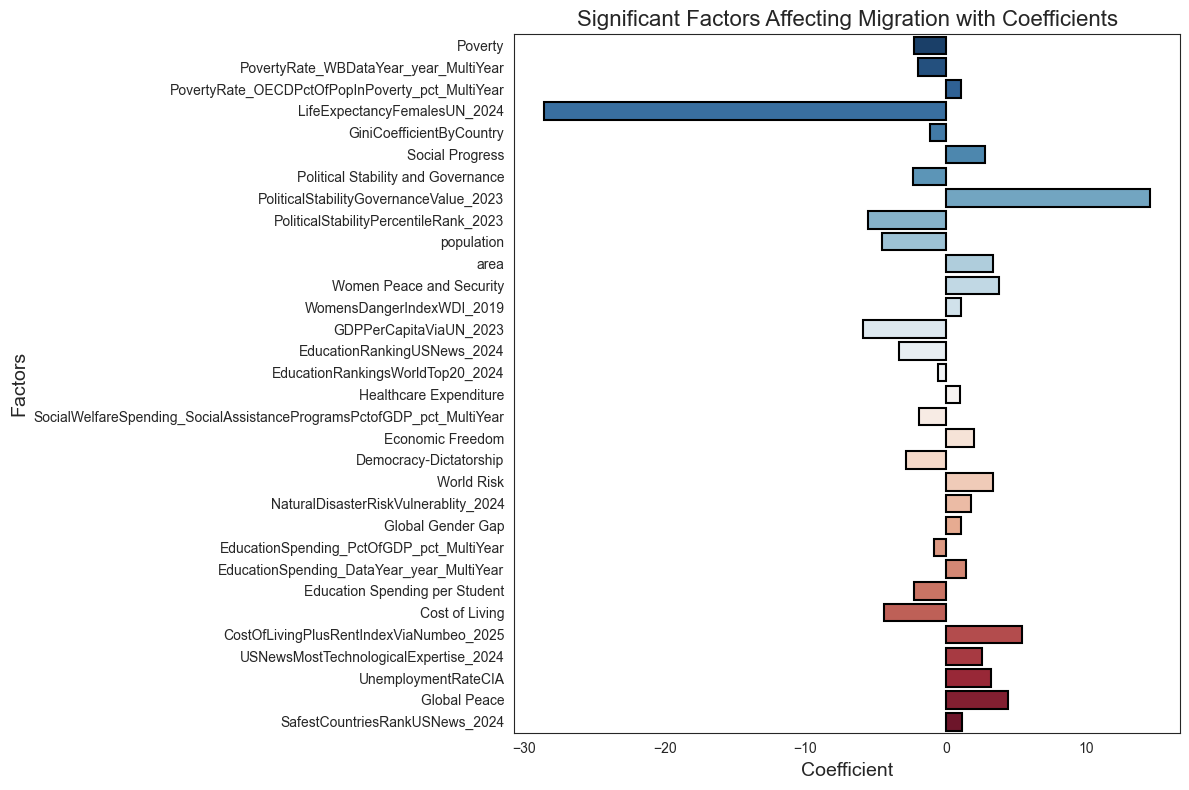

In [248]:
# -----------------------------
# 3. Extract coefficients and p-values
# -----------------------------
coefficients = model.params
p_values = model.pvalues

# Create a DataFrame for the coefficients and p-values
results_df = pd.DataFrame({
    'Factor': coefficients.index,
    'Coefficient': coefficients.values,
    'P-Value': p_values.values
})

# -----------------------------
# 4. Filter significant factors (p-value < 0.05)
# -----------------------------
significant_factors = results_df[results_df["P-Value"] < 0.1]

# -----------------------------
# 5. Plot the bar plot for significant factors
# -----------------------------
plt.figure(figsize=(12, 8))
sns.barplot(
    data=significant_factors,
    y="Factor",
    x="Coefficient",
    palette="RdBu_r",
    edgecolor="black",
    linewidth=1.5
)

plt.title('Significant Factors Affecting Migration with Coefficients', fontsize=16)
plt.xlabel('Coefficient', fontsize=14)
plt.ylabel('Factors', fontsize=14)
plt.tight_layout()
plt.show()

In [249]:
df_scaled

,subject_country,migrated_country,region,total_migrant,male_migrant,female_migrant,18to24_migrant,25to34_migrant,35_to_54_migrant,55+_migrant,...,Global Peace,Global Terrorism,SafestCountriesIndexViaTravelSafe,RiskLevelByCountryViaTravelSafe,SafestCountriesRankUSNews_2024,Climate Change Perfromance,PoliticalRiskIndex_2021,CountriesWithUniversalHealthcare,HealthCareIndexCEOWorld_2025,log_total_migrant
0,Argentina,Argentina,Americas,0,0,0,0,0,0,0,...,0.287730,0.089236,0.691358,Low,0.590909,0.295749,0.471698,Yes,0.271313,0.000000
1,Argentina,Armenia,Asia,0,0,0,0,0,0,0,...,0.341171,0.079495,0.567901,Low,0.560315,0.446568,0.690252,NaN,0.379409,0.000000
2,Argentina,Australia,Oceania,5000,2200,2600,0,2200,2400,0,...,0.175289,0.230186,0.888889,Low,0.090909,0.454500,0.924528,Yes,0.922023,8.517393
3,Argentina,Austria,Europe,0,0,0,0,0,0,0,...,0.085079,0.062898,0.962963,Low,0.034091,0.684988,0.962264,Yes,0.596414,0.000000
4,Argentina,Azerbaijan,Asia,0,0,0,0,0,0,0,...,0.415562,0.020926,0.456790,Medium,0.659091,0.446568,0.716981,None,0.310217,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10398,Viet Nam,United States of America,Americas,2300,950,1000,0,970,1100,0,...,0.576315,0.415875,0.666667,Low,0.522727,0.372468,0.867925,None,0.627706,7.741099
10399,Viet Nam,Uruguay,Americas,0,0,0,0,0,0,0,...,0.294570,0.000000,0.777778,Low,0.625000,0.504223,0.792453,None,0.282645,0.000000
10400,Viet Nam,Uzbekistan,Asia,0,0,0,0,0,0,0,...,0.355280,0.020926,0.320988,Medium,0.795455,0.437728,0.690252,None,0.281800,0.000000
10401,Viet Nam,Venezuela (Bolivarian Republic of),Americas,0,0,0,0,0,0,0,...,0.682770,0.078292,0.234568,High,0.675000,0.504223,0.000000,None,0.276725,0.000000


In [260]:

import numpy as np

df_scaled["log_total_migrant"] = np.log1p(df_scaled["total_migrant"])




# Renaming the columns to match the regression formula
df_scaled.rename(columns={
    'GDP per Capita': 'GDP_per_Capita',
    'Cost of Living': 'Cost_of_Living',
    'Economic Freedom': 'Economic_Freedom',
    'Unemployment Rate': 'Unemployment_Rate',
    'Labor Force Participation Rate': 'Labor_Force_Participation_Rate',
    'Education Spending per Student': 'Education_Spending_per_Student',
    'Literacy Rate': 'Literacy_Rate',
    'Life Expectancy': 'Life_Expectancy',
    'Healthcare Expenditure': 'Healthcare_Expenditure',
    'Political Stability and Governance': 'Political_Stability_and_Governance',
    'Global Peace': 'Global_Peace',
    'Global Terrorism': 'Global_Terrorism',
    'Climate Change Perfromance': 'Climate_Change_Performance',
    'Global Gender Gap': 'Global_Gender_Gap',
    'Women Peace and Security': 'Women_Peace_and_Security',
    'Social Progress': 'Social_Progress',
    'Asylum Grant': 'Asylum_Grant',
    'region': 'region',
    'Democracy-Dictatorship': 'Democracy',
    'Literacy Rate':'Literacy_Rate',
    'Social Progress': 'Social_Progress',
    'SafestCountriesRankUSNews_2024':'Safest_country',
    'SocialWelfareSpending_SocialAssistanceProgramsPctofGDP_pct_MultiYear':'Social_Welfare_Spending',
}, inplace=True)



# List of numeric columns
numeric_cols = ['GDP_per_Capita', 'Cost_of_Living', 'Economic_Freedom', 'Unemployment_Rate', 
                'Labor_Force_Participation_Rate', 'Education_Spending_per_Student', 'Literacy_Rate', 
                'Life_Expectancy', 'Healthcare_Expenditure', 'Political_Stability_and_Governance', 
                'Global_Peace', 'Global_Terrorism', 'Climate_Change_Performance', 'Global_Gender_Gap', 
                'Women_Peace_and_Security', 'Social_Progress', 'Asylum_Grant']

# Drop rows with NaN values in the renamed numeric columns
df_scaled = df_scaled.dropna(subset=numeric_cols)


# Now, you can proceed with the regression analysis using the updated column names
import statsmodels.formula.api as smf

# Define the formula
formula = "log_total_migrant ~density+area+GDP_per_Capita+ Democracy+Global_Gender_Gap +Social_Welfare_Spending+ Poverty + Cost_of_Living + Economic_Freedom + Remittances + Unemployment_Rate + Education + Life_Expectancy + Healthcare_Expenditure + Climate_Change_Performance  + Women_Peace_and_Security  +Global_Peace+ Unemployment_Rate-1"

# Fit the OLS model
model = smf.ols(formula=formula, data=df_scaled)
results = model.fit()

# Print the regression summary
results.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:      log_total_migrant   R-squared (uncentered):                   0.336
Model:                            OLS   Adj. R-squared (uncentered):              0.335
Method:                 Least Squares   F-statistic:                              308.9
Date:                Wed, 04 Feb 2026   Prob (F-statistic):                        0.00
Time:                        09:54:22   Log-Likelihood:                         -26786.
No. Observations:               10403   AIC:                                  5.361e+04
Df Residuals:                   10386   BIC:                                  5.373e+04
Df Model:                          17                                                  
Covariance Type:            nonrobust                                                  
==============================================================================================
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
density                       -1.6285      0.330     -4.934      0.000      -2.276      -0.981
area                           4.1479      0.179     23.153      0.000       3.797       4.499
GDP_per_Capita                 1.8706      0.348      5.373      0.000       1.188       2.553
Democracy                      1.1055      0.210      5.261      0.000       0.694       1.517
Global_Gender_Gap             -0.6090      0.303     -2.008      0.045      -1.204      -0.014
Social_Welfare_Spending       -0.2520      0.303     -0.832      0.406      -0.846       0.342
Poverty                       -0.2979      0.225     -1.324      0.185      -0.739       0.143
Cost_of_Living                 0.6038      0.392      1.539      0.124      -0.165       1.373
Economic_Freedom               0.6388      0.248      2.577      0.010       0.153       1.125
Remittances                    1.0732      0.206      5.198      0.000       0.668       1.478
Unemployment_Rate             -0.6846      0.276     -2.477      0.013      -1.226      -0.143
Education                      0.9474      0.375      2.523      0.012       0.211       1.683
Life_Expectancy               -0.4806      0.307     -1.566      0.117      -1.082       0.121
Healthcare_Expenditure        -0.5430      0.227     -2.390      0.017      -0.988      -0.098
Climate_Change_Performance     0.0674      0.203      0.332      0.740      -0.331       0.466
Women_Peace_and_Security      -0.1046      0.384     -0.272      0.785      -0.857       0.648
Global_Peace                   1.1536      0.246      4.685      0.000       0.671       1.636
==============================================================================
Omnibus:                     1465.274   Durbin-Watson:                   1.187
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2191.376
Skew:                           1.124   Prob(JB):                         0.00
Kurtosis:                       3.056   Cond. No.                         30.0
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

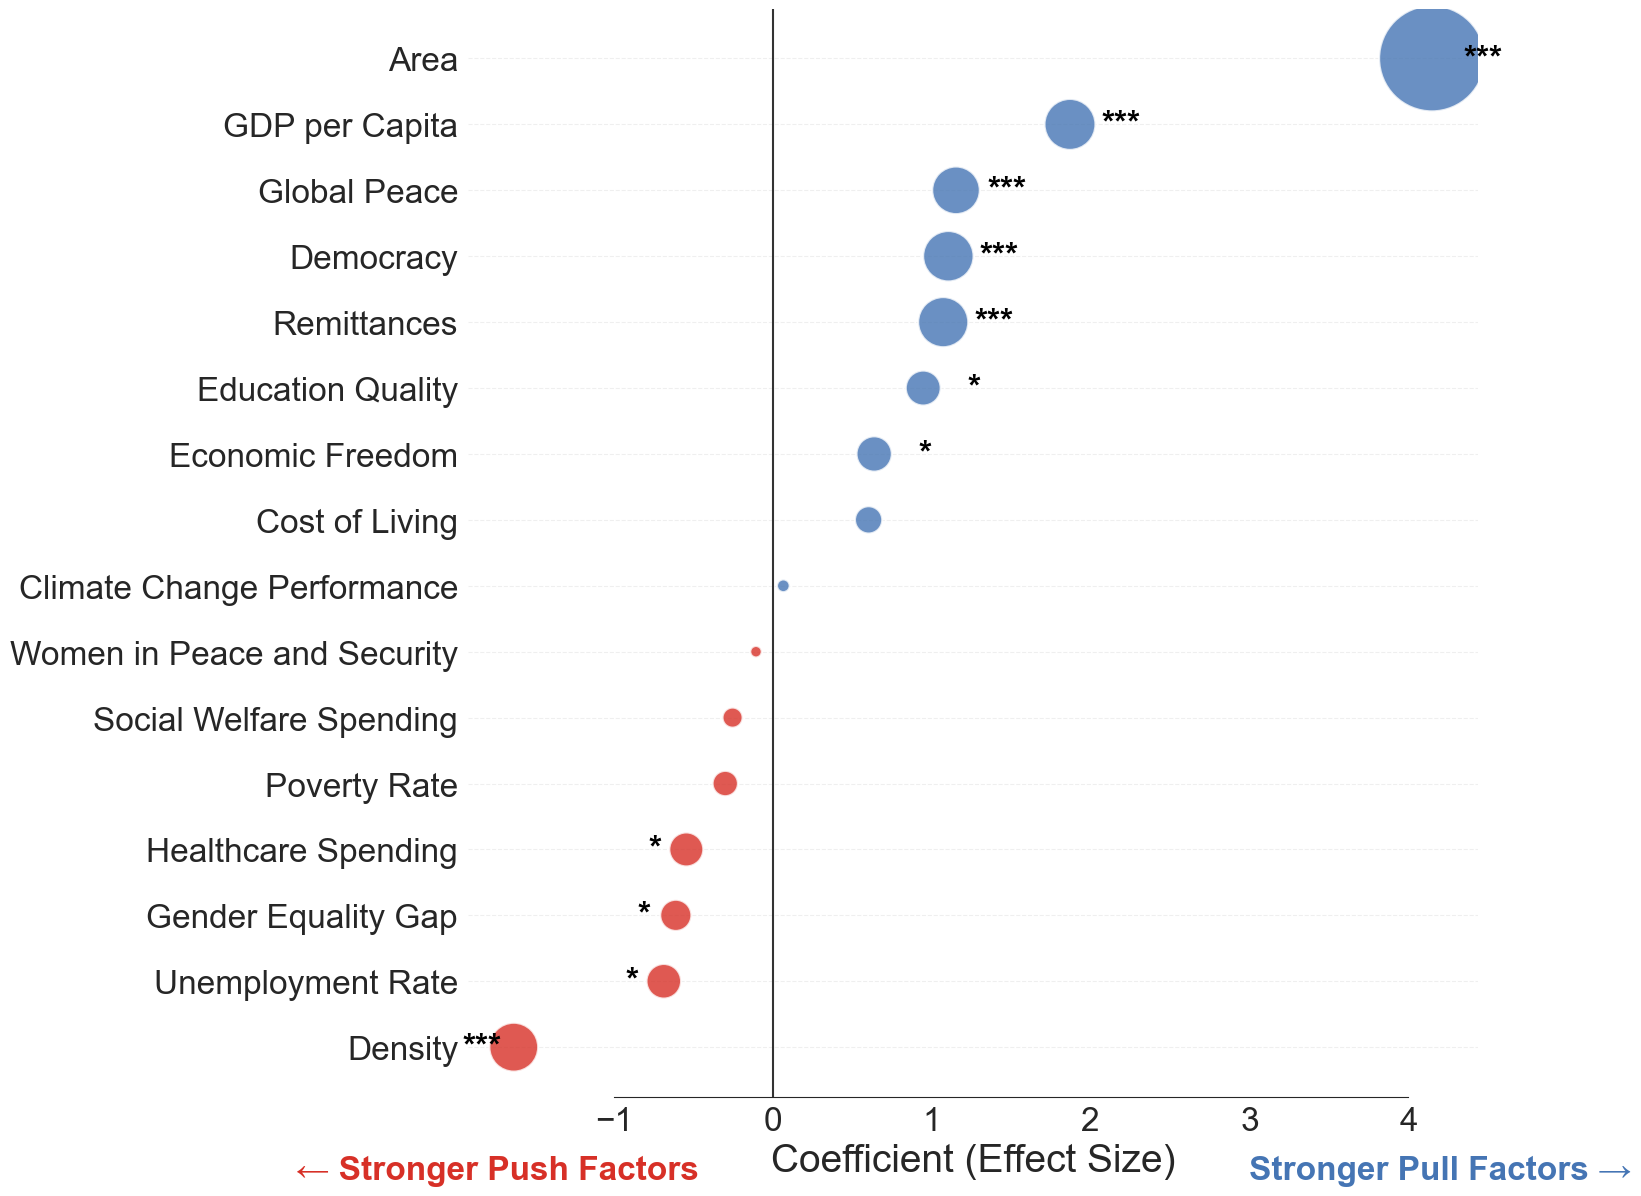

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Data Entry
data = {
    'Factor': [
        'Density', 'Area', 'GDP per Capita', 'Democracy', 'Gender Equality Gap', 
        'Social Welfare Spending', 'Poverty Rate', 'Cost of Living', 'Economic Freedom', 'Remittances', 
        'Unemployment Rate', 'Education Quality', 'Healthcare Spending', 
        'Climate Change Performance', 'Women in Peace and Security', 'Global Peace'
    ],
    'Coef': [
        -1.6285, 4.1479, 1.8706, 1.1055, -0.6090, -0.2520, -0.2979, 0.6038, 
        0.6388, 1.0732, -0.6846, 0.9474, -0.5430, 0.0674, -0.1046, 1.1536
    ],
    'T_Stat': [
        -4.934, 23.153, 5.373, 5.261, -2.008, -0.832, -1.324, 1.539, 
        2.577, 5.198, -2.477, 2.523, -2.390, 0.332, -0.272, 4.685
    ],
    'P_Value': [
        0.000, 0.000, 0.000, 0.000, 0.045, 0.406, 0.185, 0.124, 
        0.010, 0.000, 0.013, 0.012, 0.017, 0.740, 0.785, 0.000
    ]
}

df = pd.DataFrame(data).sort_values('Coef')

# 2. Design Logic
df['Sig_Level'] = np.where(df['P_Value'] < 0.001, '***', 
                  np.where(df['P_Value'] < 0.01, '**', 
                  np.where(df['P_Value'] < 0.05, '*', '')))

# 3. Plotting
plt.figure(figsize=(16, 12))
sns.set_style("white")

# Color mapping: Deep Red for Negative, Deep Blue for Positive
colors = ['#d73027' if x < 0 else '#4575b4' for x in df['Coef']]

# Scatter plot where size is the absolute T-statistic (Strength of Evidence)
# Multiply by 100 for visible scaling
scatter = plt.scatter(df['Coef'], df['Factor'], s=np.abs(df['T_Stat'])*250, 
                      c=colors, alpha=0.8, edgecolor='white', linewidth=1.5)

# Add Significance Stars next to labels
for i, row in df.iterrows():
    star_color = 'black' if row['Sig_Level'] != 'ns' else '#999999'
    plt.text(row['Coef'] + (0.32 if row['Coef'] > 0 else -0.2), 
             row['Factor'], row['Sig_Level'], 
             va='center', ha='center', fontsize=24, fontweight='bold', color=star_color)

# 4. Customizing the Central Axis
plt.axvline(0, color='#333333', lw=1.5, ls='-')
plt.grid(axis='y', linestyle='--', alpha=0.3)

# 5. Adding Annotations for interpretation
plt.text(3, -2, "Stronger Pull Factors →", fontsize=24, color='#4575b4', fontweight='bold')
plt.text(-3, -2, "← Stronger Push Factors", fontsize=24, color='#d73027', fontweight='bold')

#plt.title(f"Drivers of Scholar Migration (LinkedIn Trajectories)\nPoint Size = T-Statistic (Statistical Strength)", 
#          fontsize=18, fontweight='bold', pad=30)
plt.xlabel("Coefficient (Effect Size)", fontsize=28)
plt.yticks(fontsize=24)
plt.xticks(fontsize=24)
plt.ylabel("")

# Final Polish
sns.despine(trim=True, left=True)
plt.tight_layout()
plt.savefig("Migration_factors.pdf")
plt.show()

In [263]:

import numpy as np

df_scaled["log_male_migrant"] = np.log1p(df_scaled["male_migrant"])




# Renaming the columns to match the regression formula
df_scaled.rename(columns={
    'GDP per Capita': 'GDP_per_Capita',
    'Cost of Living': 'Cost_of_Living',
    'Economic Freedom': 'Economic_Freedom',
    'Unemployment Rate': 'Unemployment_Rate',
    'Labor Force Participation Rate': 'Labor_Force_Participation_Rate',
    'Education Spending per Student': 'Education_Spending_per_Student',
    'Literacy Rate': 'Literacy_Rate',
    'Life Expectancy': 'Life_Expectancy',
    'Healthcare Expenditure': 'Healthcare_Expenditure',
    'Political Stability and Governance': 'Political_Stability_and_Governance',
    'Global Peace': 'Global_Peace',
    'Global Terrorism': 'Global_Terrorism',
    'Climate Change Perfromance': 'Climate_Change_Performance',
    'Global Gender Gap': 'Global_Gender_Gap',
    'Women Peace and Security': 'Women_Peace_and_Security',
    'Social Progress': 'Social_Progress',
    'Asylum Grant': 'Asylum_Grant',
    'region': 'region',
    'Literacy Rate':'Literacy_Rate',
    'SocialWelfareSpending_SocialAssistanceProgramsPctofGDP_pct_MultiYear':'Social_Welfare_Spending',
}, inplace=True)



# List of numeric columns
numeric_cols = ['GDP_per_Capita', 'Cost_of_Living', 'Economic_Freedom', 'Unemployment_Rate', 
                'Labor_Force_Participation_Rate', 'Education_Spending_per_Student', 'Literacy_Rate', 
                'Life_Expectancy', 'Healthcare_Expenditure', 'Political_Stability_and_Governance', 
                'Global_Peace', 'Global_Terrorism', 'Climate_Change_Performance', 'Global_Gender_Gap', 
                'Women_Peace_and_Security', 'Social_Progress', 'Asylum_Grant']

# Drop rows with NaN values in the renamed numeric columns
df_scaled = df_scaled.dropna(subset=numeric_cols)


# Now, you can proceed with the regression analysis using the updated column names
import statsmodels.formula.api as smf

# Define the formula
formula = "log_male_migrant ~density+area+GDP_per_Capita+ Democracy+Global_Gender_Gap +Social_Welfare_Spending+ Poverty + Cost_of_Living + Economic_Freedom + Remittances + Unemployment_Rate + Education + Life_Expectancy + Healthcare_Expenditure + Climate_Change_Performance  + Women_Peace_and_Security  +Global_Peace+ Unemployment_Rate-1"

# Fit the OLS model
model = smf.ols(formula=formula, data=df_scaled)
results1 = model.fit()

# Print the regression summary
results1.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:       log_male_migrant   R-squared (uncentered):                   0.252
Model:                            OLS   Adj. R-squared (uncentered):              0.251
Method:                 Least Squares   F-statistic:                              205.9
Date:                Wed, 04 Feb 2026   Prob (F-statistic):                        0.00
Time:                        09:59:09   Log-Likelihood:                         -25011.
No. Observations:               10403   AIC:                                  5.006e+04
Df Residuals:                   10386   BIC:                                  5.018e+04
Df Model:                          17                                                  
Covariance Type:            nonrobust                                                  
==============================================================================================
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
density                       -0.9720      0.278     -3.493      0.000      -1.518      -0.426
area                           3.4478      0.151     22.826      0.000       3.152       3.744
GDP_per_Capita                 1.4233      0.294      4.849      0.000       0.848       1.999
Democracy                      0.8340      0.177      4.708      0.000       0.487       1.181
Global_Gender_Gap             -0.7275      0.256     -2.845      0.004      -1.229      -0.226
Social_Welfare_Spending       -0.1658      0.256     -0.649      0.516      -0.667       0.335
Poverty                       -0.1474      0.190     -0.777      0.437      -0.519       0.224
Cost_of_Living                 0.6211      0.331      1.877      0.060      -0.027       1.270
Economic_Freedom               0.3974      0.209      1.901      0.057      -0.012       0.807
Remittances                    0.9323      0.174      5.356      0.000       0.591       1.274
Unemployment_Rate             -0.6749      0.233     -2.896      0.004      -1.132      -0.218
Education                      0.7847      0.317      2.479      0.013       0.164       1.405
Life_Expectancy               -0.0761      0.259     -0.294      0.769      -0.583       0.431
Healthcare_Expenditure        -0.1834      0.192     -0.957      0.338      -0.559       0.192
Climate_Change_Performance    -0.0102      0.171     -0.060      0.952      -0.346       0.326
Women_Peace_and_Security      -0.6315      0.324     -1.951      0.051      -1.266       0.003
Global_Peace                   0.6911      0.208      3.329      0.001       0.284       1.098
==============================================================================
Omnibus:                     2948.232   Durbin-Watson:                   1.311
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             6396.887
Skew:                           1.682   Prob(JB):                         0.00
Kurtosis:                       4.856   Cond. No.                         30.0
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [264]:

import numpy as np

df_scaled["log_female_migrant"] = np.log1p(df_scaled["female_migrant"])




# Renaming the columns to match the regression formula
df_scaled.rename(columns={
    'GDP per Capita': 'GDP_per_Capita',
    'Cost of Living': 'Cost_of_Living',
    'Economic Freedom': 'Economic_Freedom',
    'Unemployment Rate': 'Unemployment_Rate',
    'Labor Force Participation Rate': 'Labor_Force_Participation_Rate',
    'Education Spending per Student': 'Education_Spending_per_Student',
    'Literacy Rate': 'Literacy_Rate',
    'Life Expectancy': 'Life_Expectancy',
    'Healthcare Expenditure': 'Healthcare_Expenditure',
    'Political Stability and Governance': 'Political_Stability_and_Governance',
    'Global Peace': 'Global_Peace',
    'Global Terrorism': 'Global_Terrorism',
    'Climate Change Perfromance': 'Climate_Change_Performance',
    'Global Gender Gap': 'Global_Gender_Gap',
    'Women Peace and Security': 'Women_Peace_and_Security',
    'Social Progress': 'Social_Progress',
    'Asylum Grant': 'Asylum_Grant',
    'region': 'region',
    'Literacy Rate':'Literacy_Rate',
    'SocialWelfareSpending_SocialAssistanceProgramsPctofGDP_pct_MultiYear':'Social_Welfare_Spending',
}, inplace=True)



# List of numeric columns
numeric_cols = ['GDP_per_Capita', 'Cost_of_Living', 'Economic_Freedom', 'Unemployment_Rate', 
                'Labor_Force_Participation_Rate', 'Education_Spending_per_Student', 'Literacy_Rate', 
                'Life_Expectancy', 'Healthcare_Expenditure', 'Political_Stability_and_Governance', 
                'Global_Peace', 'Global_Terrorism', 'Climate_Change_Performance', 'Global_Gender_Gap', 
                'Women_Peace_and_Security', 'Social_Progress', 'Asylum_Grant']

# Drop rows with NaN values in the renamed numeric columns
df_scaled = df_scaled.dropna(subset=numeric_cols)


# Now, you can proceed with the regression analysis using the updated column names
import statsmodels.formula.api as smf

# Define the formula
# Define the formula
formula = "log_female_migrant ~density+area+GDP_per_Capita+ Democracy+Global_Gender_Gap +Social_Welfare_Spending+ Poverty + Cost_of_Living + Economic_Freedom + Remittances + Unemployment_Rate + Education + Life_Expectancy + Healthcare_Expenditure + Climate_Change_Performance  + Women_Peace_and_Security  +Global_Peace+ Unemployment_Rate-1"

# Fit the OLS model
model = smf.ols(formula=formula, data=df_scaled)
results2 = model.fit()

# Print the regression summary
results2.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:     log_female_migrant   R-squared (uncentered):                   0.240
Model:                            OLS   Adj. R-squared (uncentered):              0.239
Method:                 Least Squares   F-statistic:                              193.2
Date:                Wed, 04 Feb 2026   Prob (F-statistic):                        0.00
Time:                        09:59:26   Log-Likelihood:                         -24487.
No. Observations:               10403   AIC:                                  4.901e+04
Df Residuals:                   10386   BIC:                                  4.913e+04
Df Model:                          17                                                  
Covariance Type:            nonrobust                                                  
==============================================================================================
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
density                       -0.6586      0.265     -2.488      0.013      -1.177      -0.140
area                           3.2007      0.144     22.284      0.000       2.919       3.482
GDP_per_Capita                 0.8960      0.279      3.210      0.001       0.349       1.443
Democracy                      0.7983      0.168      4.738      0.000       0.468       1.128
Global_Gender_Gap             -0.6439      0.243     -2.648      0.008      -1.121      -0.167
Social_Welfare_Spending       -0.0262      0.243     -0.108      0.914      -0.502       0.450
Poverty                       -0.4357      0.180     -2.415      0.016      -0.789      -0.082
Cost_of_Living                 1.0491      0.315      3.334      0.001       0.432       1.666
Economic_Freedom               0.1922      0.199      0.967      0.334      -0.197       0.582
Remittances                    0.8132      0.166      4.913      0.000       0.489       1.138
Unemployment_Rate             -0.6777      0.222     -3.058      0.002      -1.112      -0.243
Education                      0.8954      0.301      2.974      0.003       0.305       1.486
Life_Expectancy               -0.2246      0.246     -0.913      0.361      -0.707       0.258
Healthcare_Expenditure         0.3216      0.182      1.765      0.078      -0.035       0.679
Climate_Change_Performance    -0.0713      0.163     -0.438      0.661      -0.391       0.248
Women_Peace_and_Security      -0.4809      0.308     -1.562      0.118      -1.084       0.122
Global_Peace                   0.3579      0.197      1.813      0.070      -0.029       0.745
==============================================================================
Omnibus:                     3360.296   Durbin-Watson:                   1.322
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             8352.864
Skew:                           1.823   Prob(JB):                         0.00
Kurtosis:                       5.443   Cond. No.                         30.0
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

                      variable  male_migrant_coef  female_migrant_coef  \
0                      Density            -0.9720              -0.6586   
1                         Area             3.4478               3.2007   
2               GDP per Capita             1.4233               0.8960   
3                    Democracy             0.8340               0.7983   
4            Global Gender Gap            -0.7275              -0.6439   
5      Social Welfare Spending            -0.1658              -0.0262   
6                      Poverty            -0.1474              -0.4357   
7               Cost of Living             0.6211               1.0491   
8             Economic Freedom             0.3974               0.1922   
9                  Remittances             0.9323               0.8132   
10           Unemployment Rate            -0.6749              -0.6777   
11                   Education             0.7847               0.8954   
12             Life Expectancy        

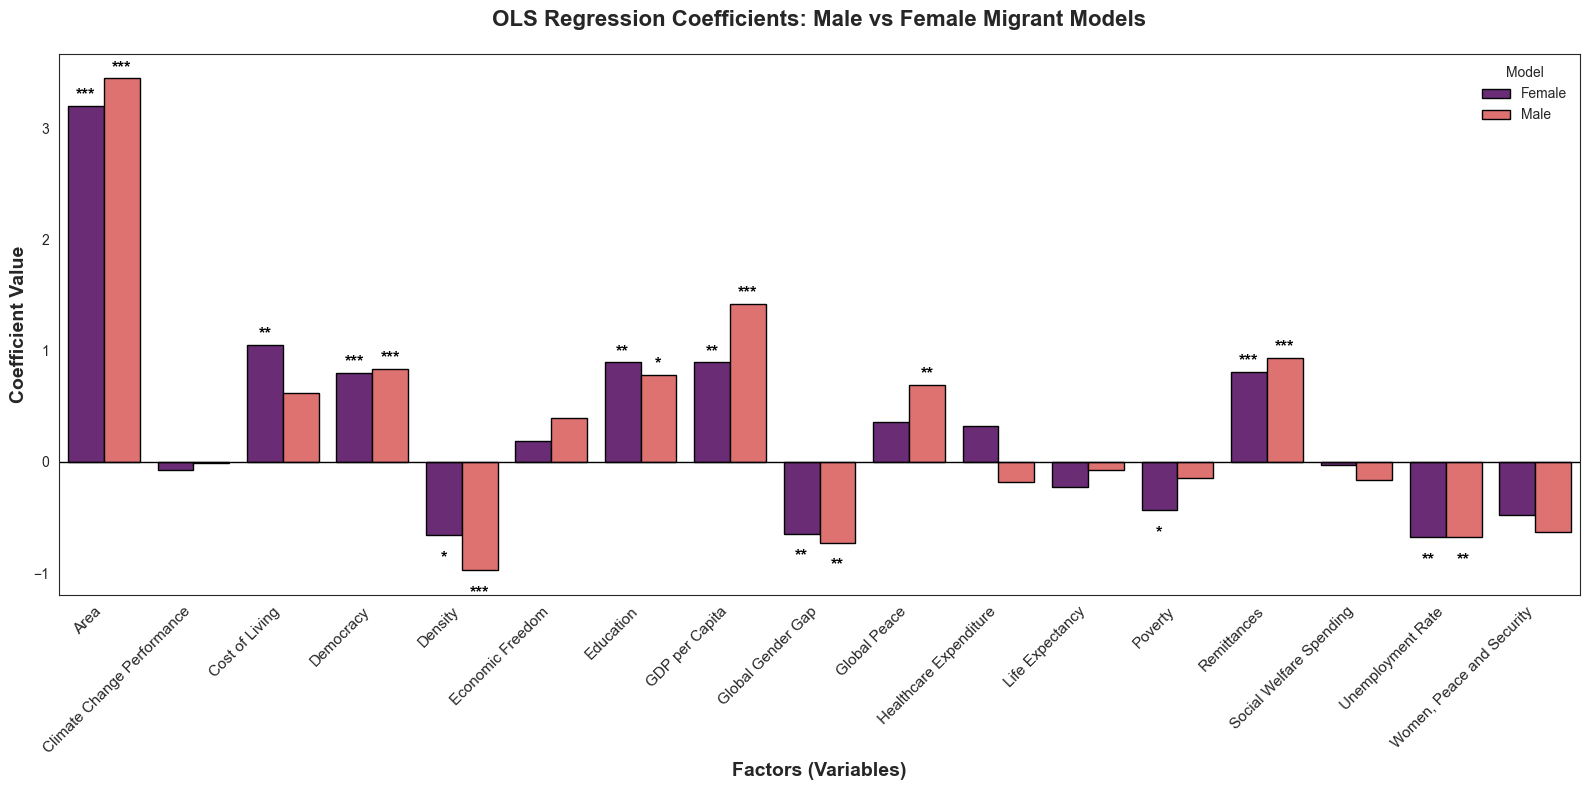

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# Data Entry (from OLS table: log_male_migrant)
data_migrants = {
    'variable': [
        'Density', 'Area', 'GDP per Capita', 'Democracy', 'Global Gender Gap',
        'Social Welfare Spending', 'Poverty', 'Cost of Living', 'Economic Freedom',
        'Remittances', 'Unemployment Rate', 'Education', 'Life Expectancy',
        'Healthcare Expenditure', 'Climate Change Performance',
        'Women, Peace and Security', 'Global Peace'
    ],
    'male_migrant_coef': [
        -0.9720, 3.4478, 1.4233, 0.8340, -0.7275,
        -0.1658, -0.1474, 0.6211, 0.3974,
        0.9323, -0.6749, 0.7847, -0.0761,
        -0.1834, -0.0102,
        -0.6315, 0.6911
    ],
    'male_migrant_p_value': [
        0.000, 0.000, 0.000, 0.000, 0.004,
        0.516, 0.437, 0.060, 0.057,
        0.000, 0.004, 0.013, 0.769,
        0.338, 0.952,
        0.051, 0.001
    ],
}




# Data Entry (same feature names + SAME ORDER as your male dict)

data_migrants = {
    'variable': [
        'Density', 'Area', 'GDP per Capita', 'Democracy', 'Global Gender Gap',
        'Social Welfare Spending', 'Poverty', 'Cost of Living', 'Economic Freedom',
        'Remittances', 'Unemployment Rate', 'Education', 'Life Expectancy',
        'Healthcare Expenditure', 'Climate Change Performance',
        'Women, Peace and Security', 'Global Peace'
    ],
    'male_migrant_coef': [
        -0.9720, 3.4478, 1.4233, 0.8340, -0.7275,
        -0.1658, -0.1474, 0.6211, 0.3974,
        0.9323, -0.6749, 0.7847, -0.0761,
        -0.1834, -0.0102,
        -0.6315, 0.6911
    ],
    'female_migrant_coef': [
        -0.6586, 3.2007, 0.8960, 0.7983, -0.6439,
        -0.0262, -0.4357, 1.0491, 0.1922,
        0.8132, -0.6777, 0.8954, -0.2246,
        0.3216, -0.0713,
        -0.4809, 0.3579
    ],
    'male_migrant_p_value': [
        0.000, 0.000, 0.000, 0.000, 0.004,
        0.516, 0.437, 0.060, 0.057,
        0.000, 0.004, 0.013, 0.769,
        0.338, 0.952,
        0.051, 0.001
    ],
    'female_migrant_p_value': [
        0.013, 0.000, 0.001, 0.000, 0.008,
        0.914, 0.016, 0.001, 0.334,
        0.000, 0.002, 0.003, 0.361,
        0.078, 0.661,
        0.118, 0.070
    ],
}



df = pd.DataFrame(data_migrants)
print(df)
# 2. Define significance stars
def add_stars(p_value):
    if p_value < 0.001: return "***"
    elif p_value < 0.01: return "**"
    elif p_value < 0.05: return "*"
    else: return ""

df['male_migrant_significance'] = df['male_migrant_p_value'].apply(add_stars)
df['female_migrant_significance'] = df['female_migrant_p_value'].apply(add_stars)

# 3. Melt and SORT to match Seaborn's bar order
df_melted = df.melt(id_vars=['variable', 'male_migrant_significance', 'female_migrant_significance'],
                    value_vars=['male_migrant_coef', 'female_migrant_coef'],
                    var_name='Model', value_name='Coefficient')

df_melted['Model'] = df_melted['Model'].map({'male_migrant_coef': 'Male', 'female_migrant_coef': 'Female'})

# CRITICAL STEP: Sort by Model (hue) then Variable (x) to align with ax.patches
df_melted = df_melted.sort_values(['Model', 'variable'])

df_melted['Significance'] = df_melted.apply(
    lambda row: row['male_migrant_significance'] if row['Model'] == 'Male' else row['female_migrant_significance'],
    axis=1
)

# 4. Plotting (Factors on X, Coef on Y)
plt.figure(figsize=(16, 8))
ax = sns.barplot(x='variable', y='Coefficient', data=df_melted, hue='Model', 
                 palette='magma', edgecolor='black')

# 5. Add significance stars (Using direct mapping)
# Zipping patches with the sorted dataframe prevents IndexError
for p, (_, row) in zip(ax.patches, df_melted.iterrows()):
    height = p.get_height()
    significance = row['Significance']
    
    if significance:
        # Position star based on bar direction (positive/negative)
        y_pos = height + 0.1 if height >= 0 else height - 0.2
        ax.text(
            p.get_x() + p.get_width() / 2., 
            y_pos, 
            significance, 
            ha='center', va='center', 
            fontsize=12, fontweight='bold', color='black'
        )

# 6. Aesthetics
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.xlabel('Factors (Variables)', fontsize=14, fontweight='bold')
plt.ylabel('Coefficient Value', fontsize=14, fontweight='bold')
plt.title('OLS Regression Coefficients: Male vs Female Migrant Models', fontsize=16, fontweight='bold', pad=20)
plt.axhline(0, color='black', linewidth=1) # Zero baseline

plt.legend(title='Model', loc='upper right', frameon=False)
plt.tight_layout()
plt.show()

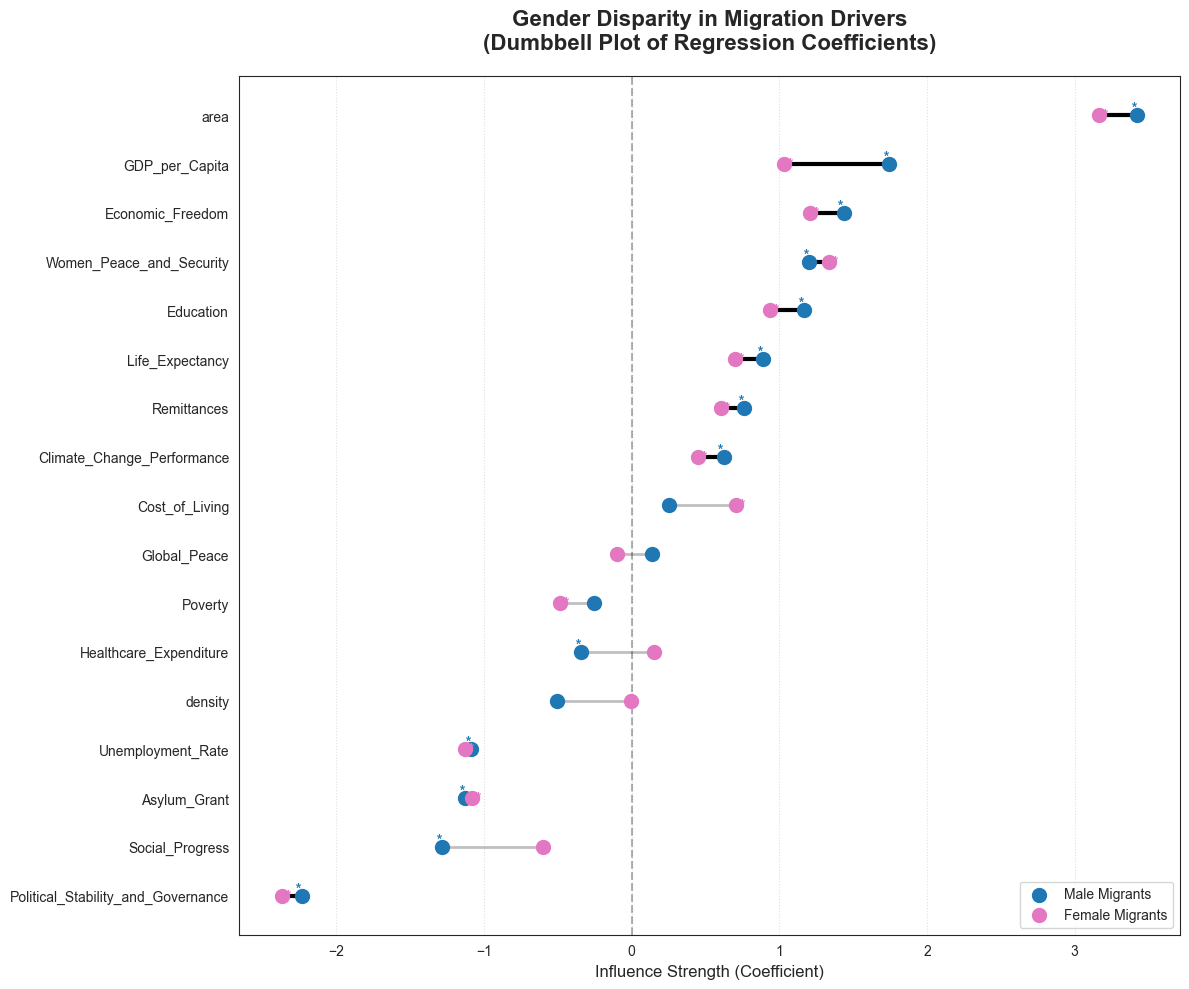

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Data Setup
data = {
    'variable': ['density', 'area', 'GDP_per_Capita', 'Social_Progress', 'Poverty', 'Cost_of_Living', 
                 'Economic_Freedom', 'Remittances', 'Unemployment_Rate', 'Education', 'Life_Expectancy', 
                 'Healthcare_Expenditure', 'Political_Stability_and_Governance', 'Climate_Change_Performance', 
                 'Women_Peace_and_Security', 'Asylum_Grant', 'Global_Peace'],
    'male_coef': [-0.5049, 3.4234, 1.7420, -1.2804, -0.2518, 0.2525, 1.4350, 0.7629, -1.0840, 1.1692, 0.8887, -0.3421, -2.2329, 0.6237, 1.2020, -1.1266, 0.1395],
    'female_coef': [-0.0055, 3.1659, 1.0292, -0.5970, -0.4843, 0.7051, 1.2098, 0.6070, -1.1300, 0.9370, 0.6987, 0.1514, -2.3681, 0.4471, 1.3371, -1.0776, -0.1006],
    'male_p': [0.093, 0.000, 0.000, 0.002, 0.189, 0.428, 0.000, 0.000, 0.000, 0.001, 0.002, 0.044, 0.000, 0.000, 0.001, 0.000, 0.558],
    'female_p': [0.984, 0.000, 0.000, 0.134, 0.008, 0.020, 0.000, 0.000, 0.000, 0.007, 0.010, 0.348, 0.000, 0.007, 0.000, 0.000, 0.657],
}

df = pd.DataFrame(data).sort_values('male_coef')

# 2. Plotting
plt.figure(figsize=(12, 10))
plt.hlines(y=df['variable'], xmin=df['male_coef'], xmax=df['female_coef'], color='grey', alpha=0.5, linewidth=2)

# Plot Male points
plt.scatter(df['male_coef'], df['variable'], color='#1f77b4', label='Male Migrants', s=100, zorder=3)
# Plot Female points
plt.scatter(df['female_coef'], df['variable'], color='#e377c2', label='Female Migrants', s=100, zorder=3)

# 3. Add Significance Highlighting
for i, row in df.iterrows():
    # If both are significant, highlight the connection
    if row['male_p'] < 0.05 and row['female_p'] < 0.05:
        plt.hlines(y=row['variable'], xmin=row['male_coef'], xmax=row['female_coef'], color='black', linewidth=3, zorder=2)
    
    # Add stars for female significance (pink) and male significance (blue)
    if row['female_p'] < 0.05:
        plt.text(row['female_coef'], row['variable'], ' *', color='#e377c2', weight='bold', va='center')
    if row['male_p'] < 0.05:
        plt.text(row['male_coef'], row['variable'], ' *', color='#1f77b4', weight='bold', va='bottom', ha='right')

# 4. Aesthetics
plt.axvline(0, color='black', linestyle='--', alpha=0.3)
plt.title('Gender Disparity in Migration Drivers\n(Dumbbell Plot of Regression Coefficients)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Influence Strength (Coefficient)', fontsize=12)
plt.legend(frameon=True, loc='lower right')
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()

plt.show()

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Data Entry (same feature names + SAME ORDER as your male dict)

data_migrants = {
    'variable': [
        'Density', 'Area', 'GDP per Capita', 'Democracy', 'Global Gender Gap',
        'Social Welfare Spending', 'Poverty', 'Cost of Living', 'Economic Freedom',
        'Remittances', 'Unemployment Rate', 'Education', 'Life Expectancy',
        'Healthcare Expenditure', 'Climate Change Performance',
        'Women, Peace and Security', 'Global Peace'
    ],
    'male_migrant_coef': [
        -0.9720, 3.4478, 1.4233, 0.8340, -0.7275,
        -0.1658, -0.1474, 0.6211, 0.3974,
        0.9323, -0.6749, 0.7847, -0.0761,
        -0.1834, -0.0102,
        -0.6315, 0.6911
    ],
    'female_migrant_coef': [
        -0.6586, 3.2007, 0.8960, 0.7983, -0.6439,
        -0.0262, -0.4357, 1.0491, 0.1922,
        0.8132, -0.6777, 0.8954, -0.2246,
        0.3216, -0.0713,
        -0.4809, 0.3579
    ],
    'male_migrant_p_value': [
        0.000, 0.000, 0.000, 0.000, 0.004,
        0.516, 0.437, 0.060, 0.057,
        0.000, 0.004, 0.013, 0.769,
        0.338, 0.952,
        0.051, 0.001
    ],
    'female_migrant_p_value': [
        0.013, 0.000, 0.001, 0.000, 0.008,
        0.914, 0.016, 0.001, 0.334,
        0.000, 0.002, 0.003, 0.361,
        0.078, 0.661,
        0.118, 0.070
    ],
}


# Convert to DataFrame
import pandas as pd
df = pd.DataFrame(data_migrants)


                      variable  male_migrant_coef  female_migrant_coef  \
0                      Density            -0.9720              -0.6586   
1                         Area             3.4478               3.2007   
2               GDP per Capita             1.4233               0.8960   
3                    Democracy             0.8340               0.7983   
4            Global Gender Gap            -0.7275              -0.6439   
5      Social Welfare Spending            -0.1658              -0.0262   
6                      Poverty            -0.1474              -0.4357   
7               Cost of Living             0.6211               1.0491   
8             Economic Freedom             0.3974               0.1922   
9                  Remittances             0.9323               0.8132   
10           Unemployment Rate            -0.6749              -0.6777   
11                   Education             0.7847               0.8954   
12             Life Expectancy        

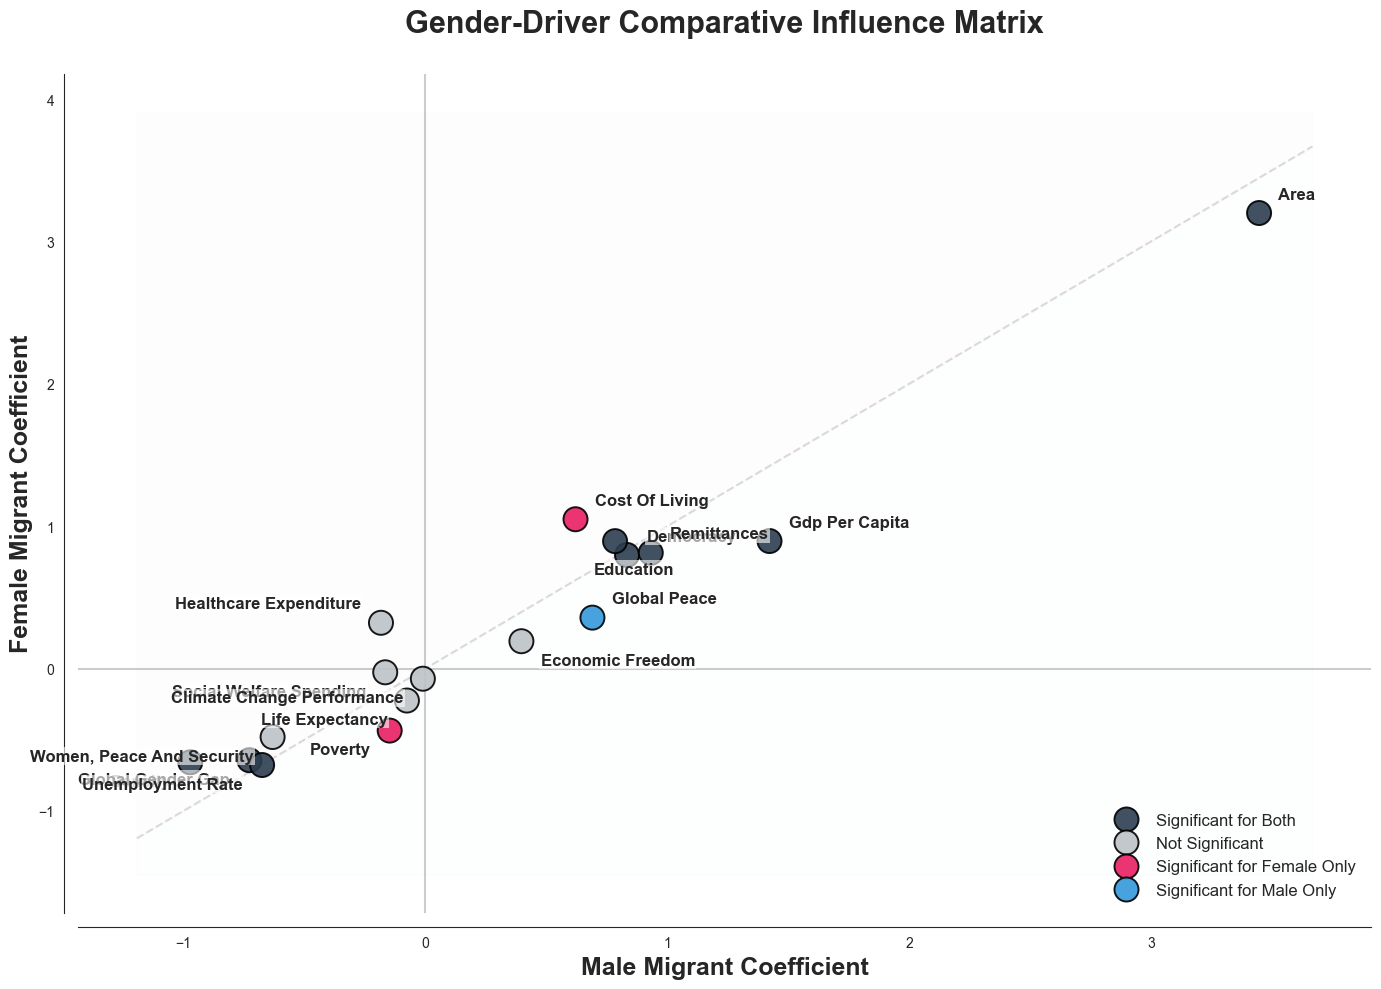

In [2]:


# Now you can print or process the dataframe as needed
print(df)
# Categorize significance
def get_sig_cat(row):
    m_sig = row['male_migrant_p_value'] < 0.05
    f_sig = row['female_migrant_p_value'] < 0.05
    if m_sig and f_sig: return 'Significant for Both'
    if m_sig: return 'Significant for Male Only'
    if f_sig: return 'Significant for Female Only'
    return 'Not Significant'

df['Significance'] = df.apply(get_sig_cat, axis=1)

# 2. Plotting
plt.figure(figsize=(14, 10))
sns.set_style("white")

# Custom palette for the categories
palette = {
    'Significant for Both': '#2c3e50',
    'Significant for Male Only': '#3498db',
    'Significant for Female Only': '#e91e63',
    'Not Significant': '#bdc3c7'
}

# Scatter plot
sns.scatterplot(data=df, x='male_migrant_coef', y='female_migrant_coef', hue='Significance', 
                palette=palette, s=300, edgecolor='black', zorder=5, alpha=0.9)

# Identity line (y=x)
lims = [min(plt.xlim()[0], plt.ylim()[0]), max(plt.xlim()[1], plt.ylim()[1])]
plt.plot(lims, lims, color='grey', alpha=0.3, linestyle='--', zorder=1)

# 3. Smart Labeling (Prevent overlap by adding automatic offset)
# Compute the mean for x and y to define the quadrants
x_mid = df['male_migrant_coef'].mean()
y_mid = df['female_migrant_coef'].mean()

for i, row in df.iterrows():
    # Position for text label (by default in the center of each point)
    ha = 'left' if row['male_migrant_coef'] > x_mid else 'right'
    va = 'bottom' if row['female_migrant_coef'] > y_mid else 'top'
    
    # Tiny offsets to prevent text sitting directly on the dot
    offset_x = 0.08 if ha == 'left' else -0.08
    offset_y = 0.08 if va == 'bottom' else -0.08
    
    # Adjust for specific points with tight clusters
    if 'Education' in row['variable']: 
        offset_y = -0.25; ha = 'center'
    if 'Social_Progress' in row['variable']: 
        offset_y = 0.25; ha = 'center'

    # Labeling with slight dynamic shifts for spacing
    plt.text(
        row['male_migrant_coef'] + offset_x, 
        row['female_migrant_coef'] + offset_y, 
        row['variable'].replace('_', ' ').title(), 
        fontsize=12, fontweight='bold',
        ha=ha, va=va, zorder=10,
        bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1) # Semi-transparent background
    )

# 4. Regional Shading
plt.fill_between(lims, lims, plt.ylim()[1], color='#fce4ec', alpha=0.07) # Women Zone
plt.fill_between(lims, plt.ylim()[0], lims, color='#e3f2fd', alpha=0.07) # Men Zone

# 5. Aesthetics
plt.xlabel('Male Migrant Coefficient', fontsize=18, fontweight='bold')
plt.ylabel('Female Migrant Coefficient', fontsize=18, fontweight='bold')
plt.title('Gender-Driver Comparative Influence Matrix', fontsize=22, fontweight='bold', pad=30)
plt.legend( loc='lower right', frameon=False, fontsize=12)

# Grid and origin lines
plt.axvline(0, color='black', alpha=0.2); plt.axhline(0, color='black', alpha=0.2)
sns.despine(offset=10)

plt.tight_layout()
plt.show()


Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


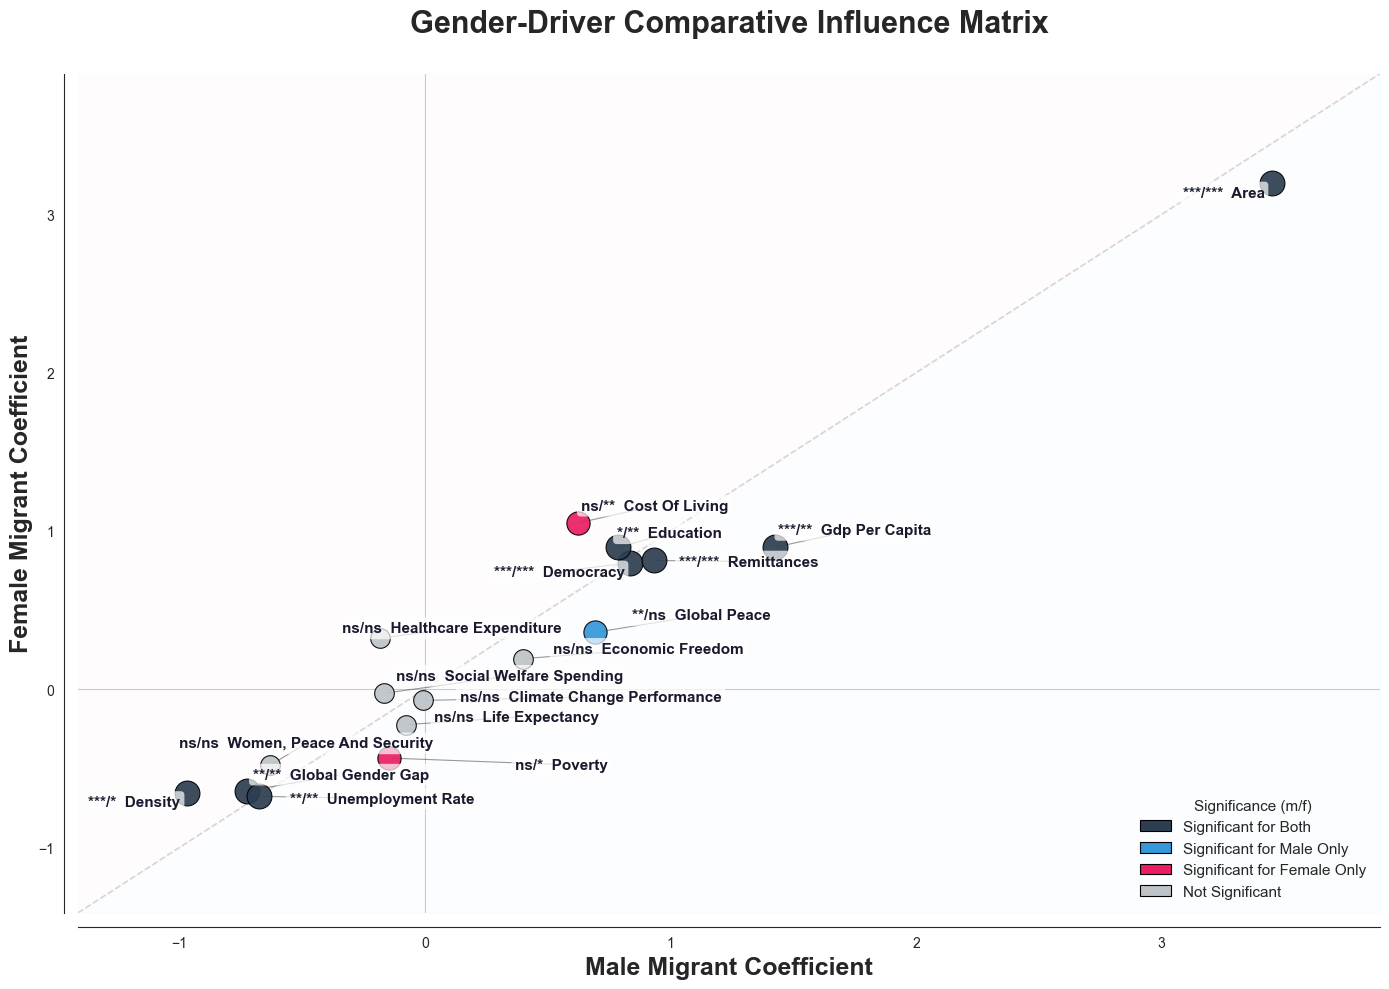

Plot saved → gender_driver_matrix.png


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from adjustText import adjust_text

# ── Assumes `df` already exists with these columns:
#   variable, male_migrant_coef, female_migrant_coef,
#   male_migrant_p_value, female_migrant_p_value
# ─────────────────────────────────────────────────

# 1. Significance category & p-value star label
def get_sig_cat(row):
    m_sig = row['male_migrant_p_value'] < 0.05
    f_sig = row['female_migrant_p_value'] < 0.05
    if m_sig and f_sig: return 'Significant for Both'
    if m_sig:           return 'Significant for Male Only'
    if f_sig:           return 'Significant for Female Only'
    return 'Not Significant'

def get_stars(p_val):
    """Return significance stars for a p-value."""
    if p_val < 0.001: return '***'
    if p_val < 0.01:  return '**'
    if p_val < 0.05:  return '*'
    return 'ns'

df['Significance'] = df.apply(get_sig_cat, axis=1)

# Build combined star label (male star / female star)
df['label'] = df.apply(
    lambda r: (
        f"{get_stars(r['male_migrant_p_value'])}/"
        f"{get_stars(r['female_migrant_p_value'])}  "
        + r['variable'].replace('_', ' ').title()
    ),
    axis=1
)

# ── 2. Colour palette (3 meaningful colours + grey) ──────────────────────────
palette = {
    'Significant for Both':        '#2c3e50',   # dark charcoal
    'Significant for Male Only':   '#3498db',   # blue
    'Significant for Female Only': '#e91e63',   # pink/red
    'Not Significant':             '#bdc3c7',   # light grey
}
dot_size_map = {
    'Significant for Both':        320,
    'Significant for Male Only':   280,
    'Significant for Female Only': 280,
    'Not Significant':             200,
}

# ── 3. Figure setup ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 10))
sns.set_style("white")

# Draw points group-by-group so colours are correct
for cat, grp in df.groupby('Significance'):
    ax.scatter(
        grp['male_migrant_coef'],
        grp['female_migrant_coef'],
        color=palette[cat],
        s=dot_size_map[cat],
        edgecolors='black',
        linewidths=0.8,
        zorder=5,
        alpha=0.92,
        label=cat
    )

# Identity line y = x
all_vals = pd.concat([df['male_migrant_coef'], df['female_migrant_coef']])
pad = (all_vals.max() - all_vals.min()) * 0.1
lim = [all_vals.min() - pad, all_vals.max() + pad]
ax.plot(lim, lim, color='grey', alpha=0.35, linestyle='--', zorder=1, linewidth=1.2)
ax.set_xlim(lim); ax.set_ylim(lim)

# Faint zone shading
ax.fill_between(lim, lim, lim[1], color='#fce4ec', alpha=0.08)   # female zone
ax.fill_between(lim, lim[0], lim,  color='#e3f2fd', alpha=0.08)  # male zone

# ── 4. Non-overlapping labels via adjustText ──────────────────────────────────
texts = []
for _, row in df.iterrows():
    t = ax.text(
        row['male_migrant_coef'],
        row['female_migrant_coef'],
        row['label'],
        fontsize=11,
        fontweight='bold',
        color='#1a1a2e',
        ha='center', va='center',
        zorder=10,
        bbox=dict(
            facecolor='white',
            alpha=0.70,
            edgecolor='none',
            boxstyle='round,pad=0.25'
        )
    )
    texts.append(t)

# adjust_text repels labels from each other AND from the dots
adjust_text(
    texts,
    x=df['male_migrant_coef'].values,
    y=df['female_migrant_coef'].values,
    ax=ax,
    expand_points=(1.6, 1.6),
    expand_text=(1.4, 1.4),
    force_points=(0.6, 0.6),
    force_text=(0.6, 0.6),
    arrowprops=dict(
        arrowstyle='-',
        color='#555555',
        lw=0.8,
        alpha=0.6
    )
)

# ── 5. Legend with 3 coloured dots + grey ─────────────────────────────────────
legend_order = [
    'Significant for Both',
    'Significant for Male Only',
    'Significant for Female Only',
    'Not Significant',
]
handles = [
    mpatches.Patch(facecolor=palette[cat], edgecolor='black', linewidth=0.8, label=cat)
    for cat in legend_order
]
ax.legend(
    handles=handles,
    loc='lower right',
    frameon=False,
    fontsize=11,
    title='Significance (m/f)',
    title_fontsize=11
)

# ── 6. Star key annotation ────────────────────────────────────────────────────
# star_note = "Label format: [male stars]/[female stars]  Variable\n*** p<0.001  ** p<0.01  * p<0.05  ns = not sig."
# ax.annotate(
#     star_note,
#     xy=(0.01, 0.01), xycoords='axes fraction',
#     fontsize=9, color='#555555',
#     bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=4)
# )

# ── 7. Axes & labels ──────────────────────────────────────────────────────────
ax.axvline(0, color='black', alpha=0.2, linewidth=0.8)
ax.axhline(0, color='black', alpha=0.2, linewidth=0.8)
ax.set_xlabel('Male Migrant Coefficient',   fontsize=18, fontweight='bold')
ax.set_ylabel('Female Migrant Coefficient', fontsize=18, fontweight='bold')
ax.set_title(
    'Gender-Driver Comparative Influence Matrix',
    fontsize=22, fontweight='bold', pad=30
)
sns.despine(offset=10)
plt.tight_layout()
plt.savefig('gender_driver_matrix.png', dpi=180, bbox_inches='tight')
plt.show()
print("Plot saved → gender_driver_matrix.png")

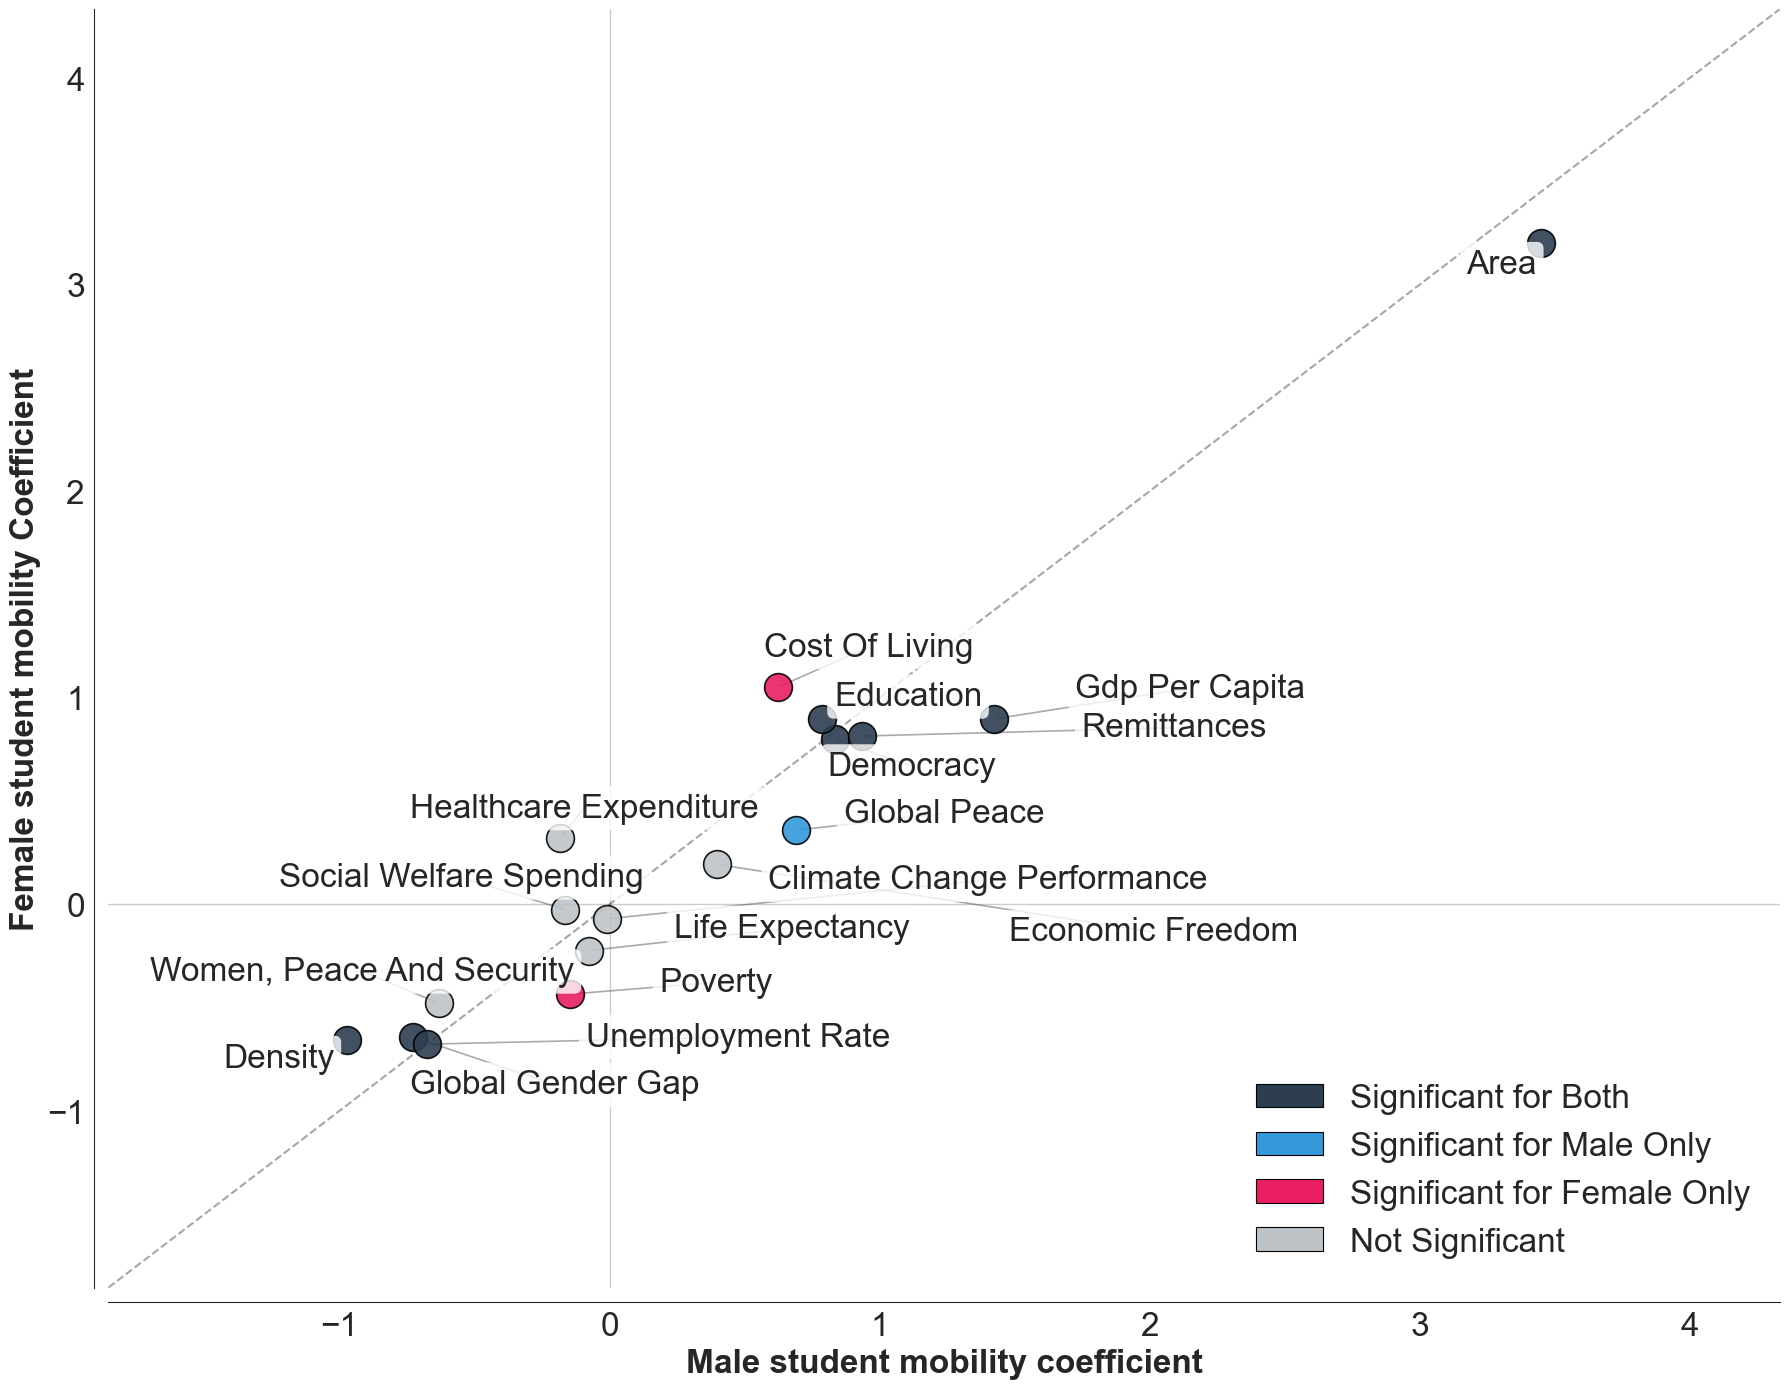

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from adjustText import adjust_text

# 1. Significance category classification
def get_sig_cat(row):
    m_sig = row['male_migrant_p_value'] < 0.05
    f_sig = row['female_migrant_p_value'] < 0.05
    if m_sig and f_sig: return 'Significant for Both'
    if m_sig:           return 'Significant for Male Only'
    if f_sig:           return 'Significant for Female Only'
    return 'Not Significant'

df['Significance'] = df.apply(get_sig_cat, axis=1)

# Clean labels: Title Case and remove underscores (No stars/prefix)
df['label'] = df['variable'].str.replace('_', ' ').str.title()

# 2. Visual Style & Palette
palette = {
    'Significant for Both':        '#2c3e50',   # Charcoal
    'Significant for Male Only':   '#3498db',   # Blue
    'Significant for Female Only': '#e91e63',   # Pink
    'Not Significant':             '#bdc3c7',   # Grey
}

# 3. Figure Construction
fig, ax = plt.subplots(figsize=(18, 14)) # Increased size for large labels
sns.set_style("white")

# Plot points
for cat, grp in df.groupby('Significance'):
    ax.scatter(
        grp['male_migrant_coef'],
        grp['female_migrant_coef'],
        color=palette[cat],
        s=400, # Larger dots for visibility
        edgecolors='black',
        linewidths=1.2,
        zorder=5,
        alpha=0.9,
        label=cat
    )

# Identity line (y=x)
all_vals = pd.concat([df['male_migrant_coef'], df['female_migrant_coef']])
pad = (all_vals.max() - all_vals.min()) * 0.2
lim = [all_vals.min() - pad, all_vals.max() + pad]
ax.plot(lim, lim, color='grey', alpha=0.7, linestyle='--', zorder=1)
ax.set_xlim(lim); ax.set_ylim(lim)

# 4. Large-Scale Non-Overlapping Labels
texts = []
for _, row in df.iterrows():
    t = ax.text(
        row['male_migrant_coef'],
        row['female_migrant_coef'],
        row['label'],
        fontsize=24,  # Requested 24pt font
        
       
        ha='center', va='center',
        zorder=10,
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.2')
    )
    texts.append(t)

# Optimized adjustment for large font sizes
adjust_text(
    texts,
    x=df['male_migrant_coef'].values,
    y=df['female_migrant_coef'].values,
    ax=ax,
    expand_points=(2.5, 2.5), # More space around dots
    expand_text=(1.8, 1.8),   # More space between labels
    force_points=(1.2, 1.2),  # Stronger repulsion from dots
    arrowprops=dict(arrowstyle='-', color='#555555', lw=1.2, alpha=0.5)
)




# ── 5. Legend with 3 coloured dots + grey ─────────────────────────────────────
legend_order = [
    'Significant for Both',
    'Significant for Male Only',
    'Significant for Female Only',
    'Not Significant',
]
handles = [
    mpatches.Patch(facecolor=palette[cat], edgecolor='black', linewidth=0.8, label=cat)
    for cat in legend_order
]
ax.legend(
    handles=handles,
    loc='lower right',
    frameon=False,
    fontsize=24,
    title_fontsize=11
)



# 5. Axes & Final Formatting
ax.axvline(0, color='black', alpha=0.2, linewidth=1)
ax.axhline(0, color='black', alpha=0.2, linewidth=1)
ax.set_xlabel('Male student mobility coefficient', fontsize=24, fontweight='bold')
ax.set_ylabel('Female student mobility Coefficient', fontsize=24, fontweight='bold')

ax.tick_params(axis='x', labelsize=24)
ax.tick_params(axis='y', labelsize=24)
sns.despine(offset=10)
plt.tight_layout()
plt.savefig('pnas_influence_matrix.pdf', dpi=300, bbox_inches='tight')
plt.show()

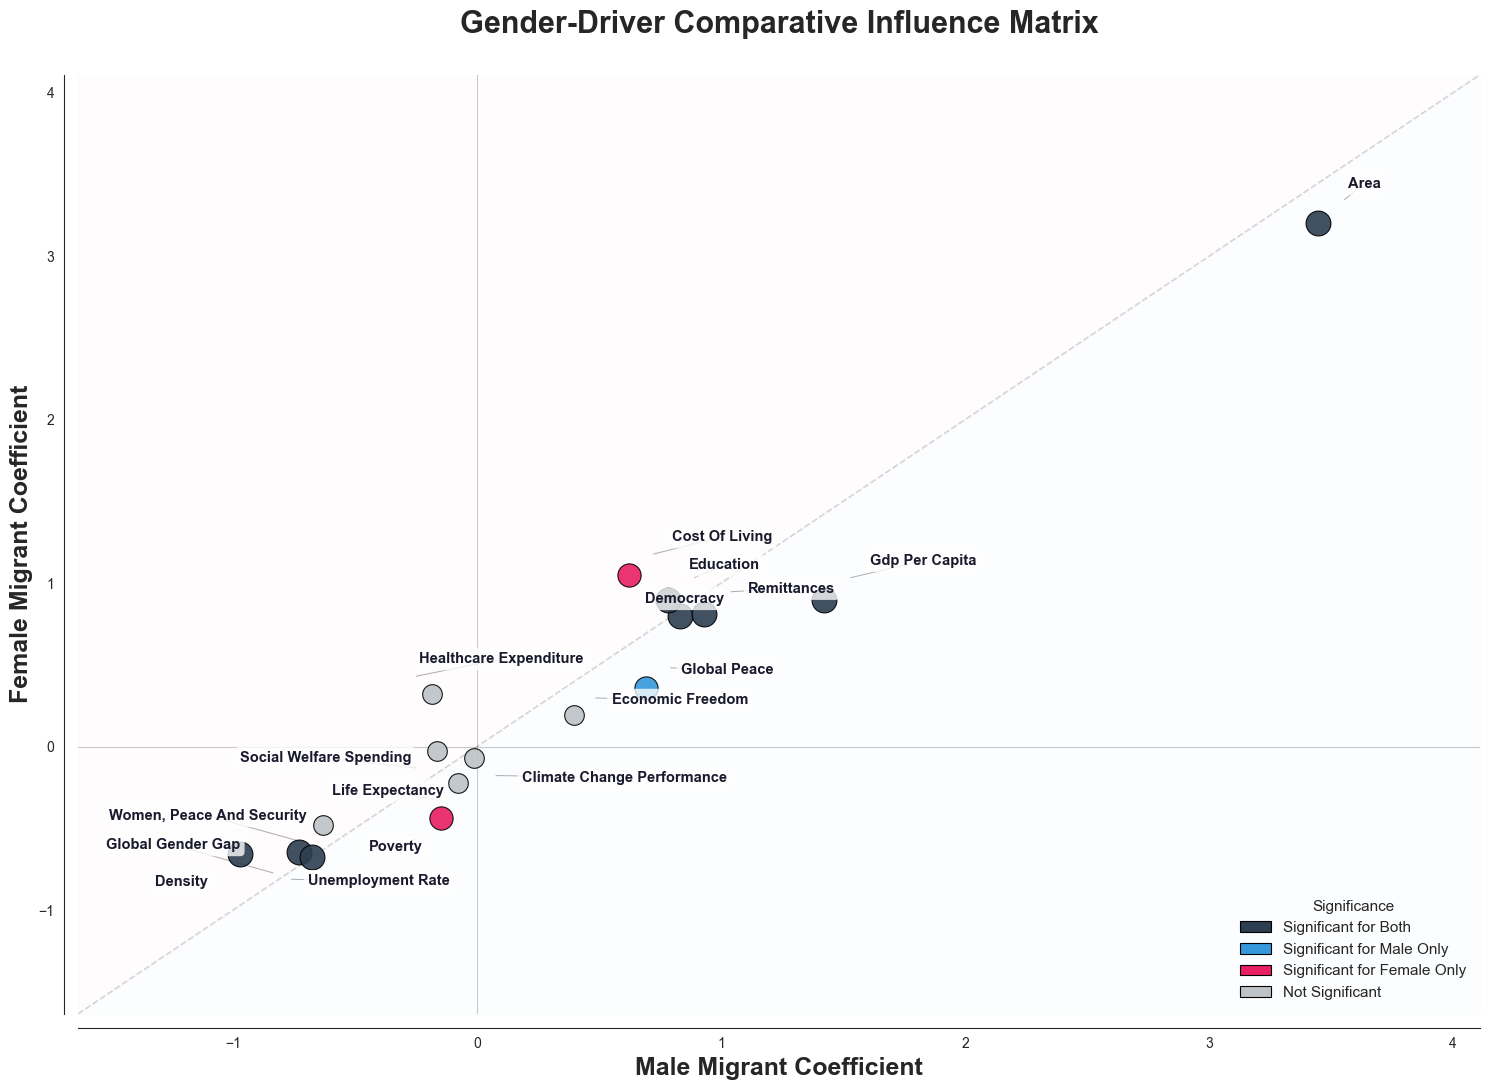

Plot saved → gender_driver_matrix.png


In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from adjustText import adjust_text
import numpy as np

# ── Assumes `df` already exists with these columns:
#   variable, male_migrant_coef, female_migrant_coef,
#   male_migrant_p_value, female_migrant_p_value
# ─────────────────────────────────────────────────

# 1. Significance category
def get_sig_cat(row):
    m_sig = row['male_migrant_p_value'] < 0.05
    f_sig = row['female_migrant_p_value'] < 0.05
    if m_sig and f_sig: return 'Significant for Both'
    if m_sig:           return 'Significant for Male Only'
    if f_sig:           return 'Significant for Female Only'
    return 'Not Significant'

df['Significance'] = df.apply(get_sig_cat, axis=1)

# Clean label — no stars
df['label'] = df['variable'].str.replace('_', ' ').str.title()

# ── 2. Colour palette ────────────────────────────────────────────────────────
palette = {
    'Significant for Both':        '#2c3e50',
    'Significant for Male Only':   '#3498db',
    'Significant for Female Only': '#e91e63',
    'Not Significant':             '#bdc3c7',
}
dot_size_map = {
    'Significant for Both':        320,
    'Significant for Male Only':   280,
    'Significant for Female Only': 280,
    'Not Significant':             200,
}

# ── 3. Figure setup ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 11))
sns.set_style("white")

# Draw points group-by-group
for cat, grp in df.groupby('Significance'):
    ax.scatter(
        grp['male_migrant_coef'],
        grp['female_migrant_coef'],
        color=palette[cat],
        s=dot_size_map[cat],
        edgecolors='black',
        linewidths=0.8,
        zorder=5,
        alpha=0.9,
        label=cat
    )

# Identity line y = x
all_vals = pd.concat([df['male_migrant_coef'], df['female_migrant_coef']])
pad = (all_vals.max() - all_vals.min()) * 0.15
lim = [all_vals.min() - pad, all_vals.max() + pad]
ax.plot(lim, lim, color='grey', alpha=0.35, linestyle='--', zorder=1, linewidth=1.2)
ax.set_xlim(lim)
ax.set_ylim(lim)

# Faint zone shading
ax.fill_between(lim, lim, lim[1], color='#fce4ec', alpha=0.08)
ax.fill_between(lim, lim[0], lim,  color='#e3f2fd', alpha=0.08)

# ── 4. Labels — pre-offset away from dot, then adjustText avoids everything ──
# Force the canvas to draw so we can use the axis transform accurately
fig.canvas.draw()

def dot_radius_data_units(s_pts2):
    """
    Convert a scatter marker size (pts²) to approximate data-unit radius.
    We do this by mapping a 1-pt shift through the display→data transform.
    """
    radius_pts = (s_pts2 ** 0.5) / 2.0
    # display coords of the axes origin and a point 1 pt to the right / up
    origin_disp = ax.transData.transform([0, 0])
    dx_disp = origin_disp + np.array([radius_pts, 0])
    dy_disp = origin_disp + np.array([0, radius_pts])
    dx_data = ax.transData.inverted().transform(dx_disp) - ax.transData.inverted().transform(origin_disp)
    dy_data = ax.transData.inverted().transform(dy_disp) - ax.transData.inverted().transform(origin_disp)
    return abs(dx_data[0]), abs(dy_data[1])

x_mid = df['male_migrant_coef'].median()
y_mid = df['female_migrant_coef'].median()

texts = []
for _, row in df.iterrows():
    s = dot_size_map[row['Significance']]
    rx, ry = dot_radius_data_units(s)

    # Start the label 2× dot-radius away from the dot, in the outward direction
    multiplier = 2.2
    offset_x = multiplier * rx * (1 if row['male_migrant_coef']  >= x_mid else -1)
    offset_y = multiplier * ry * (1 if row['female_migrant_coef'] >= y_mid else -1)

    t = ax.text(
        row['male_migrant_coef']   + offset_x,
        row['female_migrant_coef'] + offset_y,
        row['label'],
        fontsize=10.5,
        fontweight='bold',
        color='#1a1a2e',
        ha='left'  if offset_x > 0 else 'right',
        va='bottom' if offset_y > 0 else 'top',
        zorder=10,
        bbox=dict(
            facecolor='white',
            alpha=0.78,
            edgecolor='none',
            boxstyle='round,pad=0.3'
        )
    )
    texts.append(t)

# adjust_text: high dot-repulsion so labels never sit on dots
adjust_text(
    texts,
    x=df['male_migrant_coef'].values,
    y=df['female_migrant_coef'].values,
    ax=ax,
    expand_points=(3.0, 3.0),   # ← strong: labels pushed well clear of dots
    expand_text=(1.4, 1.4),
    force_points=(1.5, 1.5),
    force_text=(0.7, 0.7),
    lim=600,
    arrowprops=dict(
        arrowstyle='-',
        color='#888888',
        lw=0.75,
        alpha=0.65
    )
)

# ── 5. Legend ─────────────────────────────────────────────────────────────────
legend_order = [
    'Significant for Both',
    'Significant for Male Only',
    'Significant for Female Only',
    'Not Significant',
]
handles = [
    mpatches.Patch(facecolor=palette[cat], edgecolor='black', linewidth=0.8, label=cat)
    for cat in legend_order
]
ax.legend(
    handles=handles,
    loc='lower right',
    frameon=False,
    fontsize=11,
    title='Significance',
    title_fontsize=11
)

# ── 6. Axes & final aesthetics ────────────────────────────────────────────────
ax.axvline(0, color='black', alpha=0.2, linewidth=0.8)
ax.axhline(0, color='black', alpha=0.2, linewidth=0.8)
ax.set_xlabel('Male Migrant Coefficient',   fontsize=18, fontweight='bold')
ax.set_ylabel('Female Migrant Coefficient', fontsize=18, fontweight='bold')
ax.set_title(
    'Gender-Driver Comparative Influence Matrix',
    fontsize=22, fontweight='bold', pad=30
)
sns.despine(offset=10)
plt.tight_layout()
plt.savefig('gender_driver_matrix.png', dpi=180, bbox_inches='tight')
plt.show()
print("Plot saved → gender_driver_matrix.png")

In [158]:
!pip install adjust_text

ERROR: Could not find a version that satisfies the requirement adjust_text (from versions: none)
ERROR: No matching distribution found for adjust_text


In [157]:
pip install --upgrade pip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 14.8 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 25.1.1
    Uninstalling pip-25.1.1:
      Successfully uninstalled pip-25.1.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
data-mountain-query 0.1.0 requires sqlalchemy, which is not installed.
data-mountain-query 0.1.0 requires tdqm, which is not installed.
data-mountain-query 0.1.0 requires vaderSentiment, which is not installed.
Note: you may need to restart the kernel to use updated packages.


In [80]:
predictors = [
    "gdp_per_capita_imf",
    "education_index",
    "health_expenditure_per_capita",
    "unemployment_rate",
    "political_stability_score",
    "peace_index",
    "world_risk_index",
    "gender_gap_index"
]


In [83]:
import statsmodels.formula.api as smf

formula = "log_male_migrant ~ " + " + ".join(predictors)+ " -1"

res = smf.ols(formula=formula, data=final_df).fit(cov_type="HC3")
print(res.summary())


                                 OLS Regression Results                                
Dep. Variable:       log_male_migrant   R-squared (uncentered):                   0.896
Model:                            OLS   Adj. R-squared (uncentered):              0.887
Method:                 Least Squares   F-statistic:                              220.1
Date:                Tue, 27 Jan 2026   Prob (F-statistic):                    8.39e-58
Time:                        13:26:04   Log-Likelihood:                         -252.28
No. Observations:                 103   AIC:                                      520.6
Df Residuals:                      95   BIC:                                      541.6
Df Model:                           8                                                  
Covariance Type:                  HC3                                                  
                                    coef    std err          z      P>|z|      [0.025      0.975]
----------------------

In [76]:
## Not working


In [46]:
df["migrated_country_clean"] = (
    df["migrated_country"]
    .replace(country_fix_map)
    .str.strip()
)
df

,subject_country,migrated_country,total_migrant,male_migrant,female_migrant,18to24_migrant,25to34_migrant,35_to_54_migrant,55+_migrant,migrated_country_clean
0,Argentina,Argentina,0,0,0,0,0,0,0,Argentina
1,Argentina,Armenia,0,0,0,0,0,0,0,Armenia
2,Argentina,Australia,5000,2200,2600,0,2200,2400,0,Australia
3,Argentina,Austria,0,0,0,0,0,0,0,Austria
4,Argentina,Azerbaijan,0,0,0,0,0,0,0,Azerbaijan
...,...,...,...,...,...,...,...,...,...,...
4012,India,United States of America,410000,230000,130000,21000,130000,220000,41000,United States
4013,India,Uruguay,0,0,0,0,0,0,0,Uruguay
4014,India,Uzbekistan,680,0,0,300,0,0,0,Uzbekistan
4015,India,Venezuela (Bolivarian Republic of),470,0,0,0,0,0,0,Venezuela


In [47]:
final_df = df.merge(
    df_clean,
    left_on="migrated_country_clean",
    right_on="country",
    how="left"
)
final_df

,subject_country,migrated_country,total_migrant,male_migrant,female_migrant,18to24_migrant,25to34_migrant,35_to_54_migrant,55+_migrant,migrated_country_clean,...,healthcare_quality_index,political_stability_score,democracy_index,political_risk_index,peace_index,terrorism_index,climate_performance_index,world_risk_index,gender_gap_index,women_security_index
0,Argentina,Argentina,0,0,0,0,0,0,0,Argentina,...,35.64,62.99,6.51,62.0,1.768,0.801,35.96,14.81,0.762,0.768
1,Argentina,Armenia,0,0,0,0,0,0,0,Armenia,...,NaN,53.54,5.35,NaN,1.893,0.720,NaN,2.61,0.731,0.772
2,Argentina,Australia,5000,2200,2600,0,2200,2400,0,Australia,...,74.11,79.44,8.85,86.0,1.505,1.973,45.52,21.05,0.792,0.902
3,Argentina,Austria,0,0,0,0,0,0,0,Austria,...,54.86,74.29,8.28,88.0,1.294,0.582,59.40,1.16,0.735,0.911
4,Argentina,Azerbaijan,0,0,0,0,0,0,0,Azerbaijan,...,37.94,63.50,2.80,75.0,2.067,0.233,NaN,2.23,0.688,0.667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4012,India,United States of America,410000,230000,130000,21000,130000,220000,41000,United States,...,56.71,64.27,7.85,83.0,2.443,3.517,40.58,22.56,0.756,0.823
4013,India,Uruguay,0,0,0,0,0,0,0,Uruguay,...,36.31,87.72,8.67,79.0,1.784,0.059,NaN,4.97,0.720,0.748
4014,India,Uzbekistan,680,0,0,300,0,0,0,Uzbekistan,...,36.26,65.44,2.10,NaN,1.926,0.233,44.51,1.52,0.678,0.674
4015,India,Venezuela (Bolivarian Republic of),470,0,0,0,0,0,0,Venezuela,...,35.96,36.17,2.25,37.0,2.692,0.710,NaN,24.20,NaN,0.628


In [48]:
final_df = final_df.fillna(0)
final_df

,subject_country,migrated_country,total_migrant,male_migrant,female_migrant,18to24_migrant,25to34_migrant,35_to_54_migrant,55+_migrant,migrated_country_clean,...,healthcare_quality_index,political_stability_score,democracy_index,political_risk_index,peace_index,terrorism_index,climate_performance_index,world_risk_index,gender_gap_index,women_security_index
0,Argentina,Argentina,0,0,0,0,0,0,0,Argentina,...,35.64,62.99,6.51,62.0,1.768,0.801,35.96,14.81,0.762,0.768
1,Argentina,Armenia,0,0,0,0,0,0,0,Armenia,...,0.00,53.54,5.35,0.0,1.893,0.720,0.00,2.61,0.731,0.772
2,Argentina,Australia,5000,2200,2600,0,2200,2400,0,Australia,...,74.11,79.44,8.85,86.0,1.505,1.973,45.52,21.05,0.792,0.902
3,Argentina,Austria,0,0,0,0,0,0,0,Austria,...,54.86,74.29,8.28,88.0,1.294,0.582,59.40,1.16,0.735,0.911
4,Argentina,Azerbaijan,0,0,0,0,0,0,0,Azerbaijan,...,37.94,63.50,2.80,75.0,2.067,0.233,0.00,2.23,0.688,0.667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4012,India,United States of America,410000,230000,130000,21000,130000,220000,41000,United States,...,56.71,64.27,7.85,83.0,2.443,3.517,40.58,22.56,0.756,0.823
4013,India,Uruguay,0,0,0,0,0,0,0,Uruguay,...,36.31,87.72,8.67,79.0,1.784,0.059,0.00,4.97,0.720,0.748
4014,India,Uzbekistan,680,0,0,300,0,0,0,Uzbekistan,...,36.26,65.44,2.10,0.0,1.926,0.233,44.51,1.52,0.678,0.674
4015,India,Venezuela (Bolivarian Republic of),470,0,0,0,0,0,0,Venezuela,...,35.96,36.17,2.25,37.0,2.692,0.710,0.00,24.20,0.000,0.628


In [49]:
scaler = MinMaxScaler()

df_scaled = final_df.copy()

df_scaled[numeric_cols] = scaler.fit_transform(df_scaled[numeric_cols])


In [50]:
import statsmodels.formula.api as smf

formula = """
total_migrant ~
gdp_per_capita_imf +
gdp_growth +
poverty_rate_wb +
gini_index +
cost_of_living_index +
economic_freedom_index +
remittances +
unemployment_rate +
labor_force_participation_total +
education_index +
education_spending_pct_gdp +
education_spending_per_student +
education_rank_usnews +
literacy_rate_total +
life_expectancy_total +
health_expenditure_per_capita +
healthcare_quality_index +
political_stability_score +
democracy_index +
political_risk_index +
peace_index +
terrorism_index +
climate_performance_index +
world_risk_index +
gender_gap_index +
women_security_index
"""

# Drop rows with missing values in any variable used
df_ols = df_scaled.dropna(subset=[
    "total_migrant",
    "gdp_per_capita_imf",
    "gdp_growth",
    "poverty_rate_wb",
    "gini_index",
    "cost_of_living_index",
    "economic_freedom_index",
    "remittances",
    "unemployment_rate",
    "labor_force_participation_total",
    "education_index",
    "education_spending_pct_gdp",
    "education_spending_per_student",
    "education_rank_usnews",
    "literacy_rate_total",
    "life_expectancy_total",
    "health_expenditure_per_capita",
    "healthcare_quality_index",
    "political_stability_score",
    "democracy_index",
    "political_risk_index",
    "peace_index",
    "terrorism_index",
    "climate_performance_index",
    "world_risk_index",
    "gender_gap_index",
    "women_security_index"
])

# Fit OLS
model = smf.ols(formula=formula, data=df_ols)
results = model.fit()

print(results.summary())


                            OLS Regression Results                            
Dep. Variable:          total_migrant   R-squared:                       0.054
Model:                            OLS   Adj. R-squared:                  0.048
Method:                 Least Squares   F-statistic:                     8.721
Date:                Tue, 27 Jan 2026   Prob (F-statistic):           7.25e-33
Time:                        13:07:06   Log-Likelihood:                 10486.
No. Observations:                4017   AIC:                        -2.092e+04
Df Residuals:                    3990   BIC:                        -2.075e+04
Df Model:                          26                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept 